In [2]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt



import joblib
from sklearn.preprocessing import MinMaxScaler

2026-05-19 09:57:19.014773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779209839.031165 2108767 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779209839.036660 2108767 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779209839.051337 2108767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779209839.051353 2108767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779209839.051355 2108767 computation_placer.cc:177] computation placer alr

In [3]:

model_samp = str(240700000)
print("modules loaded")


modules loaded


In [4]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [5]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [6]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [7]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [8]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [9]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()


def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [10]:
print("IMG 3D loaded")

IMG 3D loaded


In [11]:
model_sizes = [ 2385000 , 23930000, 240700000, 2336000000]

Found 33 noisy files.
Found 6 CAE_3D models.

=== Running model: 2336000000CAE_3D ===


I0000 00:00:1779209908.304626 2108767 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0
I0000 00:00:1779209909.495464 2108930 service.cc:152] XLA service 0x7f54740037a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779209909.495502 2108930 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-05-19 09:58:29.522132: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779209909.591599 2108930 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1779209911.056992 2108930 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.000175
(64, 64, 64) (64, 64, 64) (64, 64, 64)


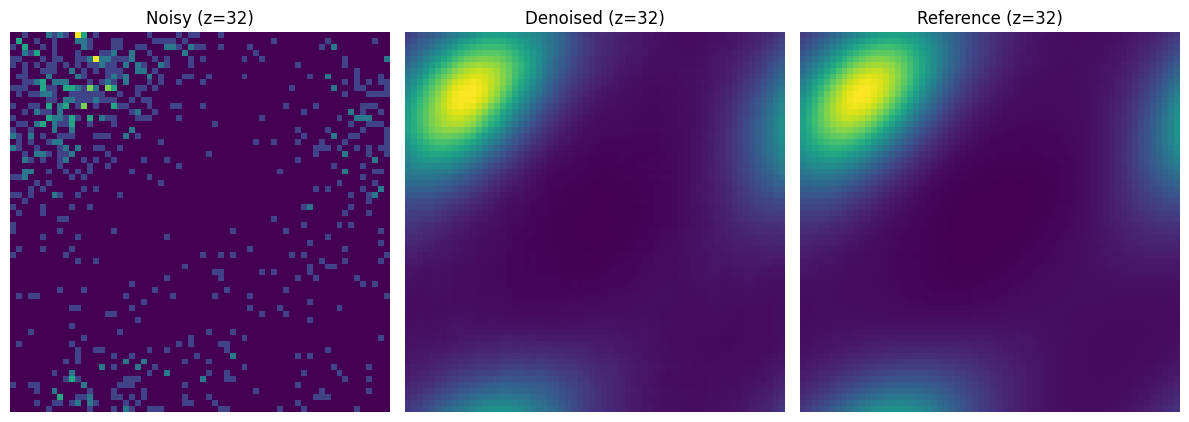

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.000171
(64, 64, 64) (64, 64, 64) (64, 64, 64)


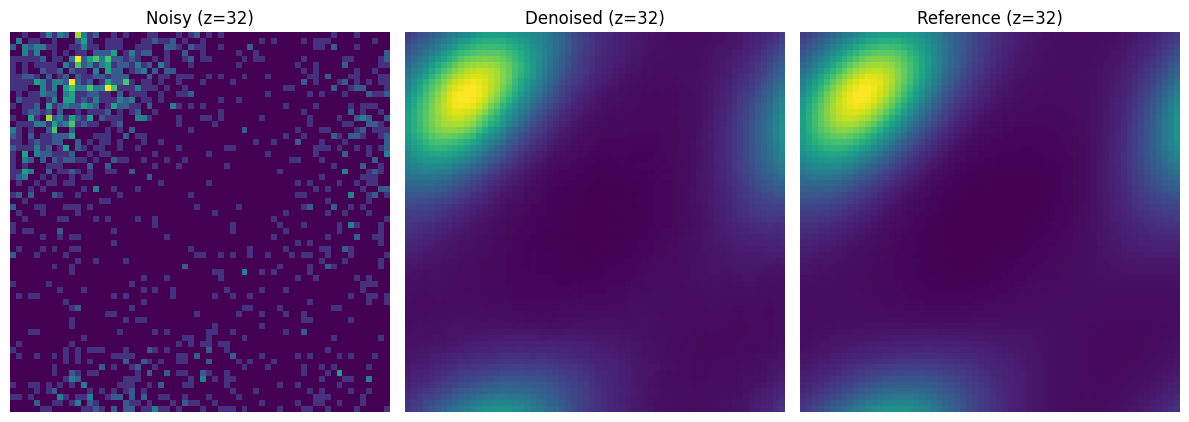

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.000170
(64, 64, 64) (64, 64, 64) (64, 64, 64)


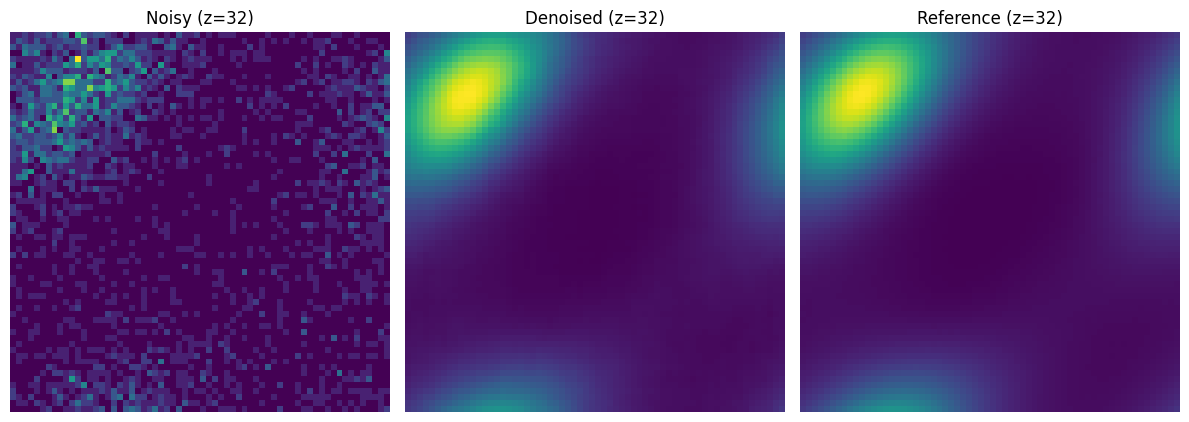

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.000168
(64, 64, 64) (64, 64, 64) (64, 64, 64)


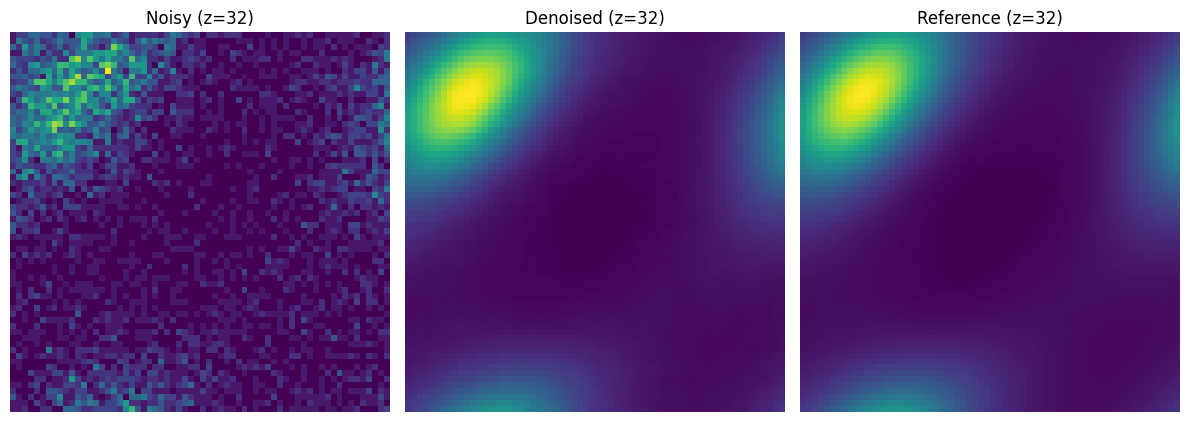

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


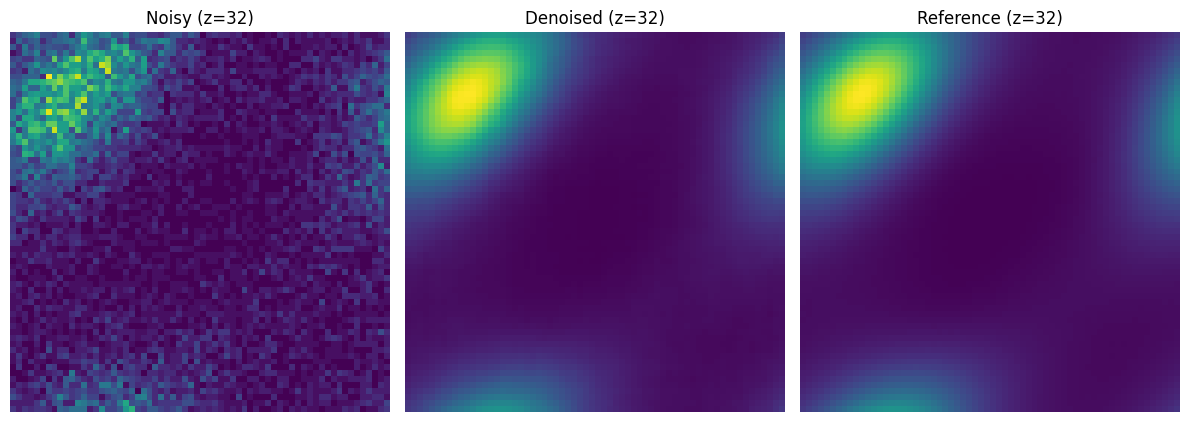

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


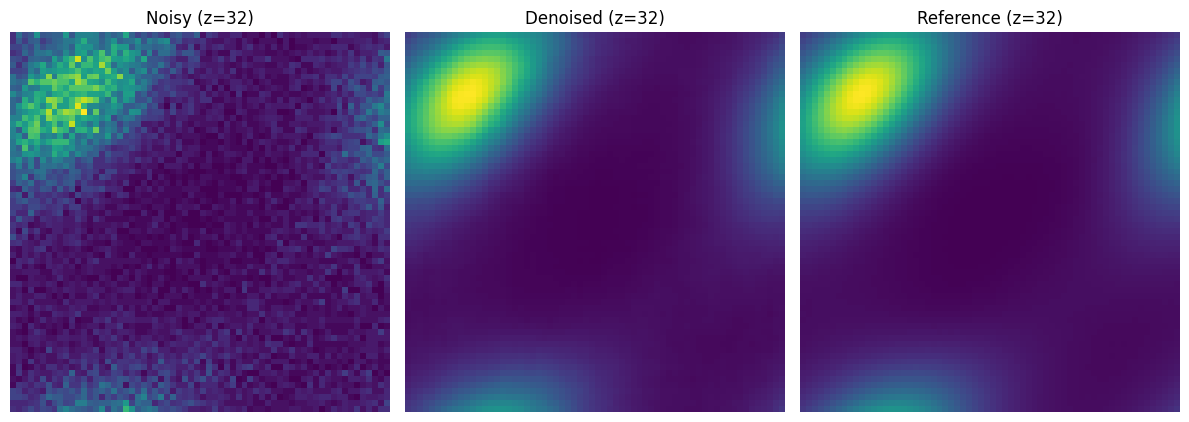

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


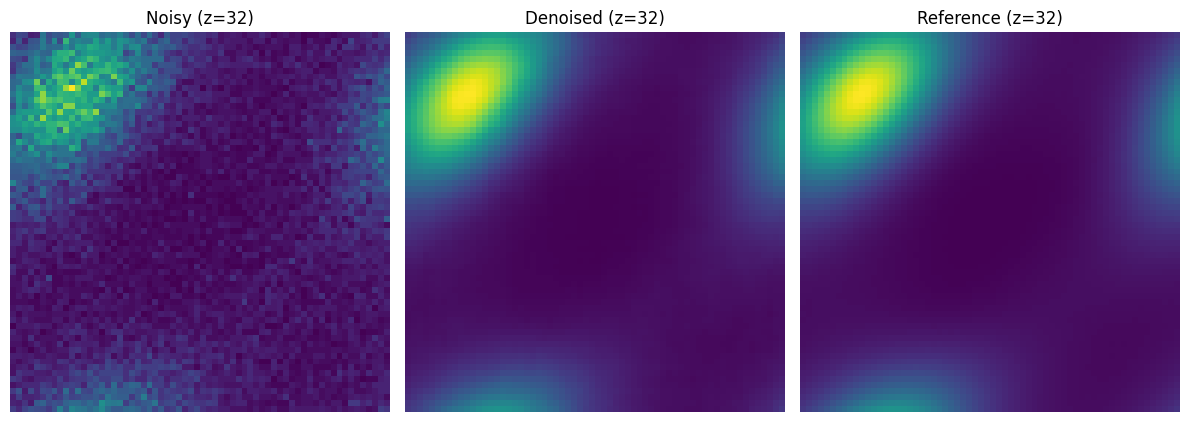

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


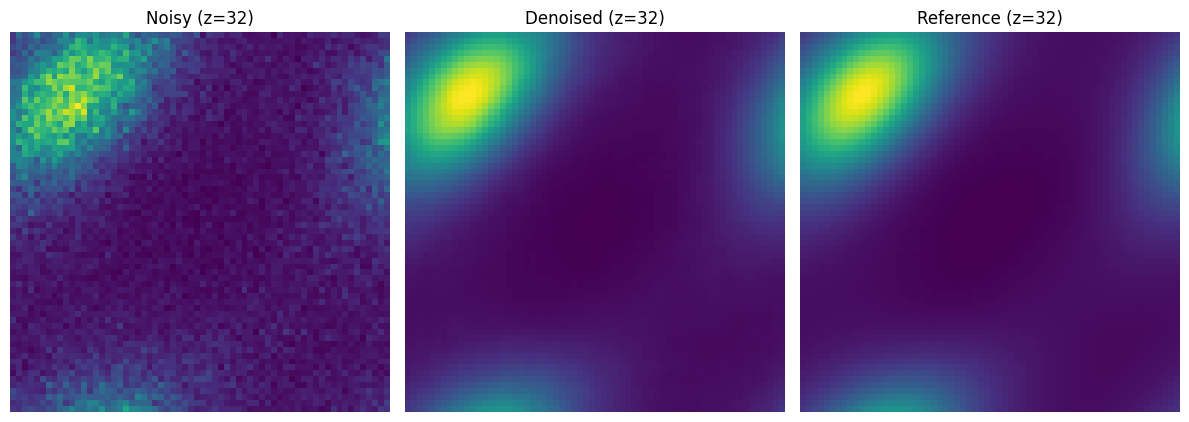

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


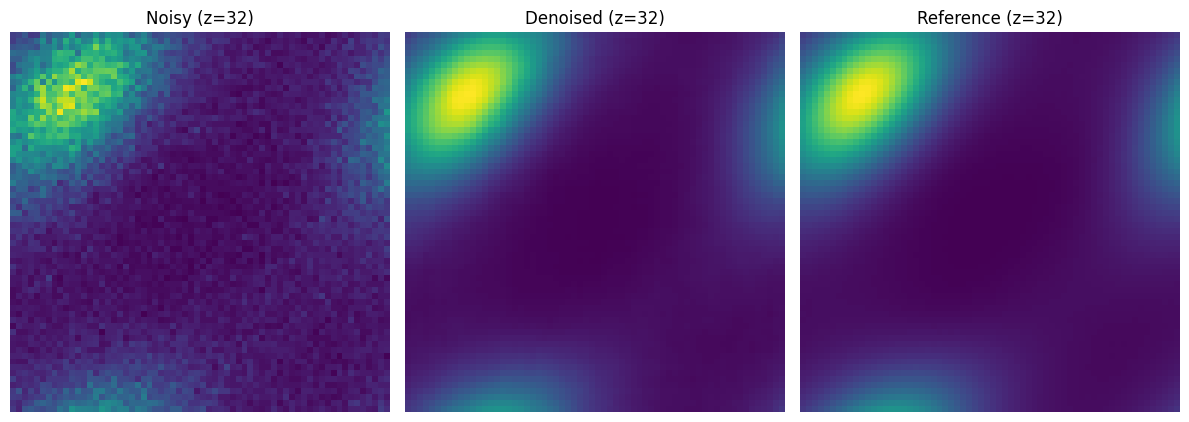

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


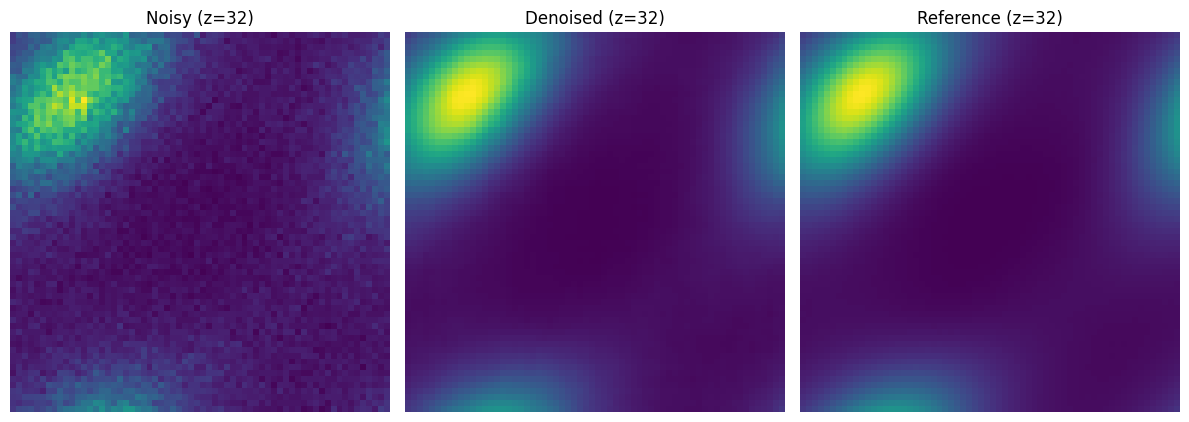

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


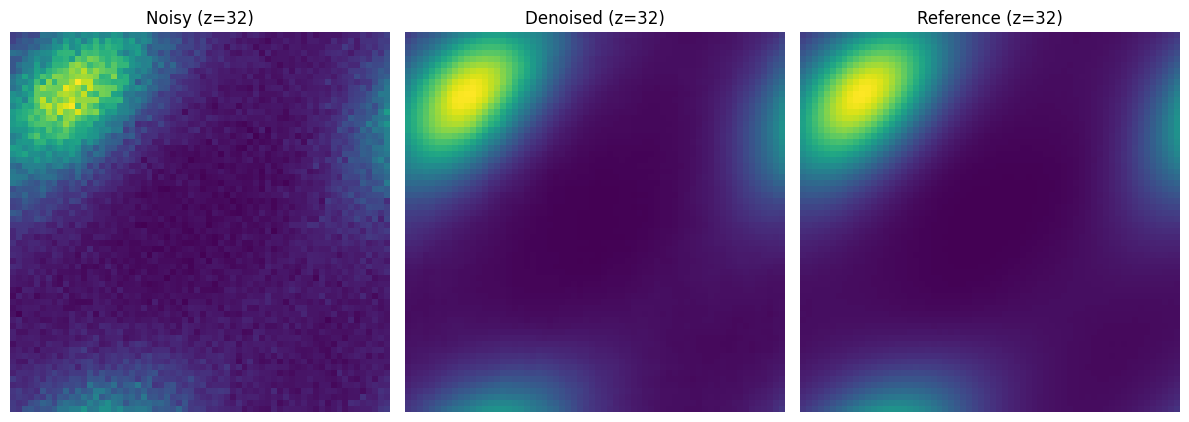

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


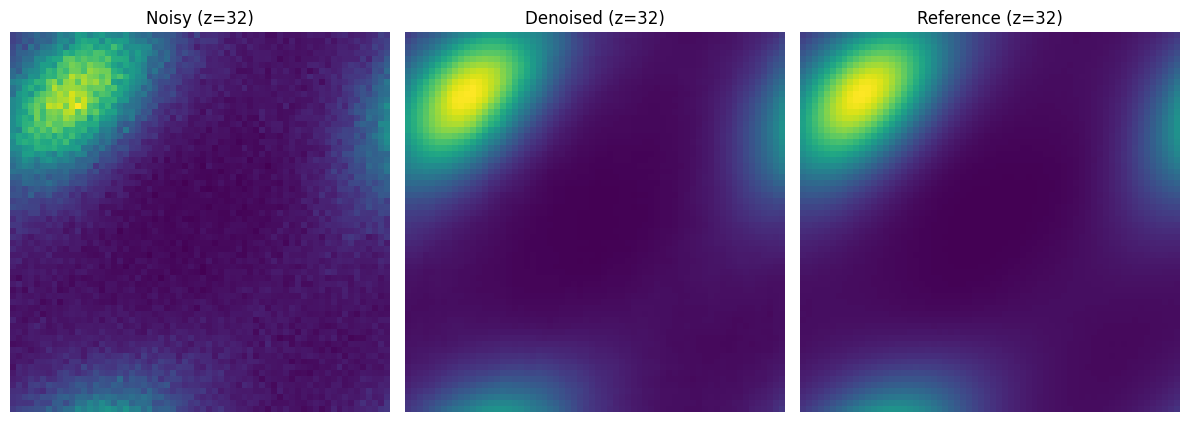

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


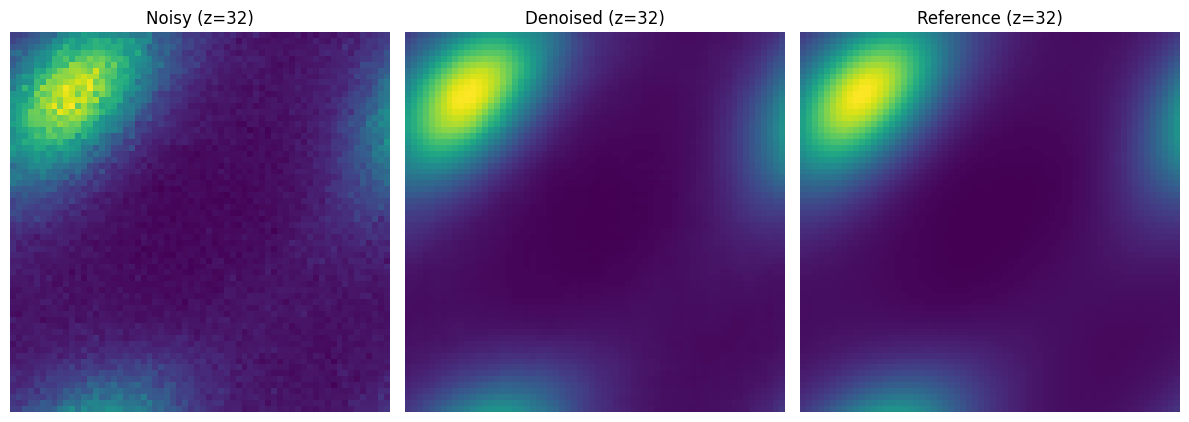

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


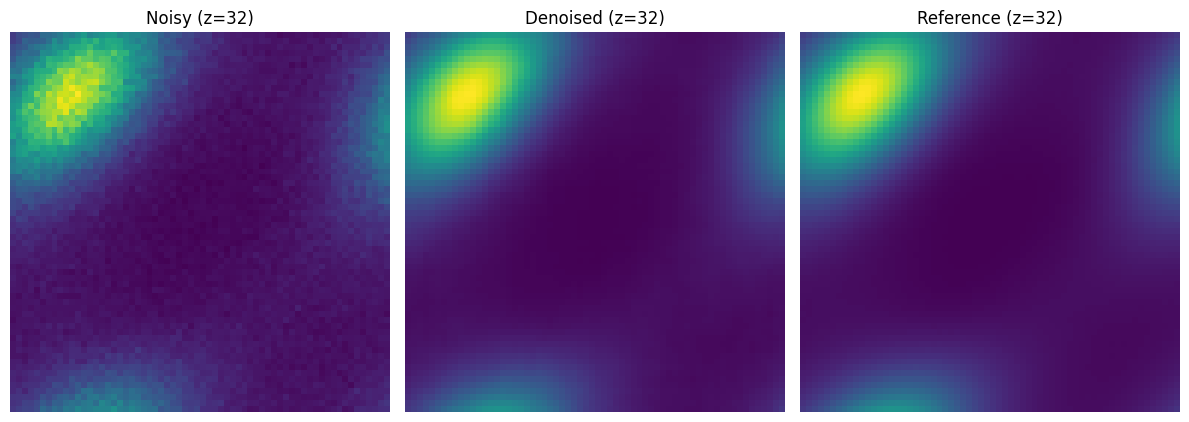

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


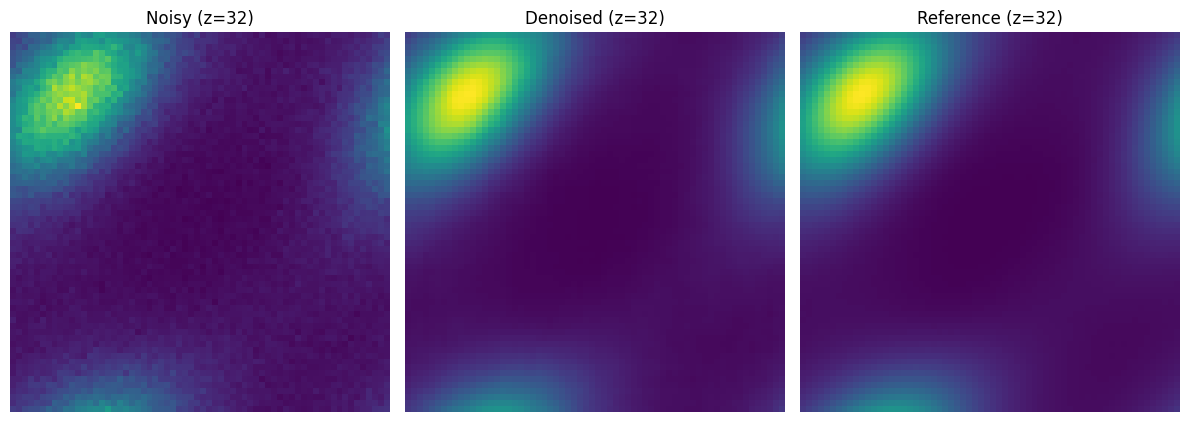

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


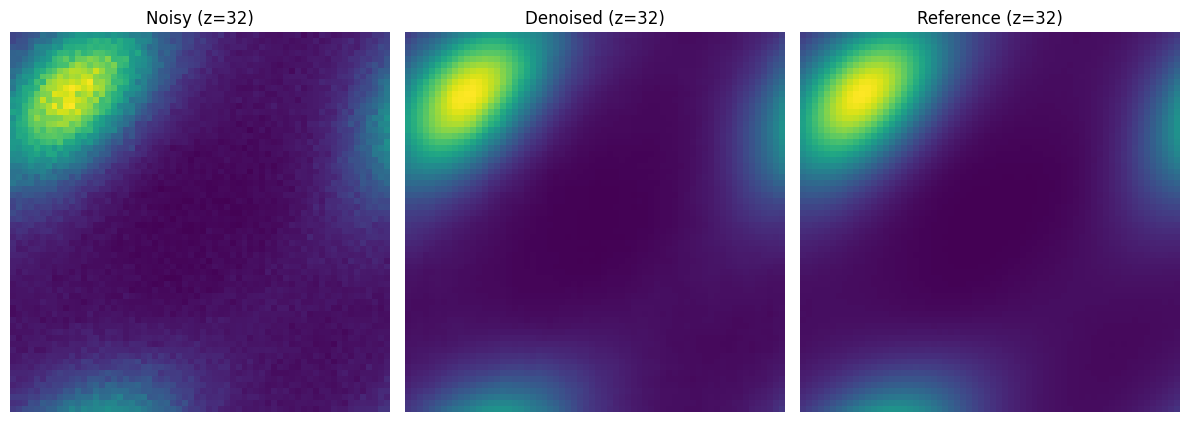

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


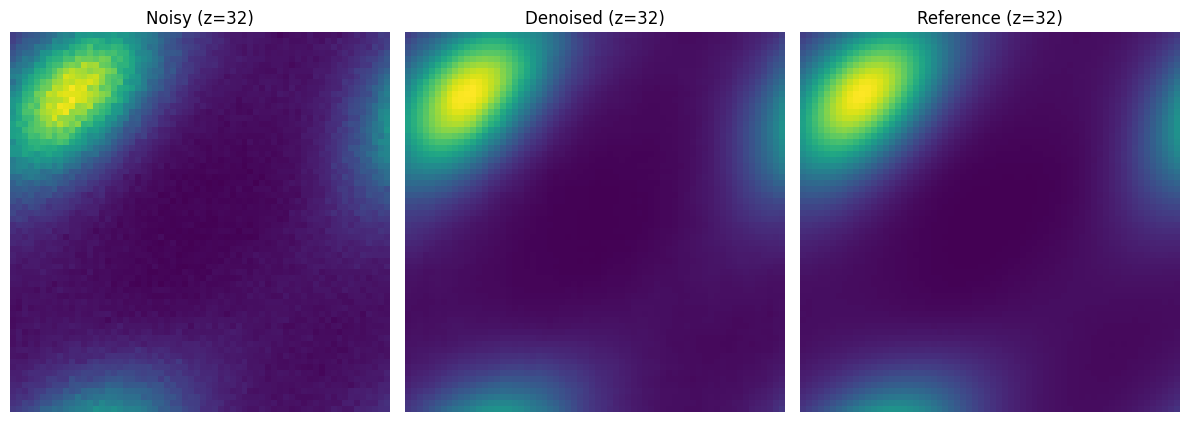

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


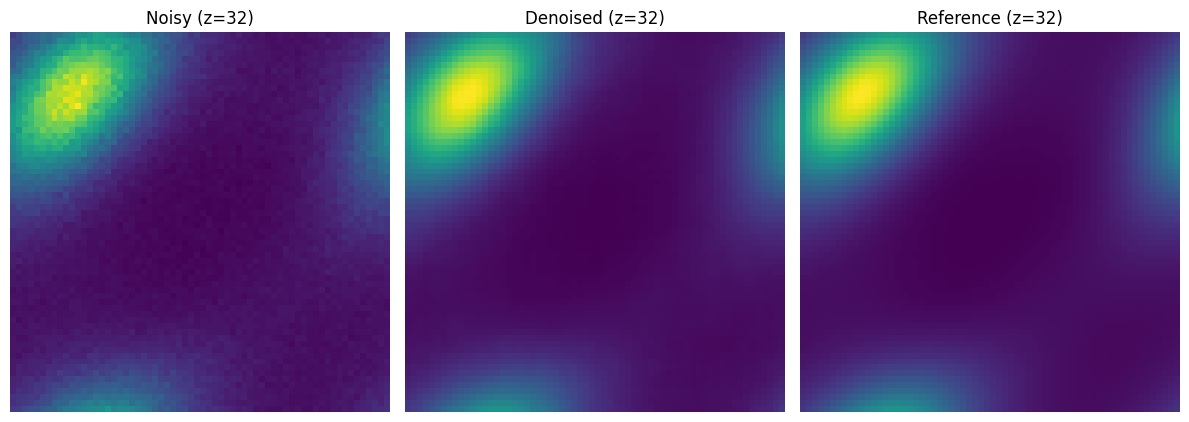

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


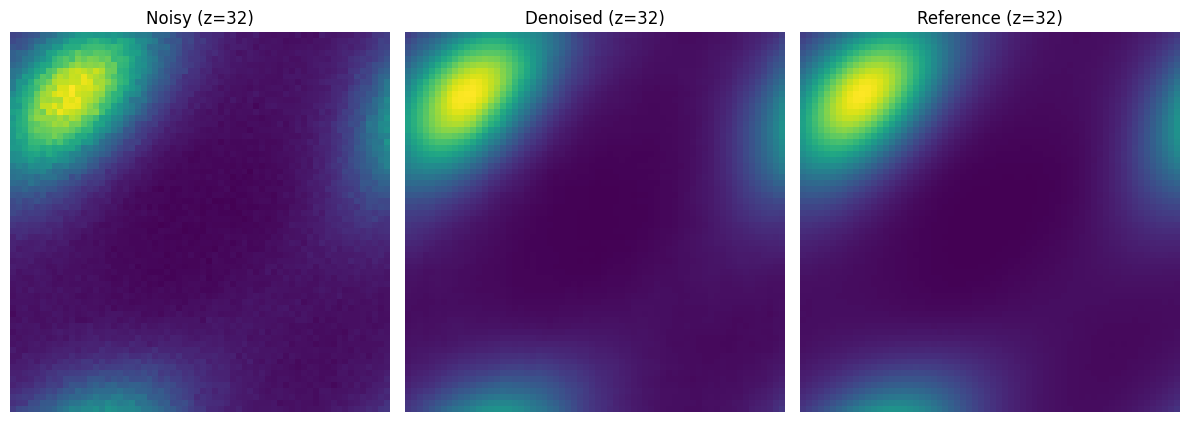

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


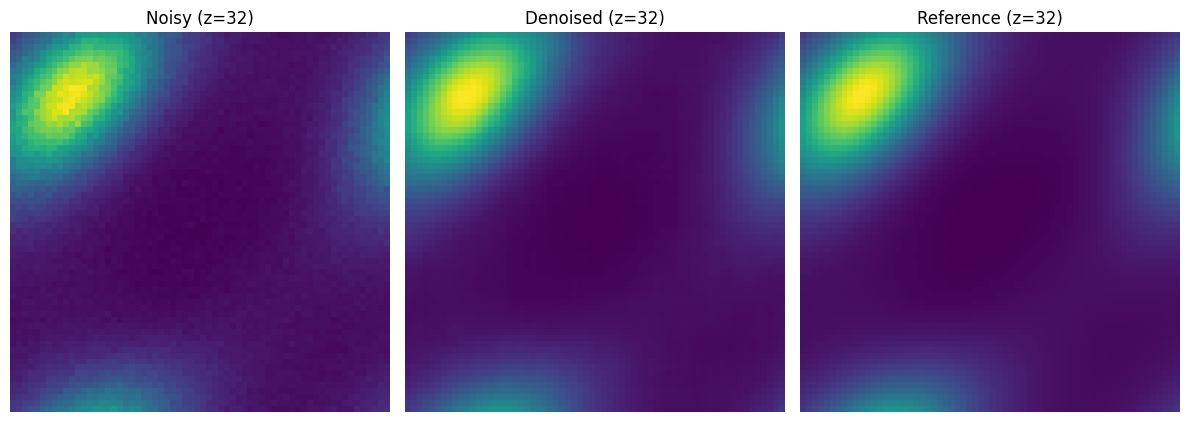

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


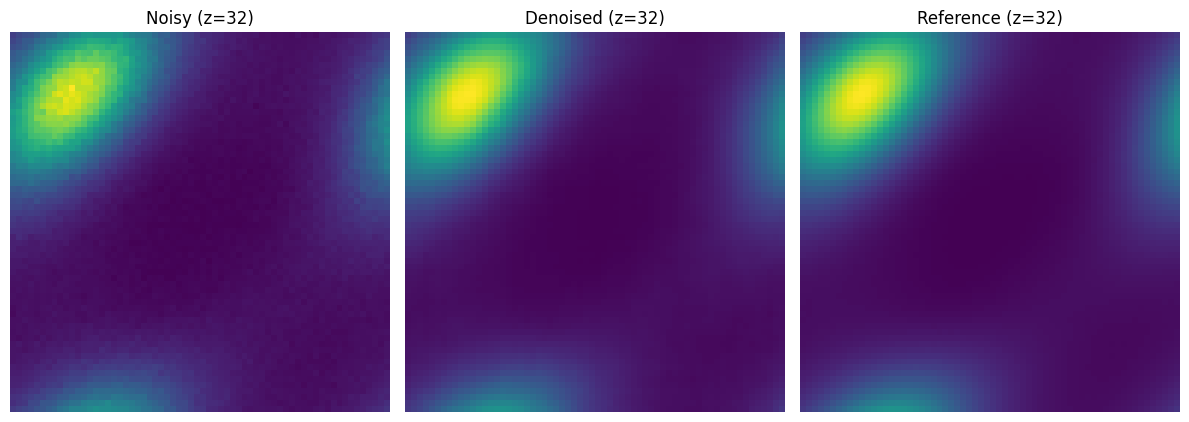

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


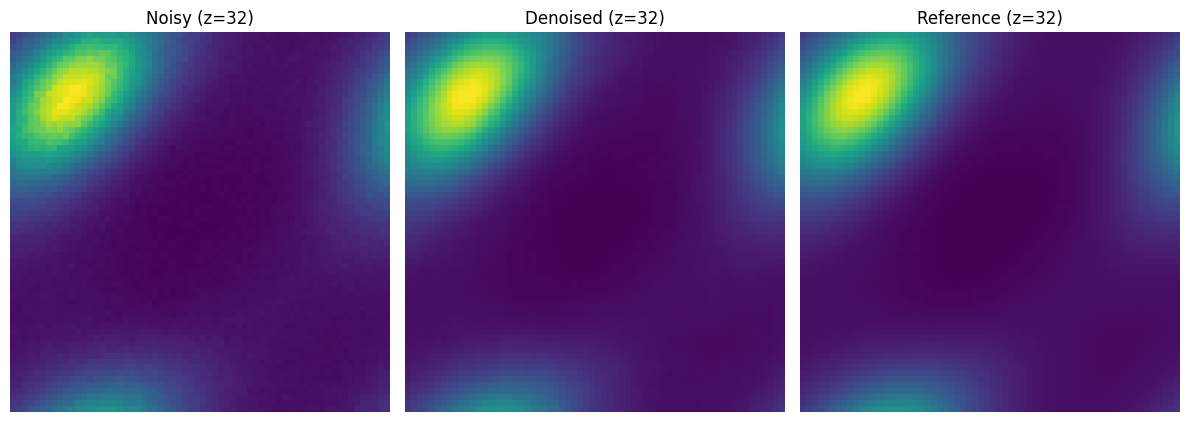

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


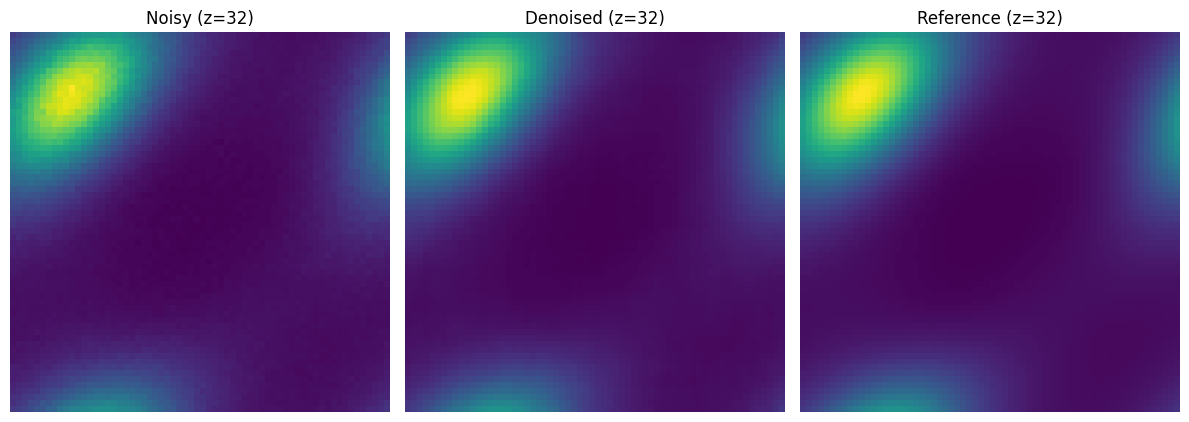

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


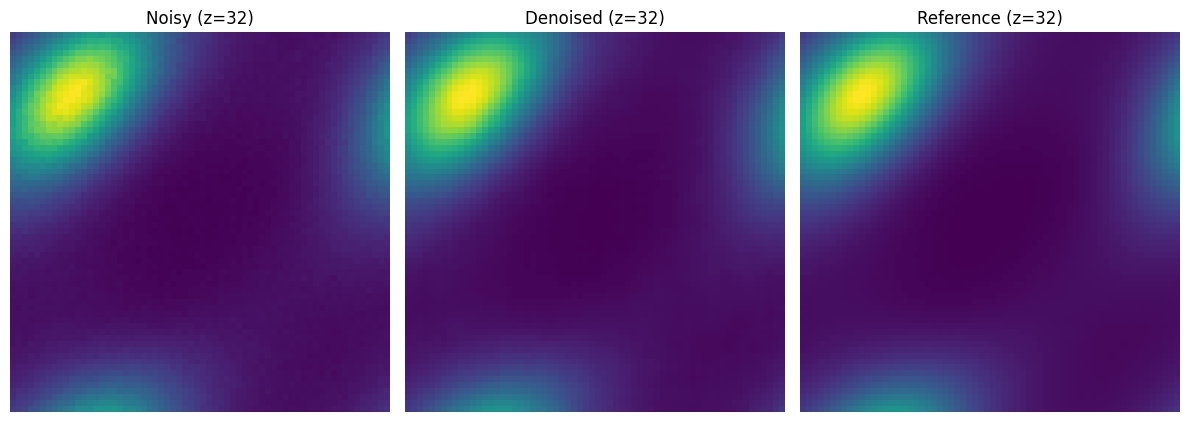

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


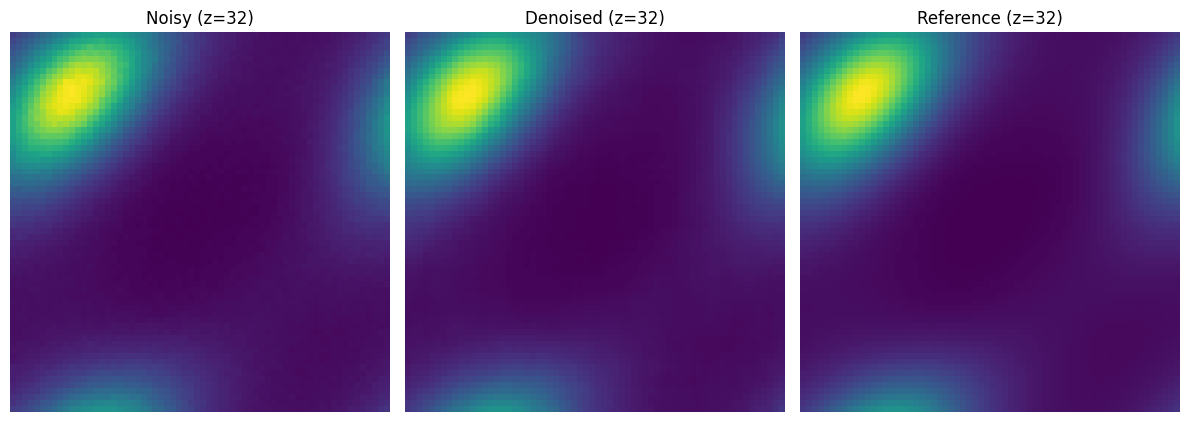

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


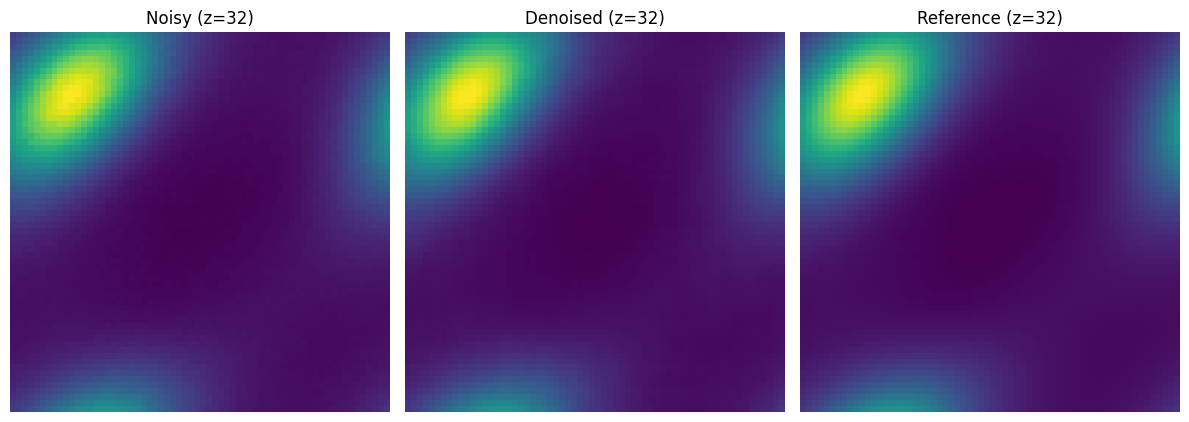

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


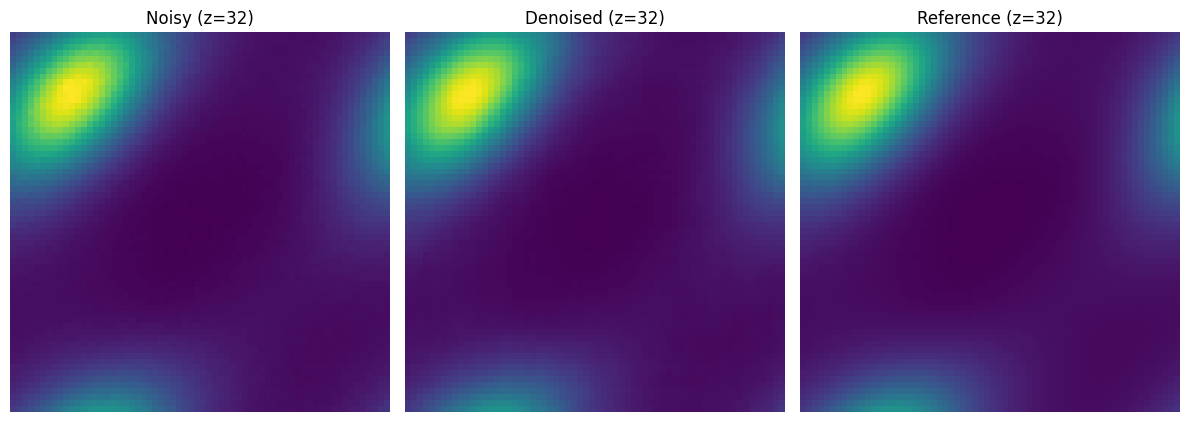

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


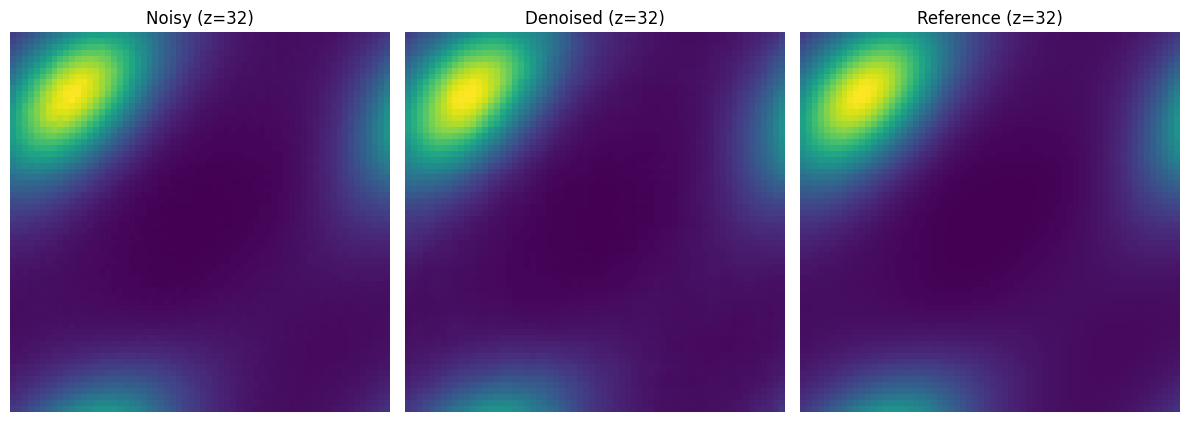

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


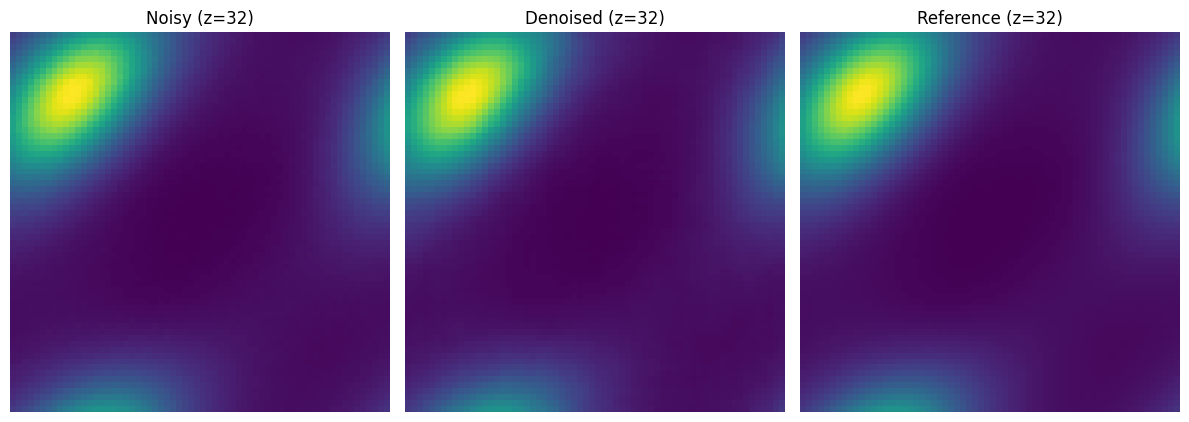

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


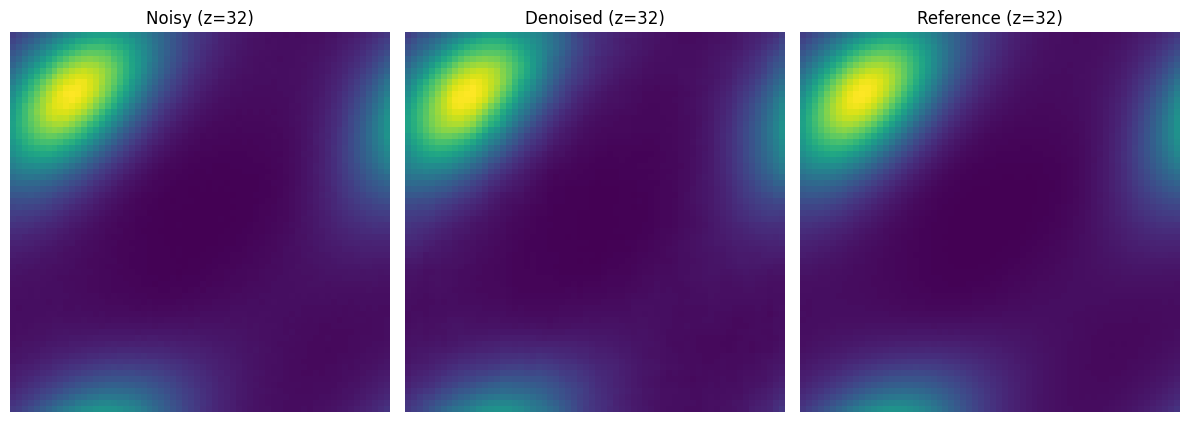

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


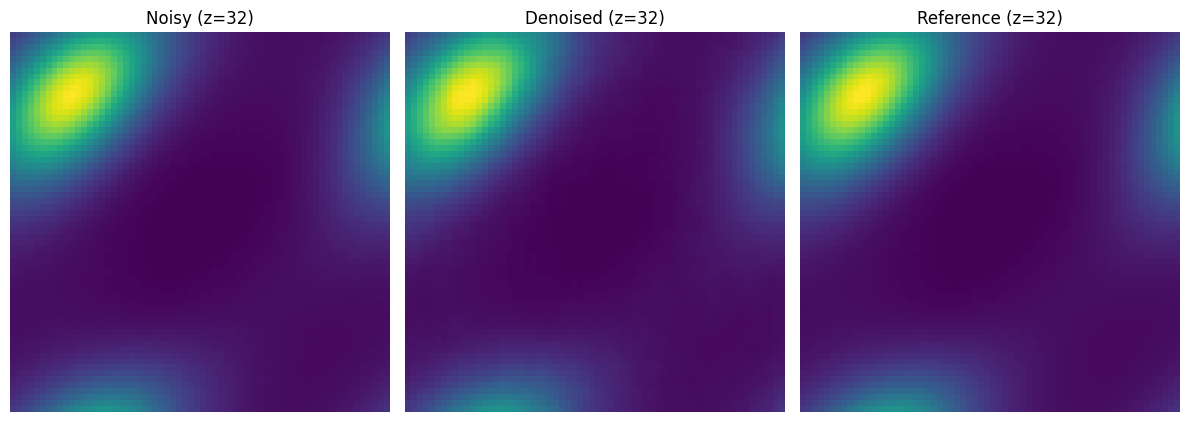

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


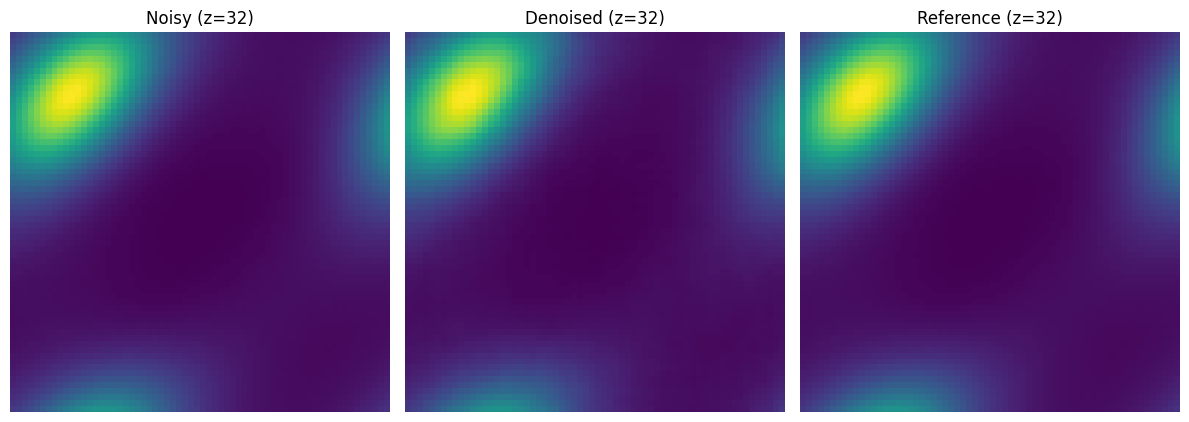

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


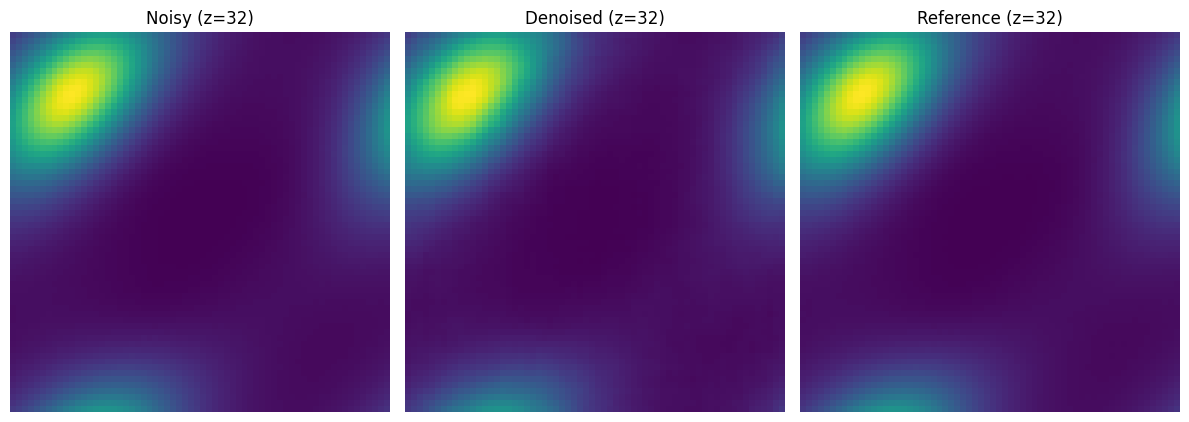


=== Running model: 2385000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.001172
(64, 64, 64) (64, 64, 64) (64, 64, 64)


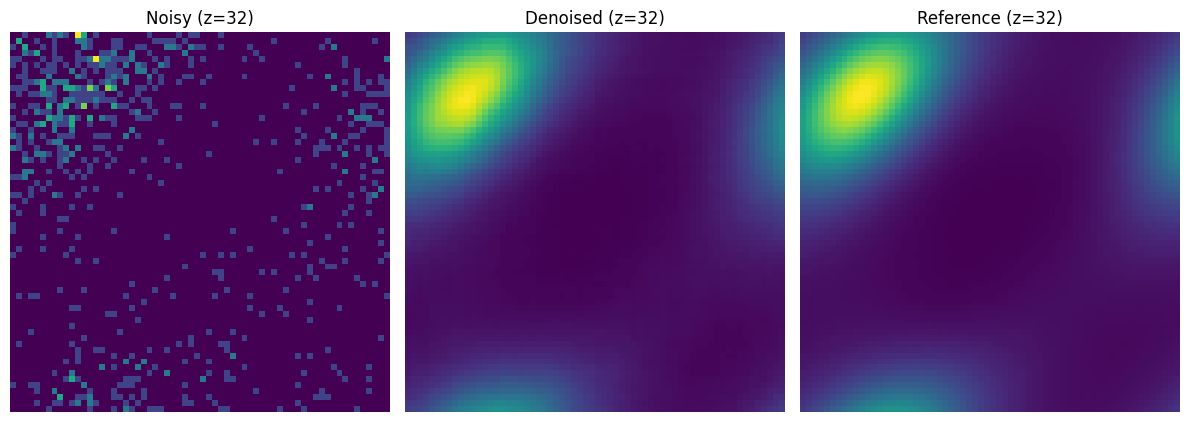

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.001152
(64, 64, 64) (64, 64, 64) (64, 64, 64)


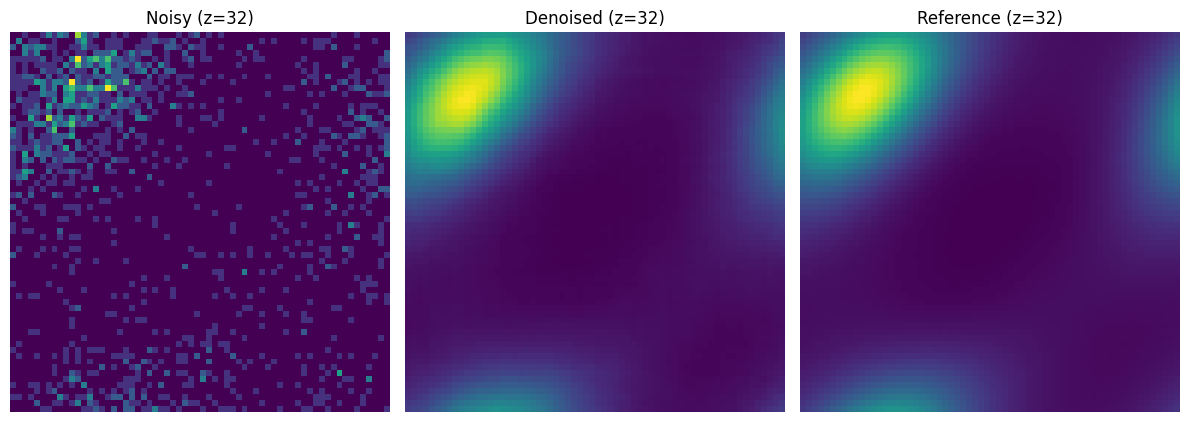

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.001137
(64, 64, 64) (64, 64, 64) (64, 64, 64)


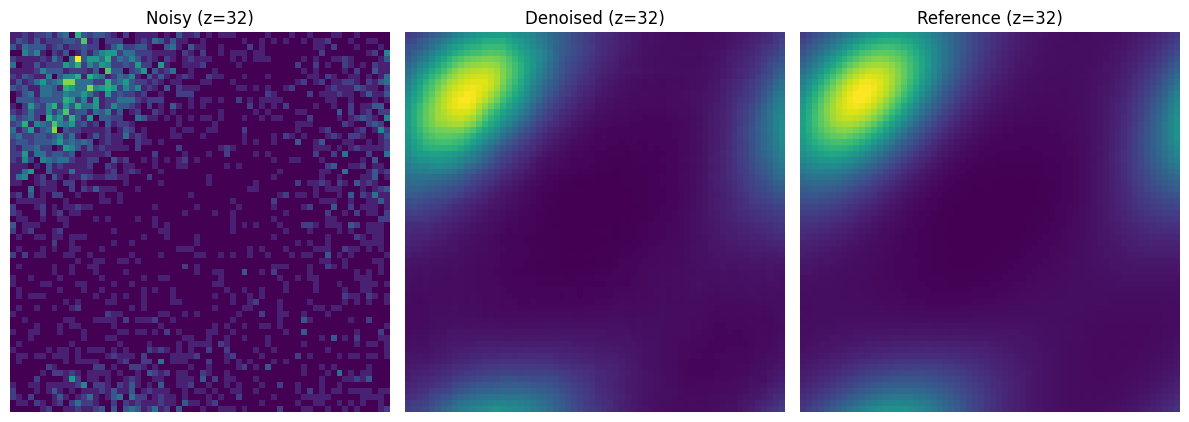

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.001128
(64, 64, 64) (64, 64, 64) (64, 64, 64)


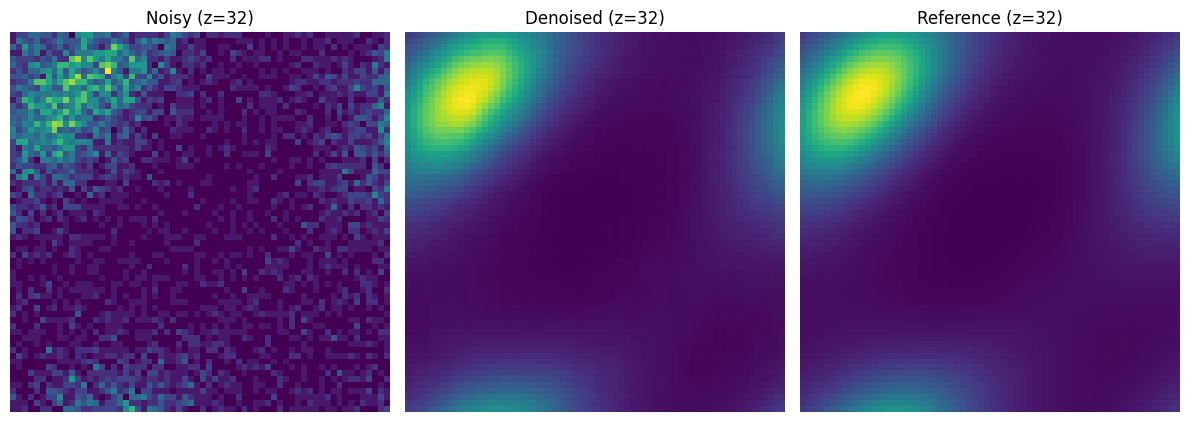

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.001121
(64, 64, 64) (64, 64, 64) (64, 64, 64)


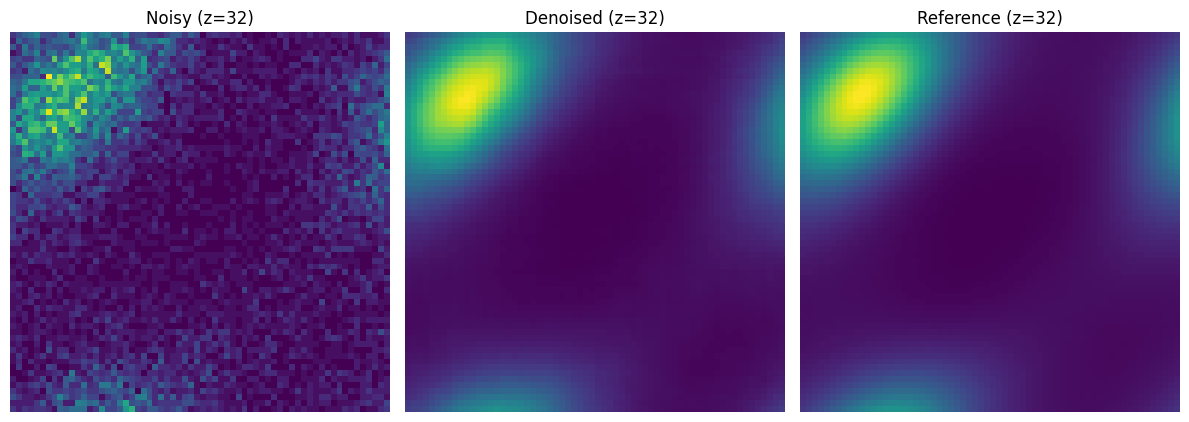

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.001116
(64, 64, 64) (64, 64, 64) (64, 64, 64)


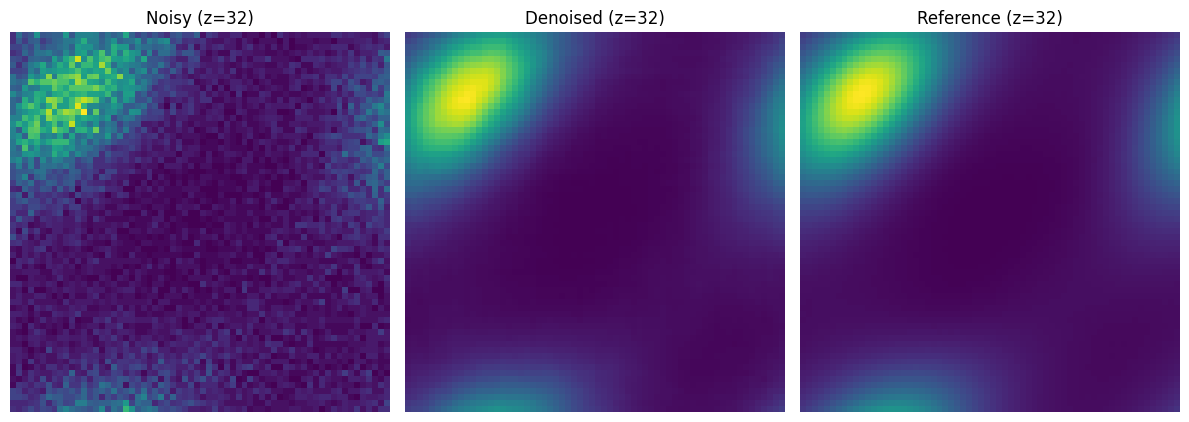

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.001115
(64, 64, 64) (64, 64, 64) (64, 64, 64)


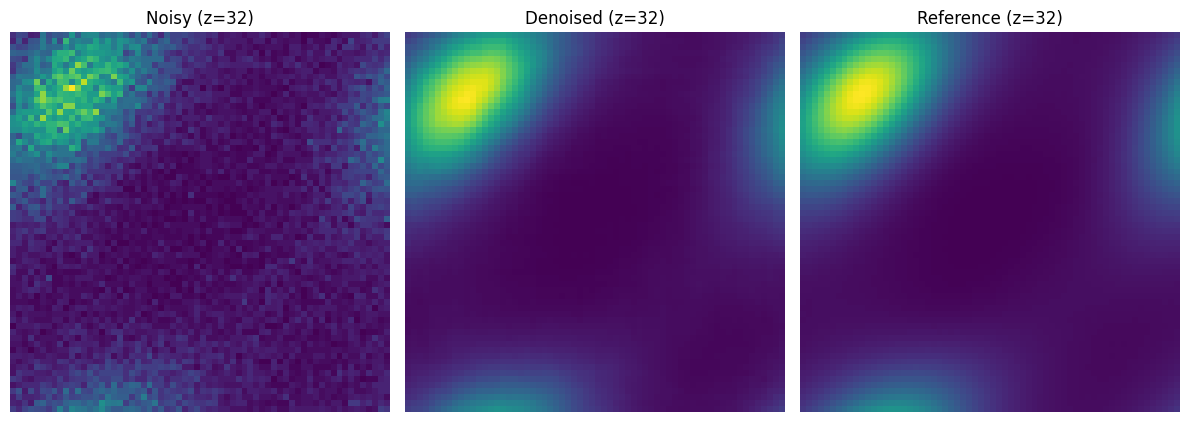

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.001115
(64, 64, 64) (64, 64, 64) (64, 64, 64)


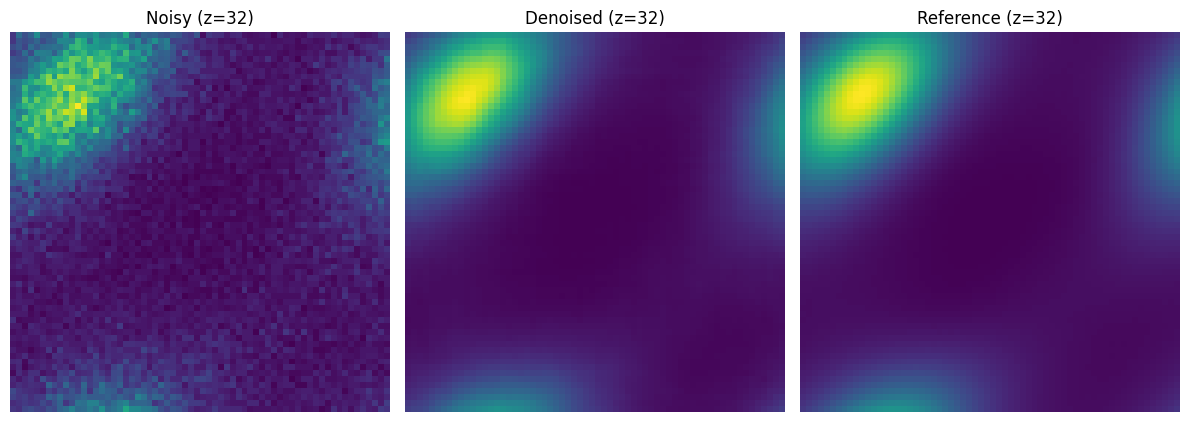

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.001114
(64, 64, 64) (64, 64, 64) (64, 64, 64)


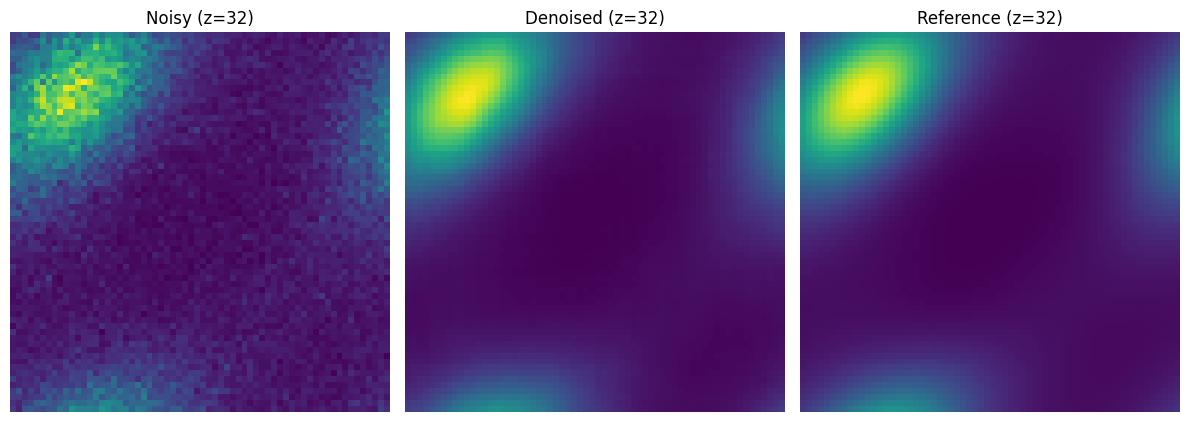

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.001113
(64, 64, 64) (64, 64, 64) (64, 64, 64)


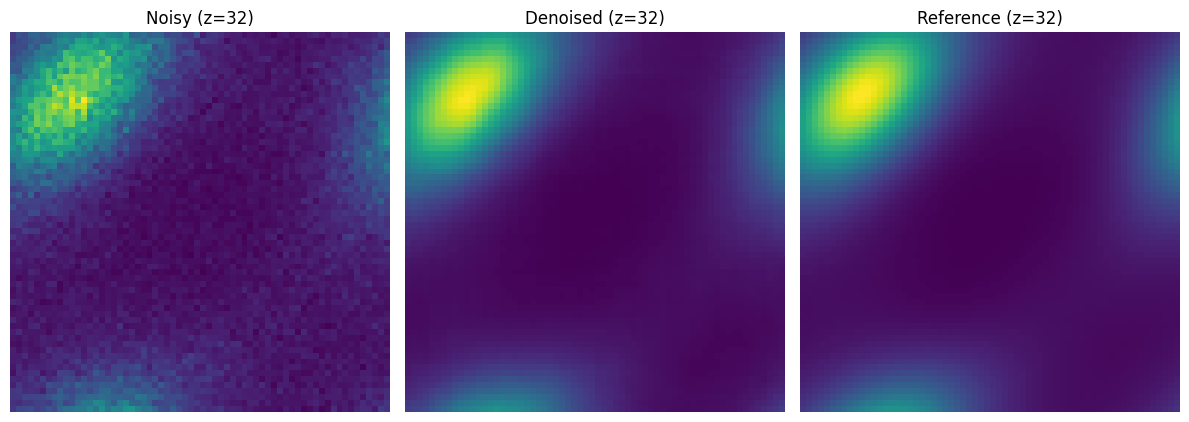

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.001113
(64, 64, 64) (64, 64, 64) (64, 64, 64)


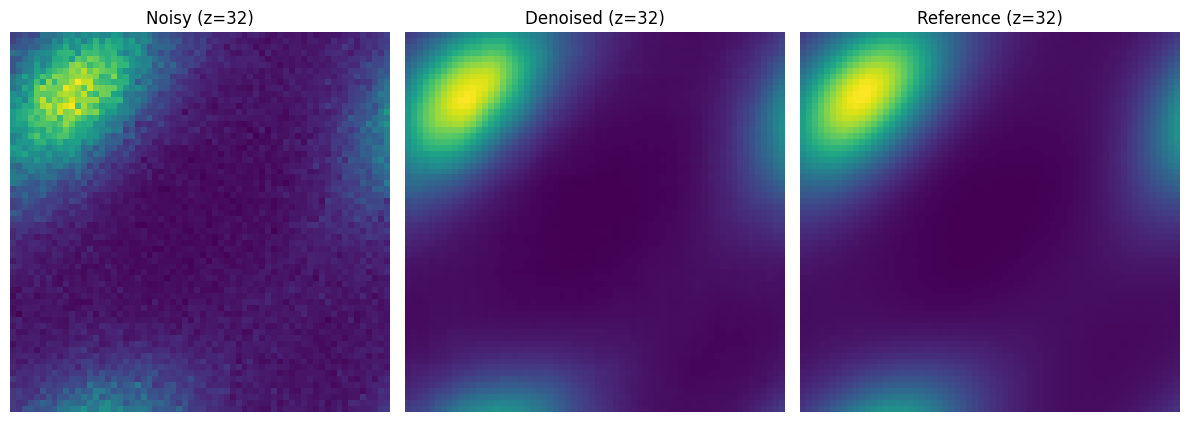

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


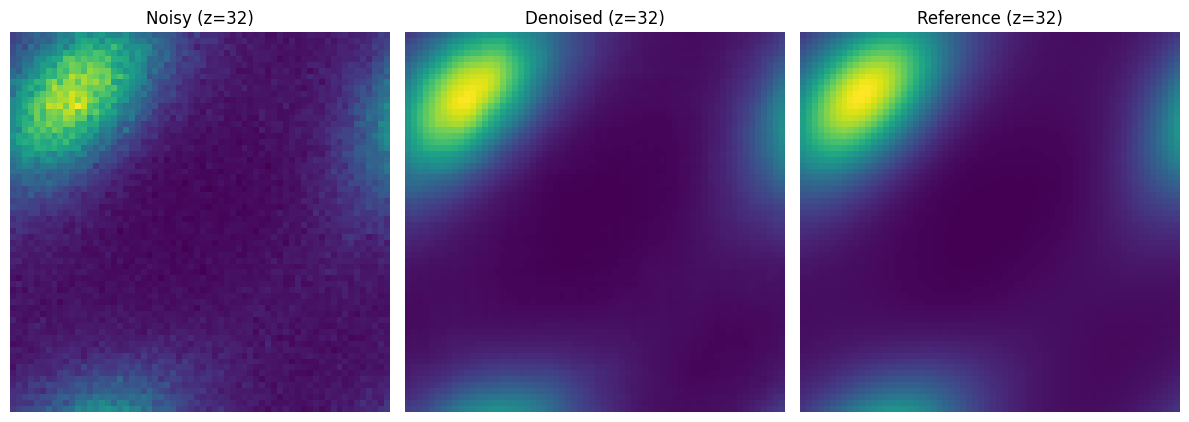

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


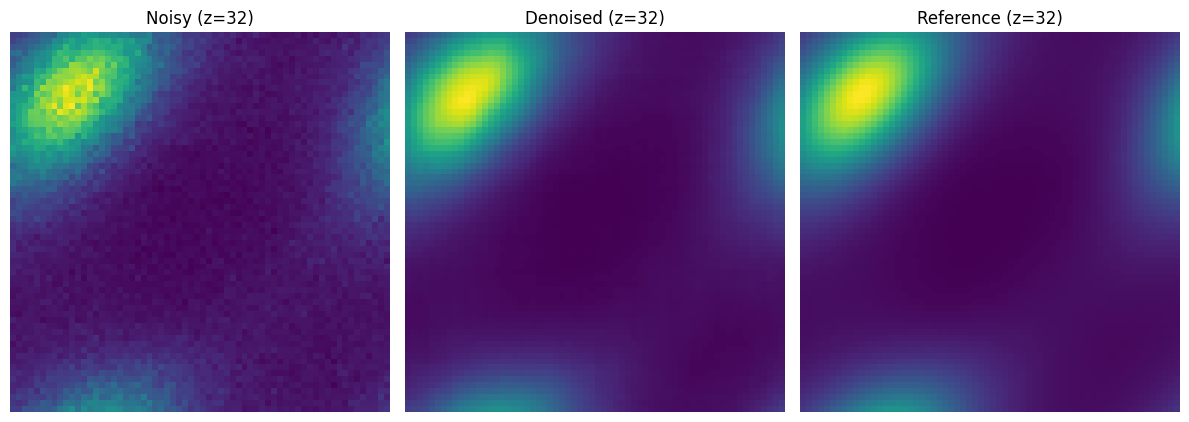

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


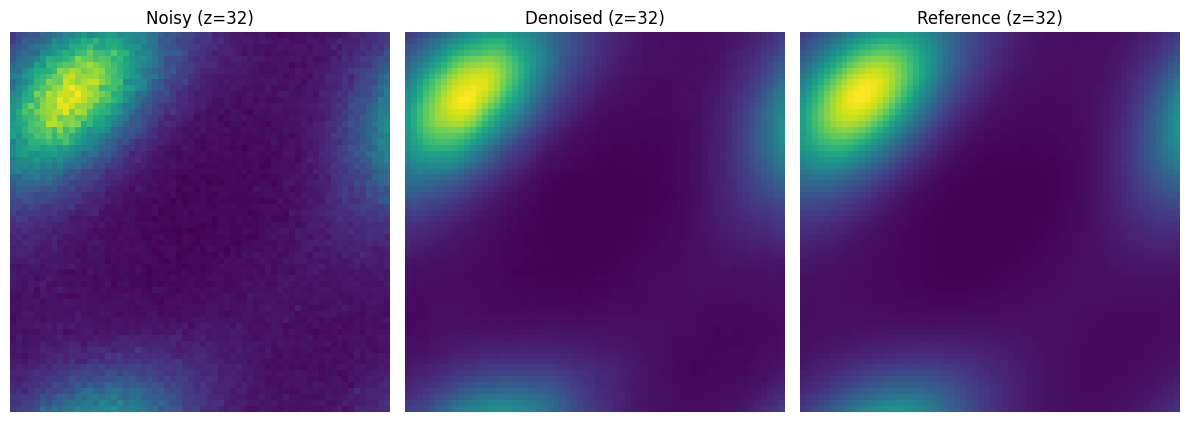

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


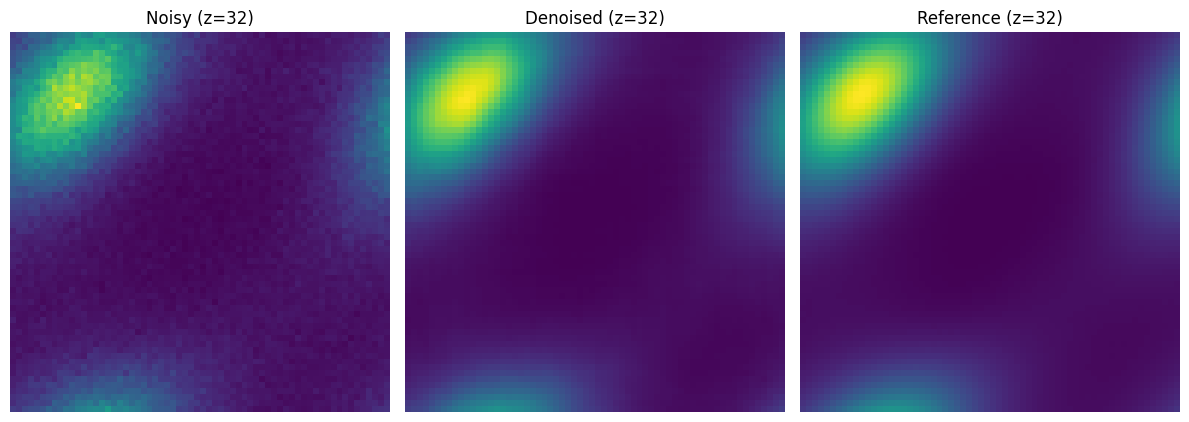

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


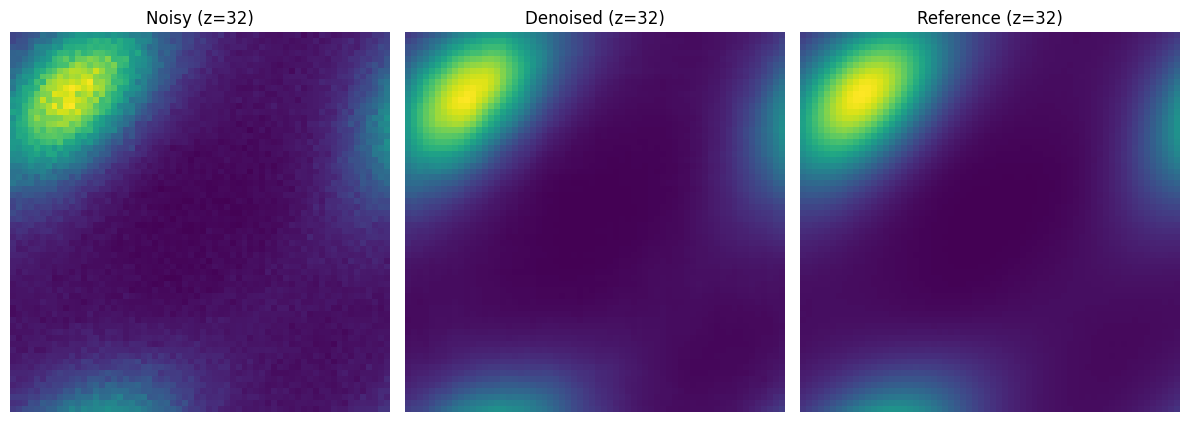

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


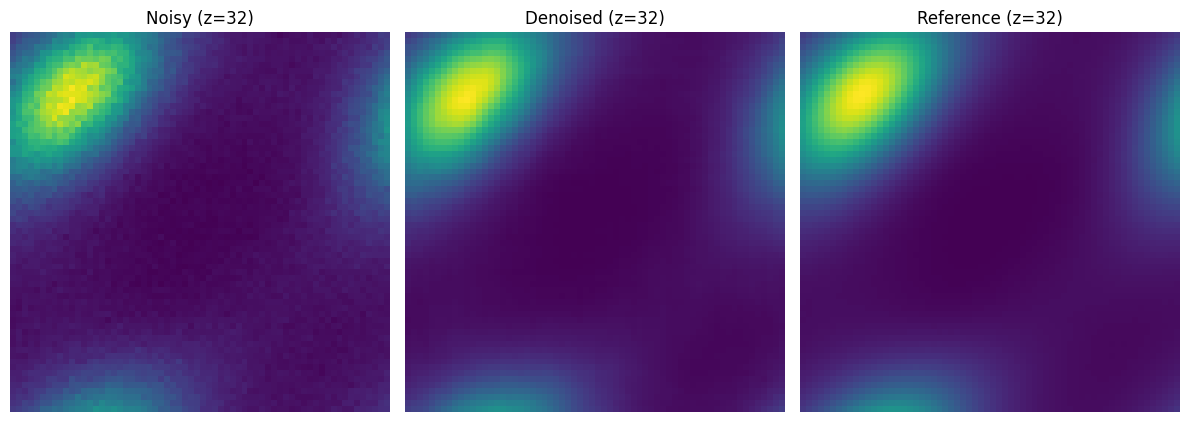

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


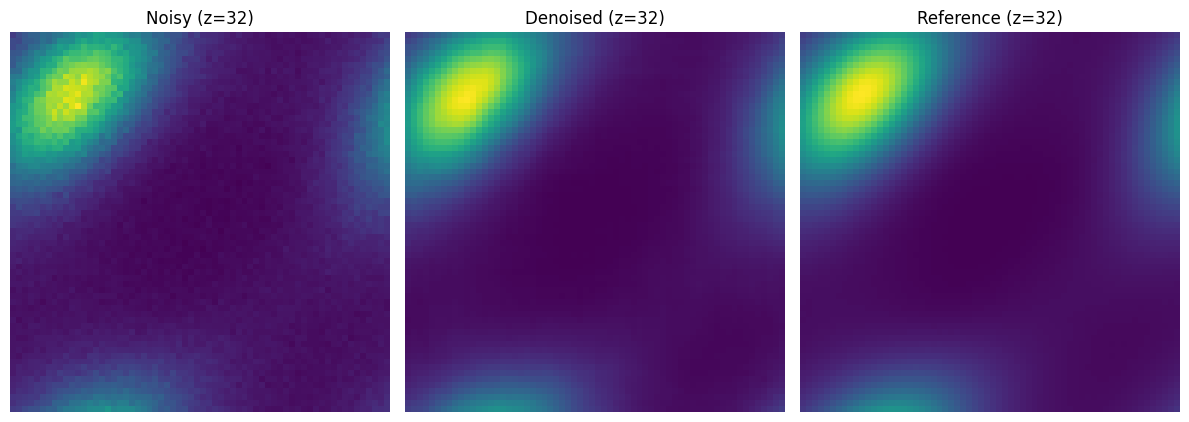

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


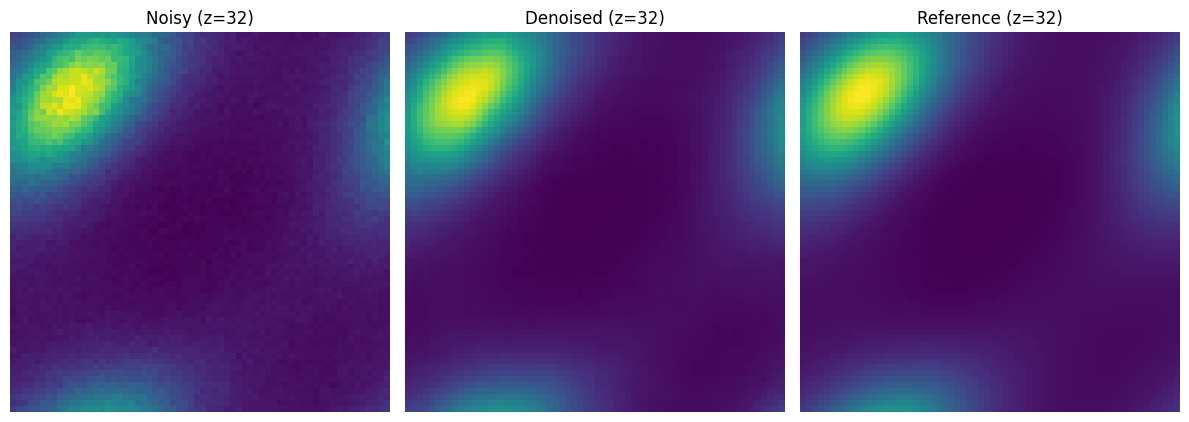

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


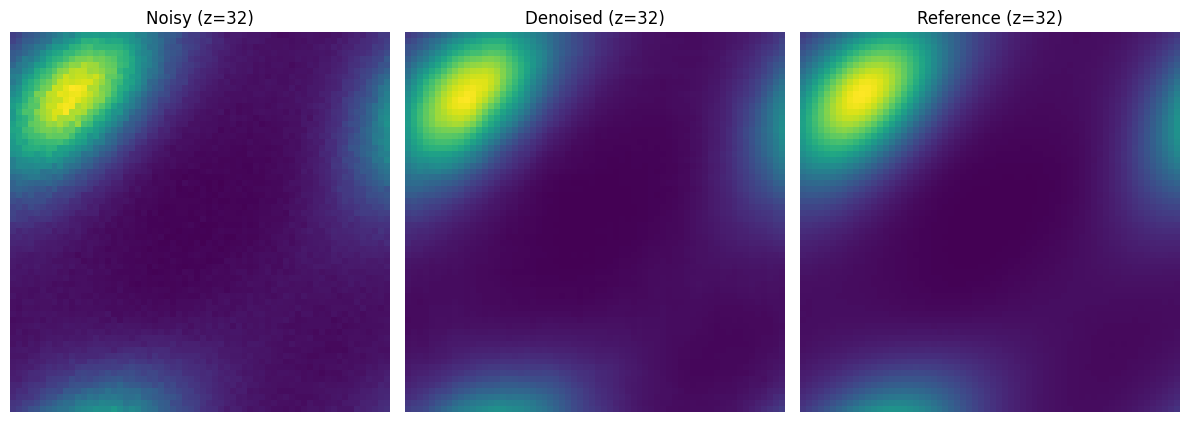

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


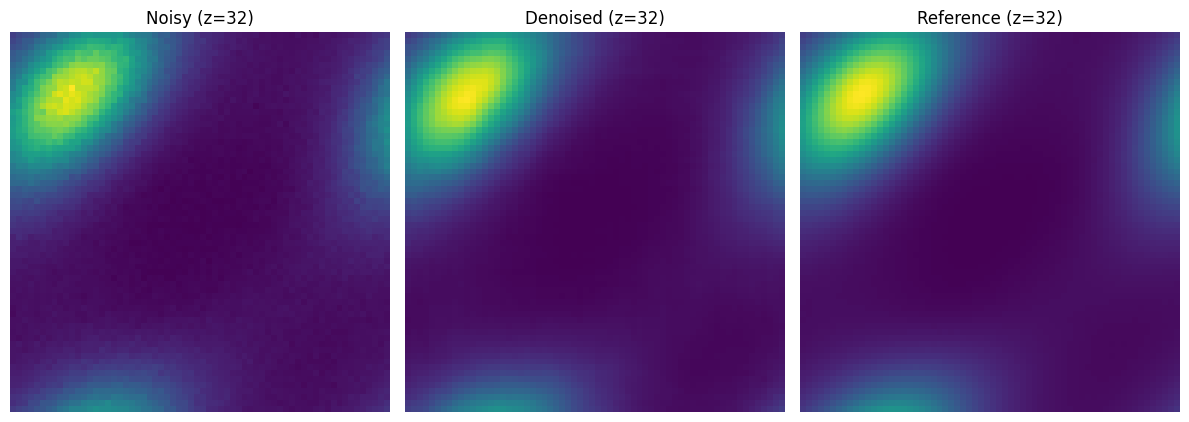

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


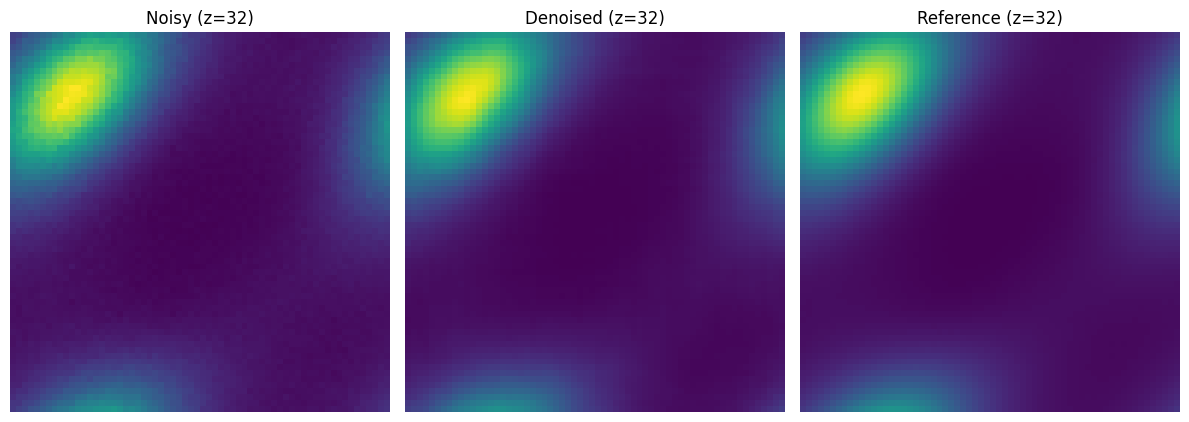

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


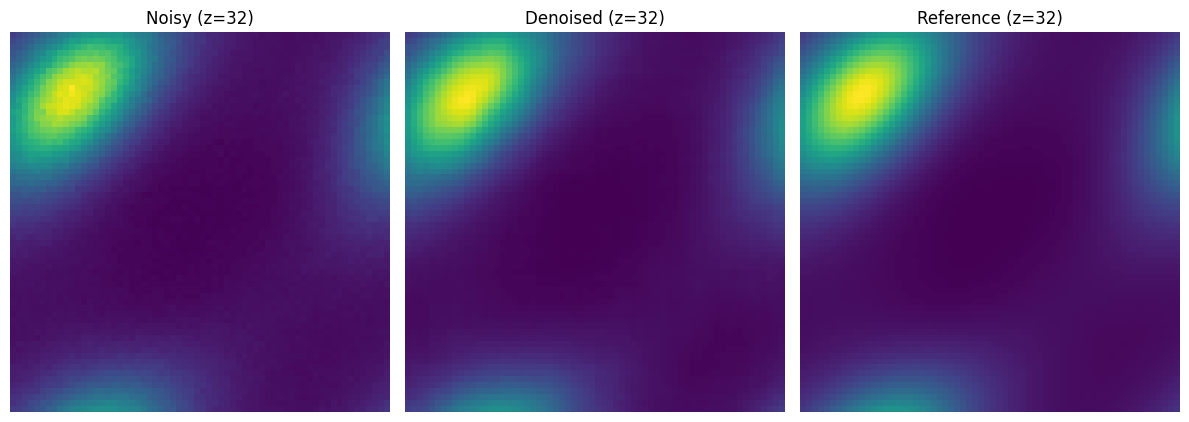

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


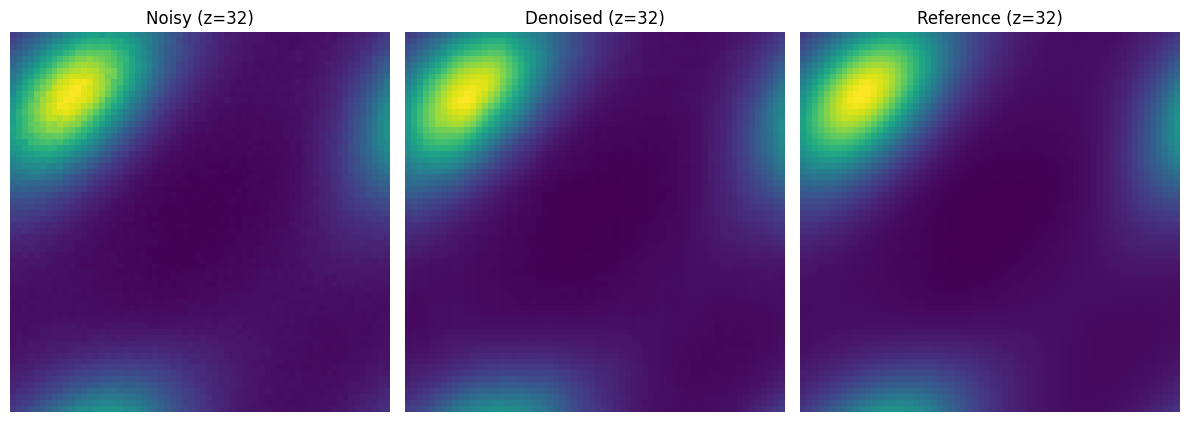

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


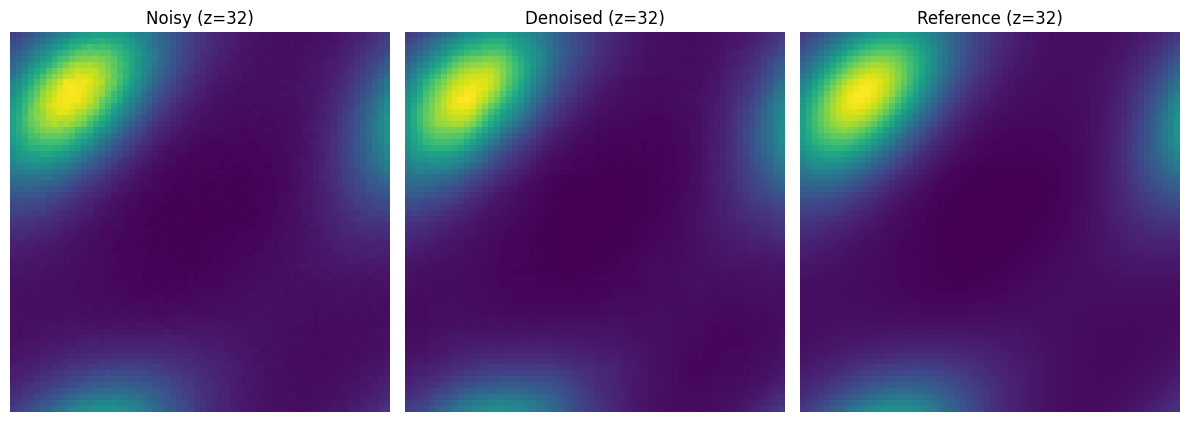

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.001112
(64, 64, 64) (64, 64, 64) (64, 64, 64)


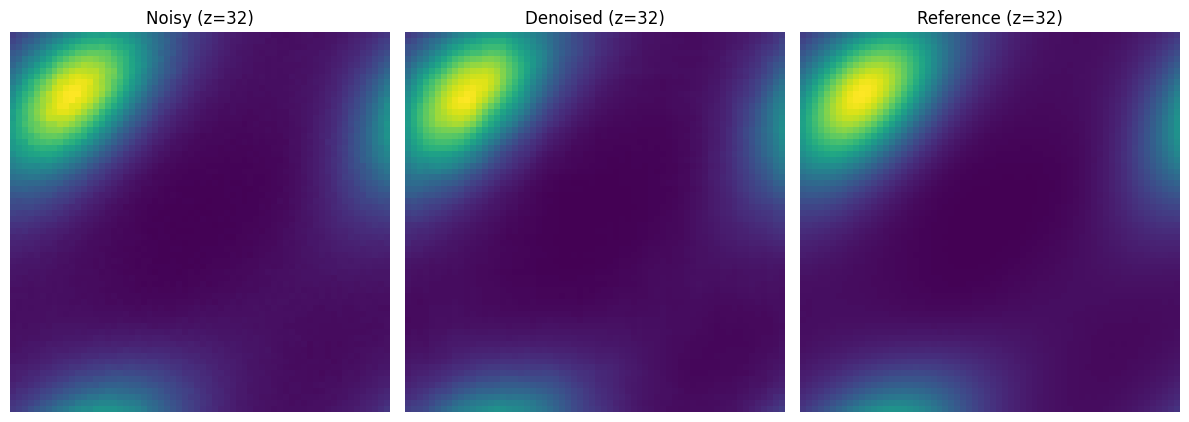

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


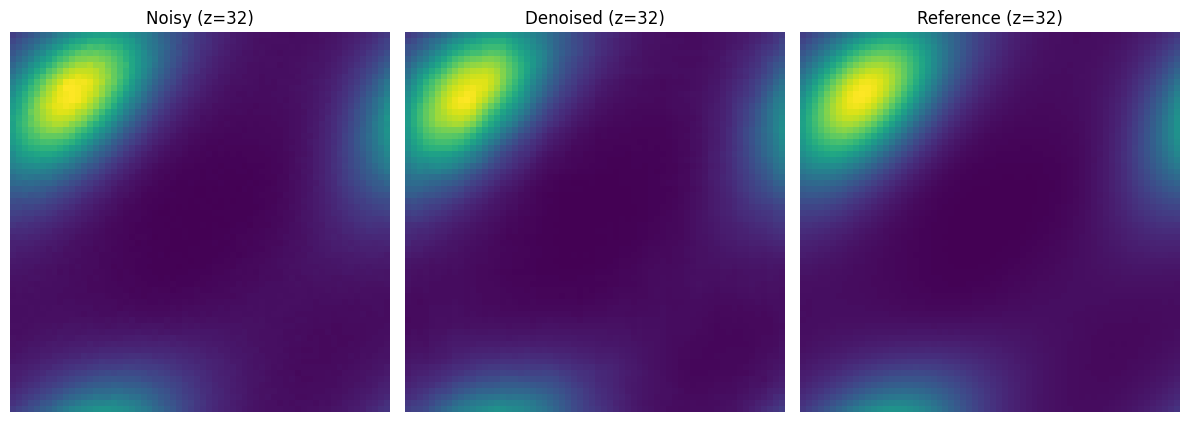

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


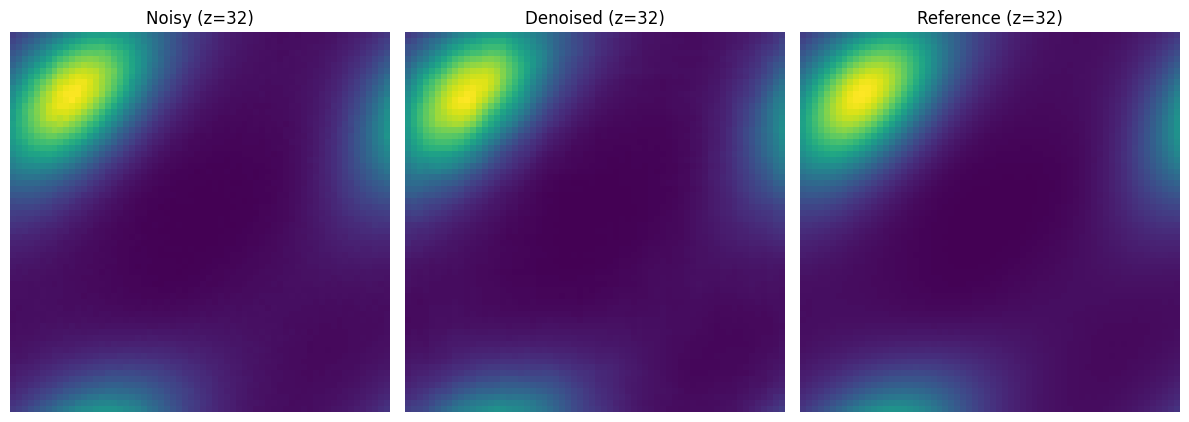

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


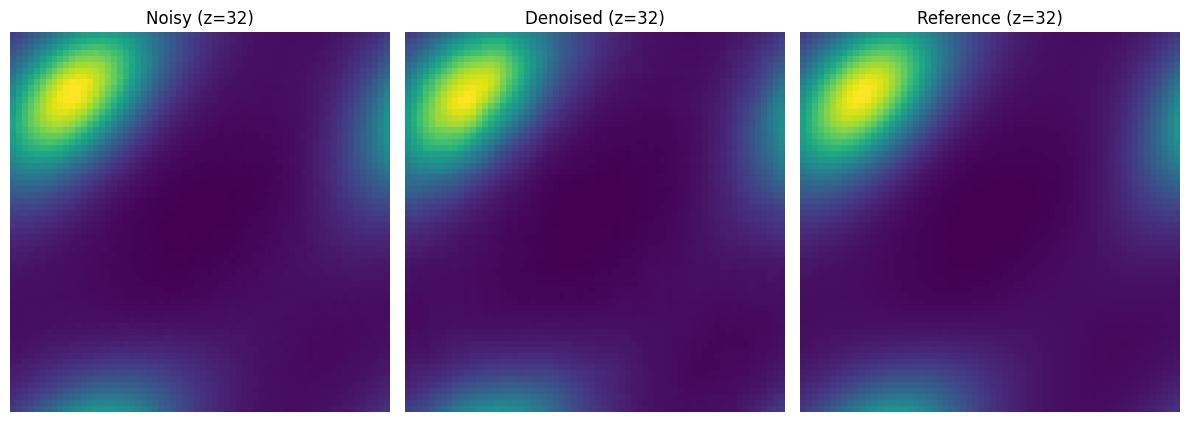

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


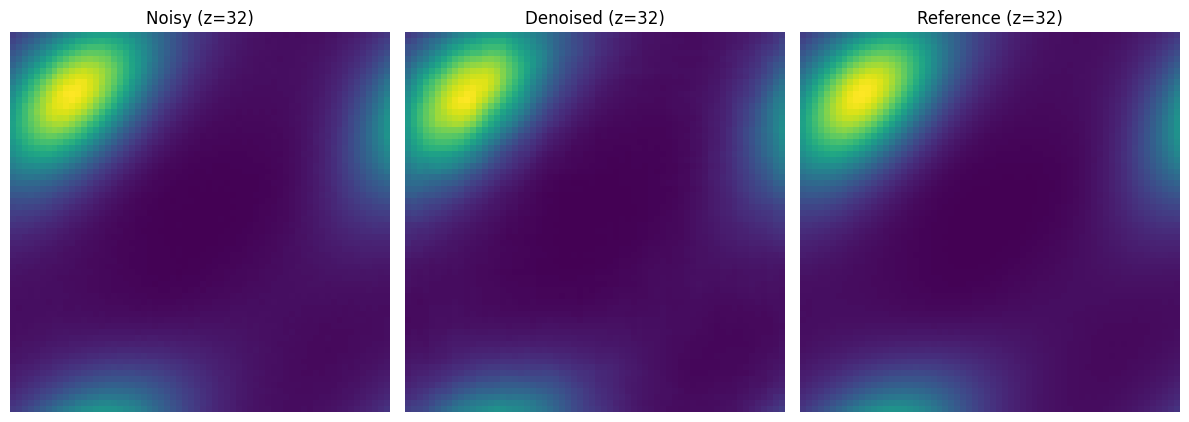

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


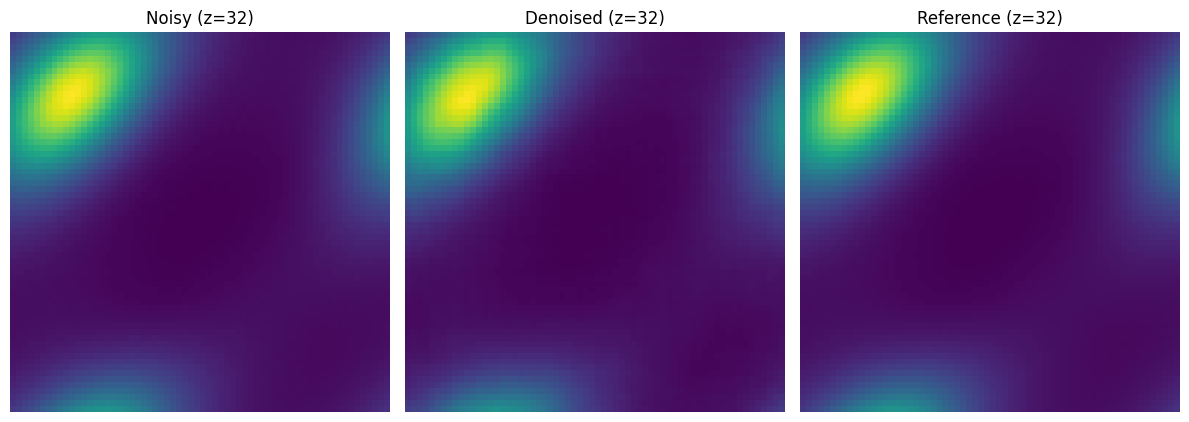

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.001111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


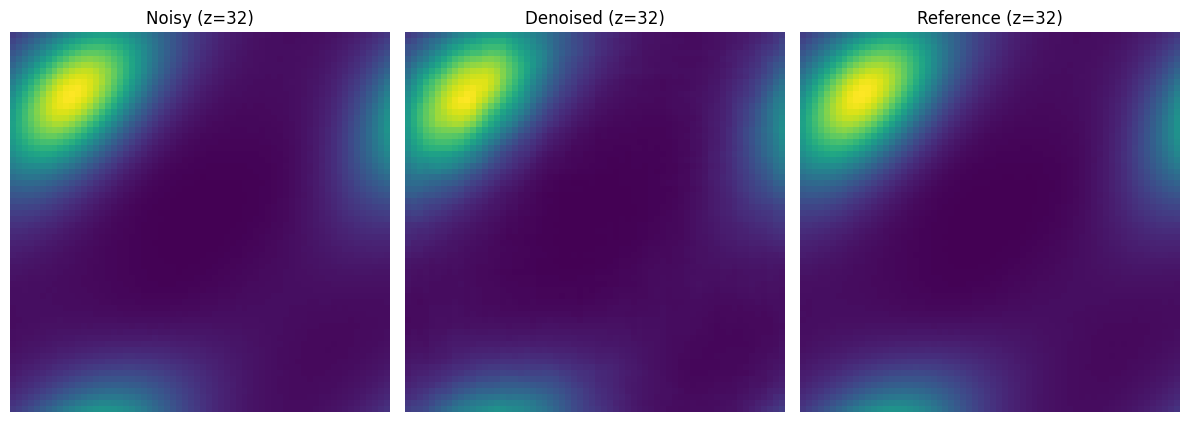

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


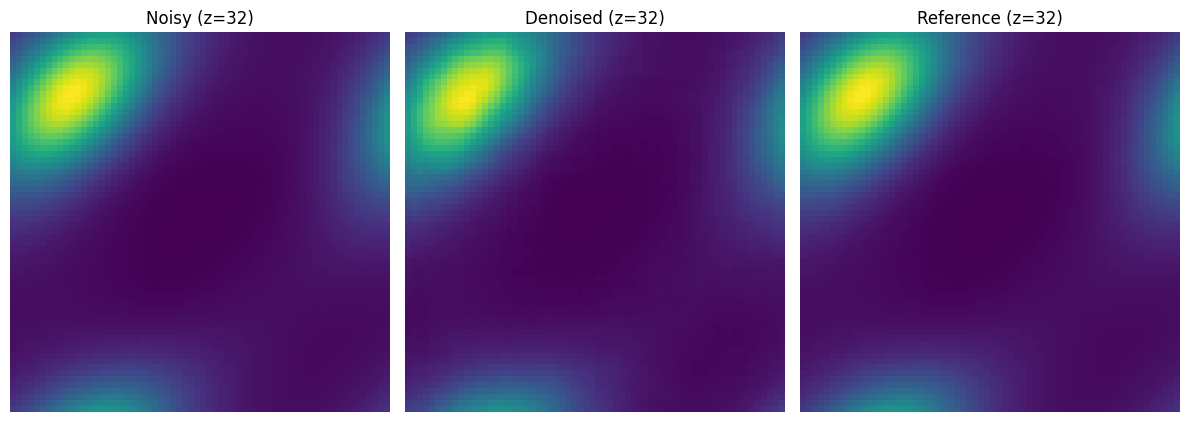


=== Running model: 238800000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.000168
(64, 64, 64) (64, 64, 64) (64, 64, 64)


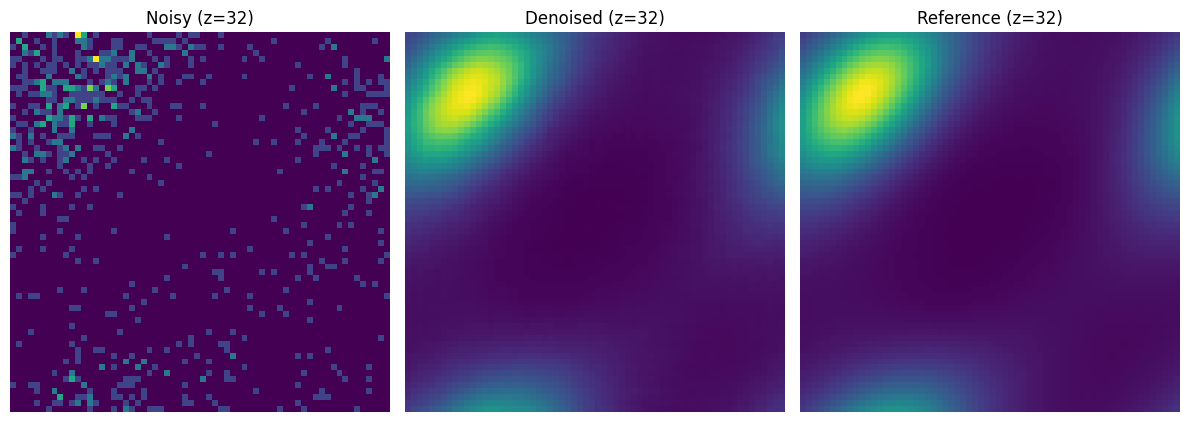

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.000164
(64, 64, 64) (64, 64, 64) (64, 64, 64)


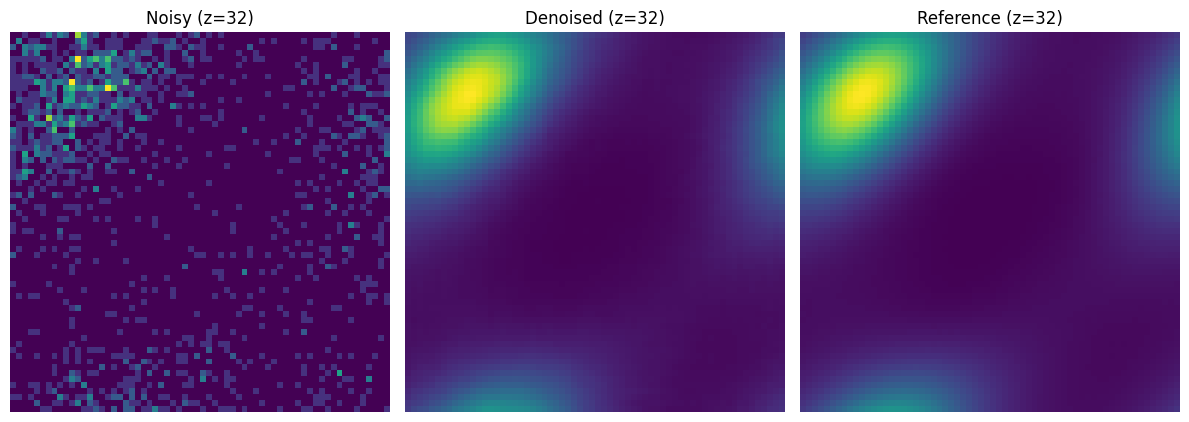

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.000161
(64, 64, 64) (64, 64, 64) (64, 64, 64)


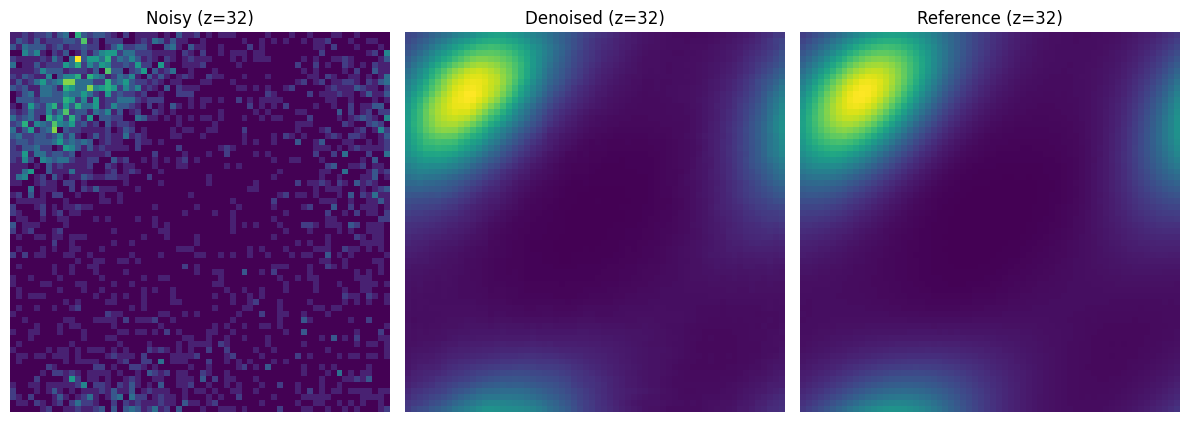

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


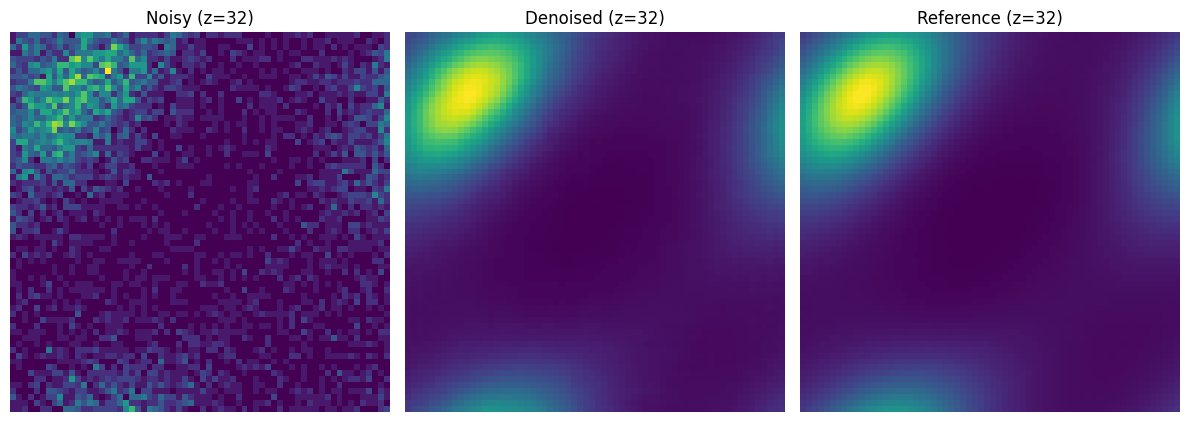

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


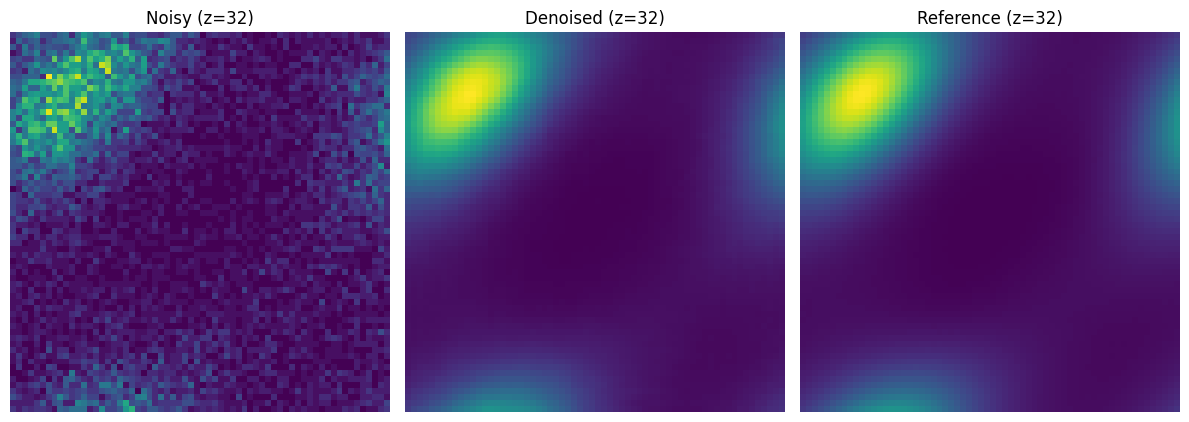

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


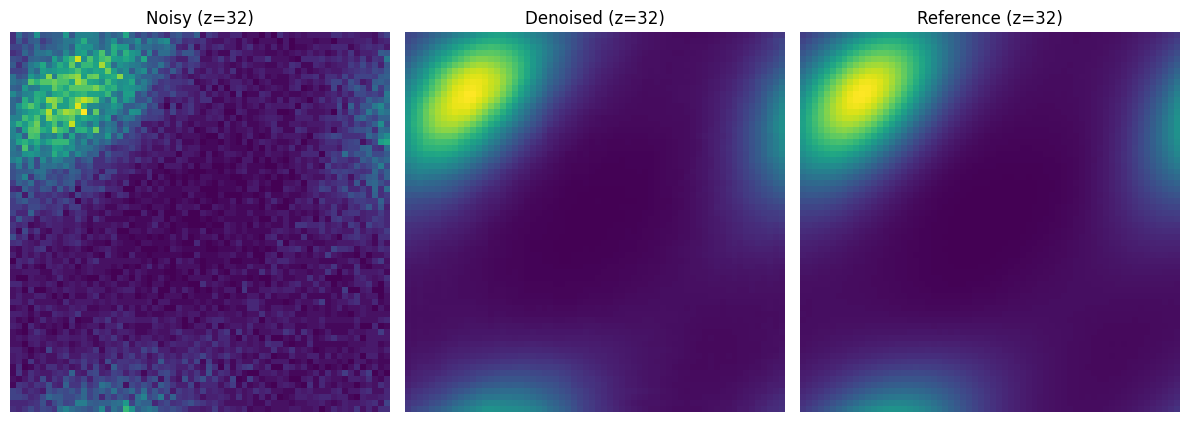

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


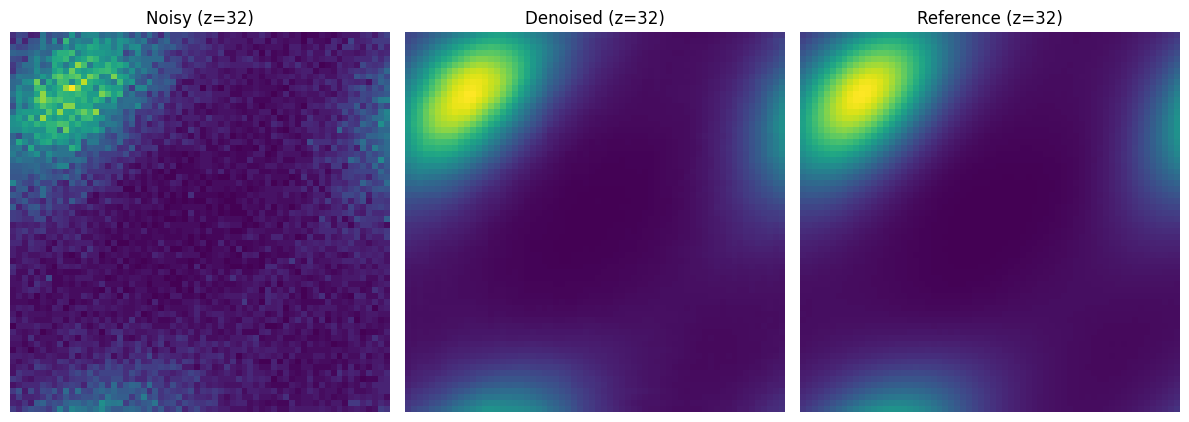

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


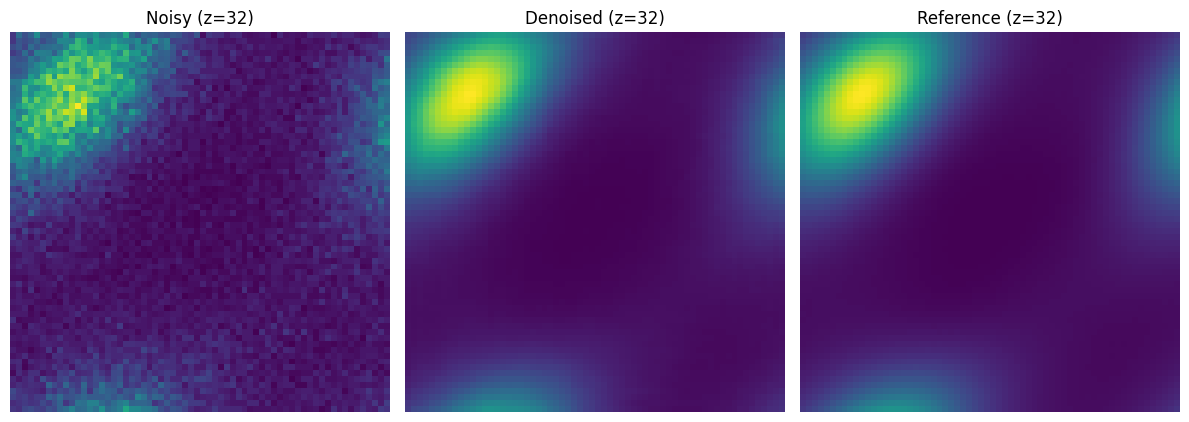

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


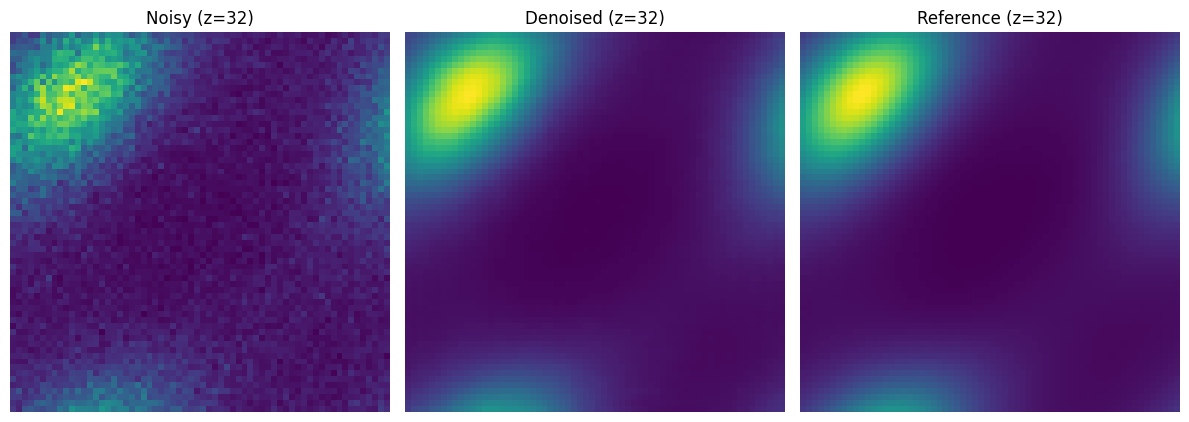

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


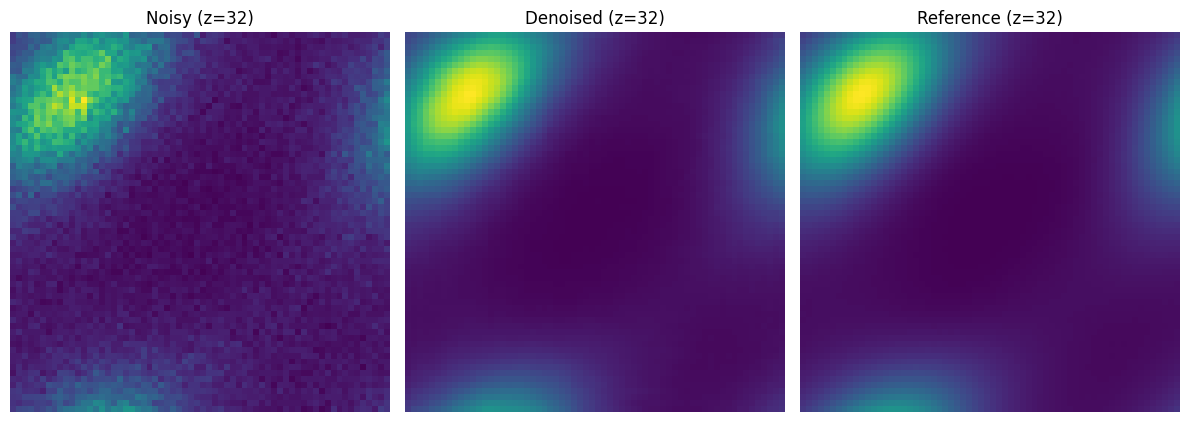

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


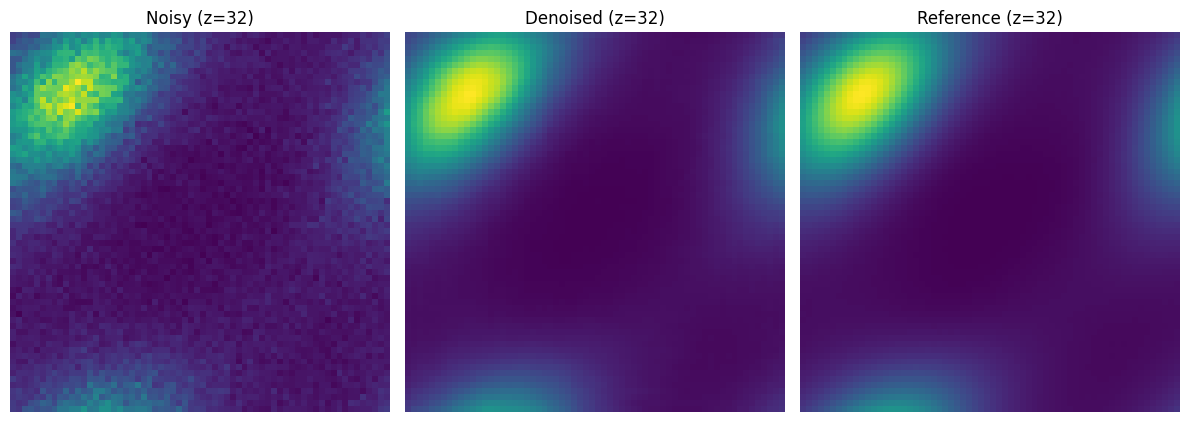

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


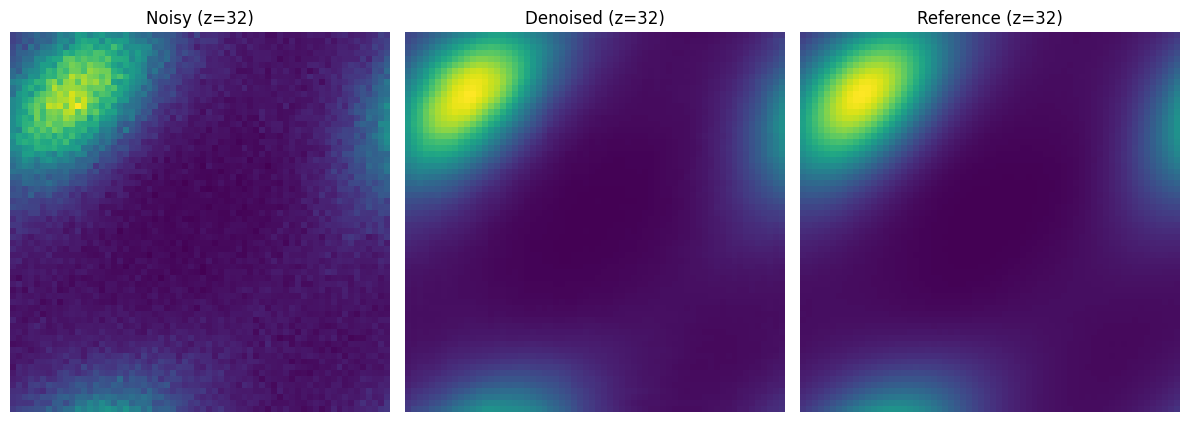

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


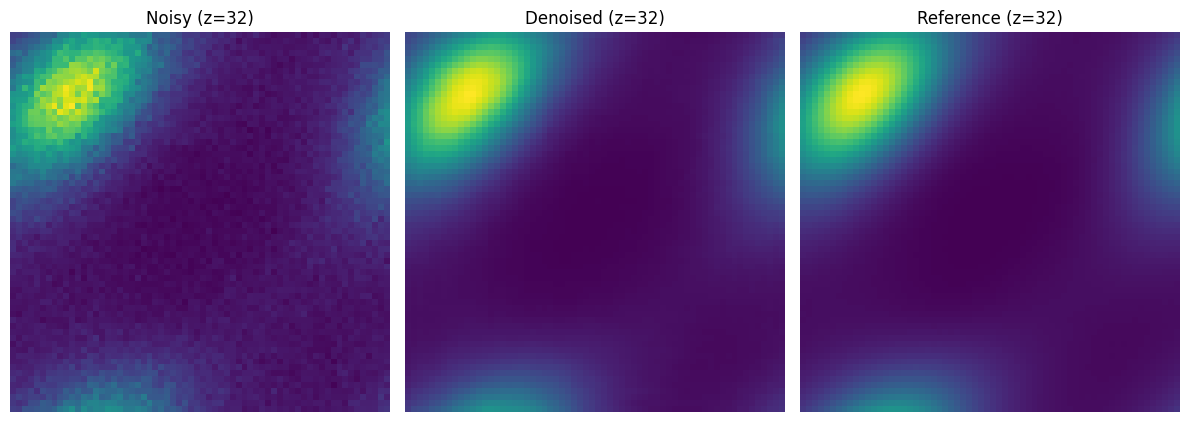

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


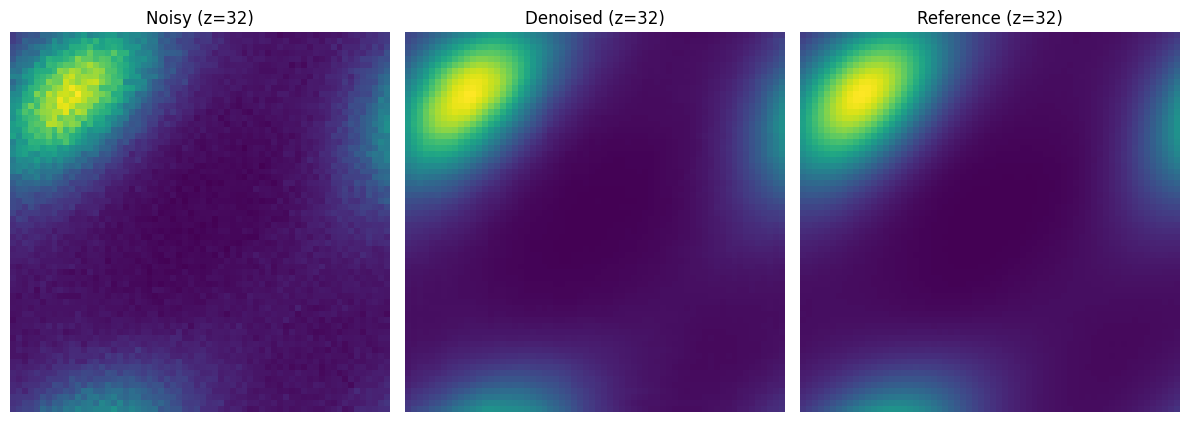

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


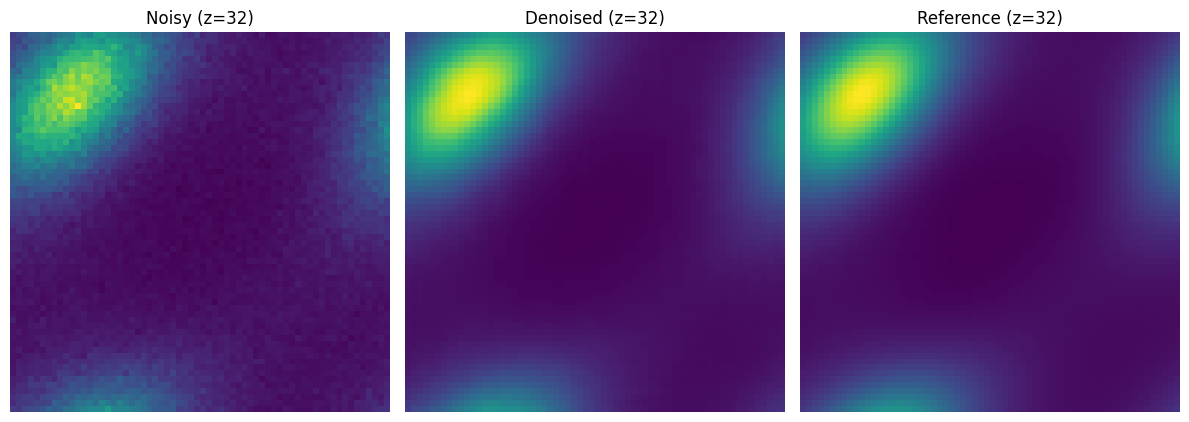

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


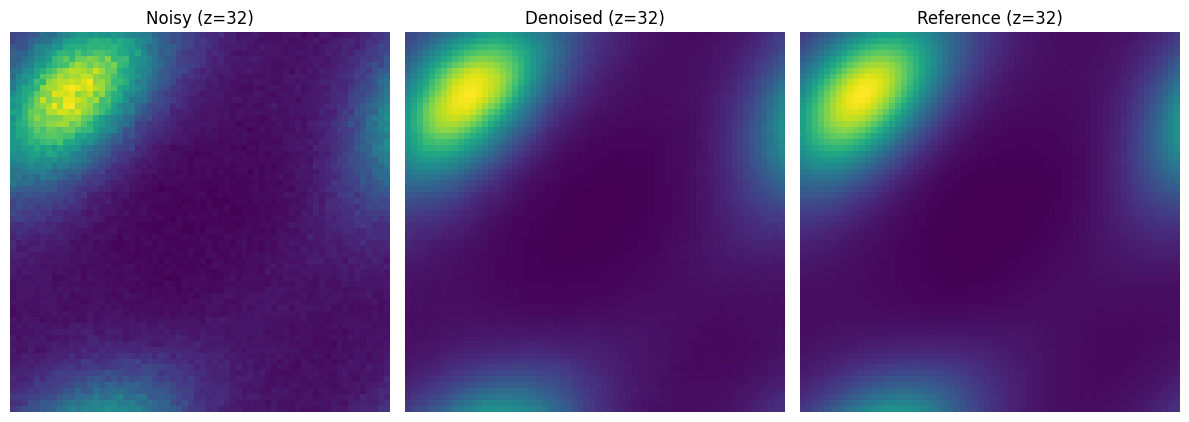

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


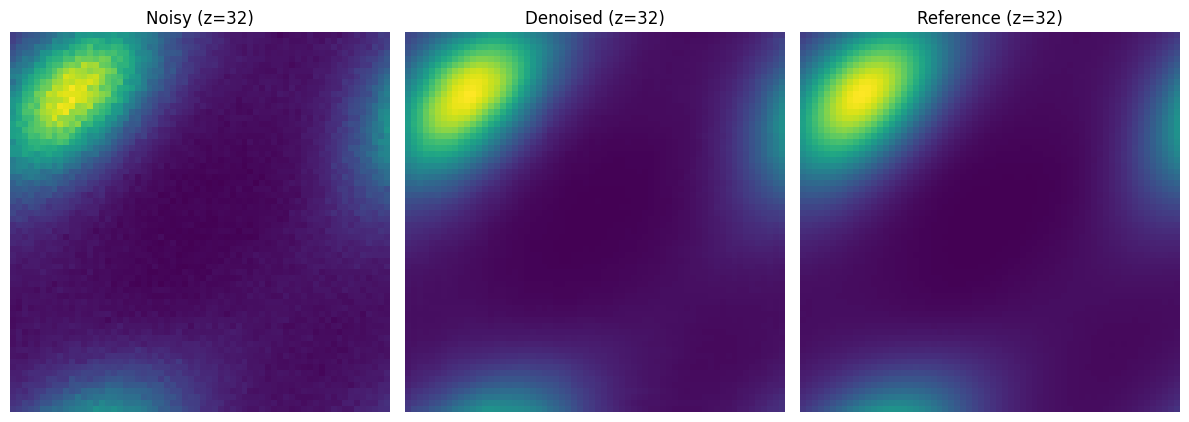

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


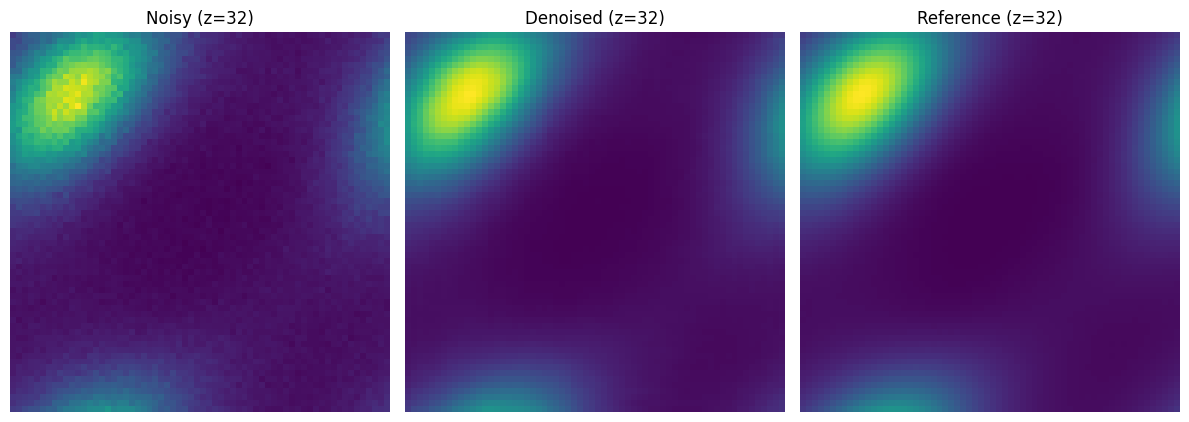

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


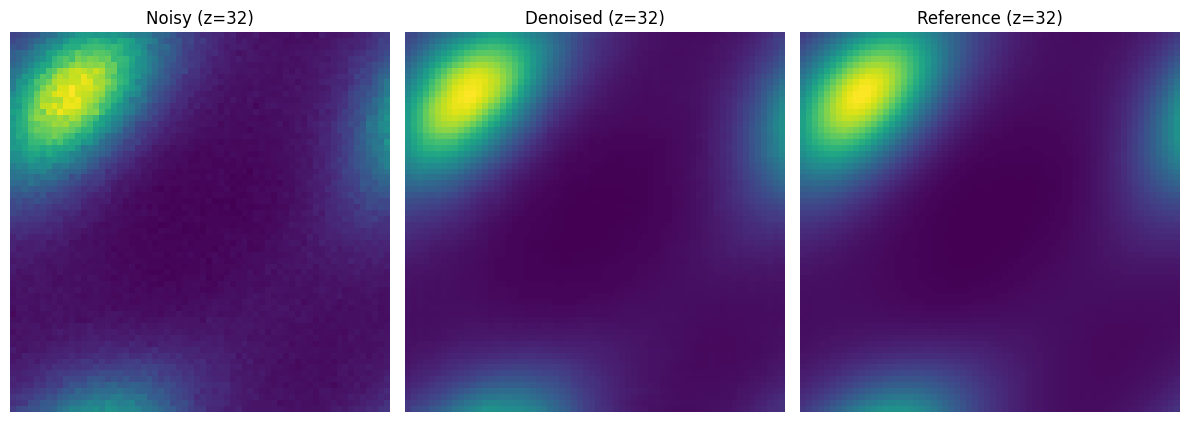

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


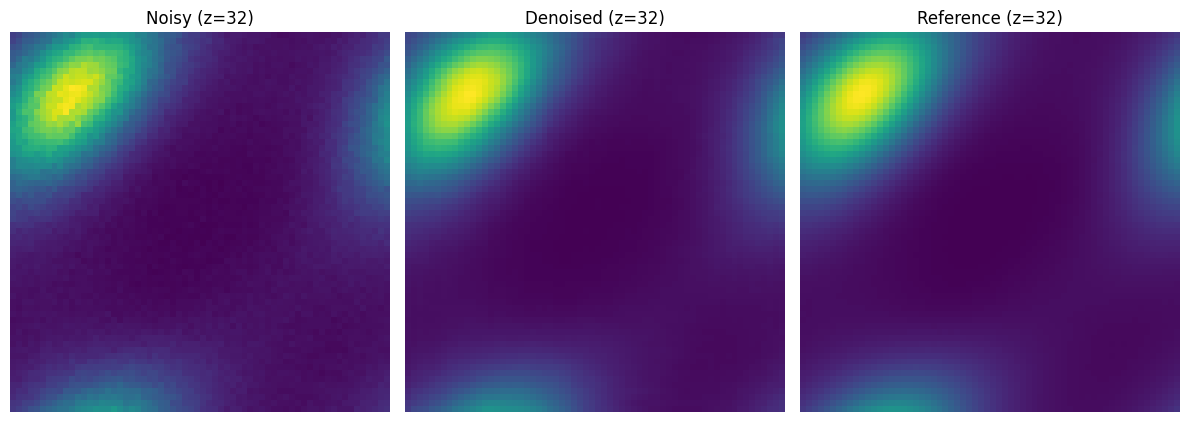

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


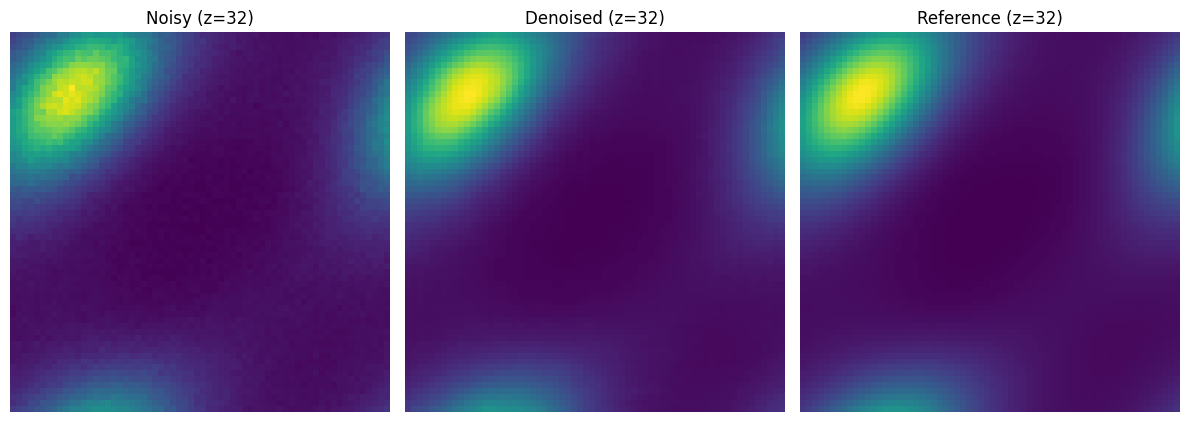

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


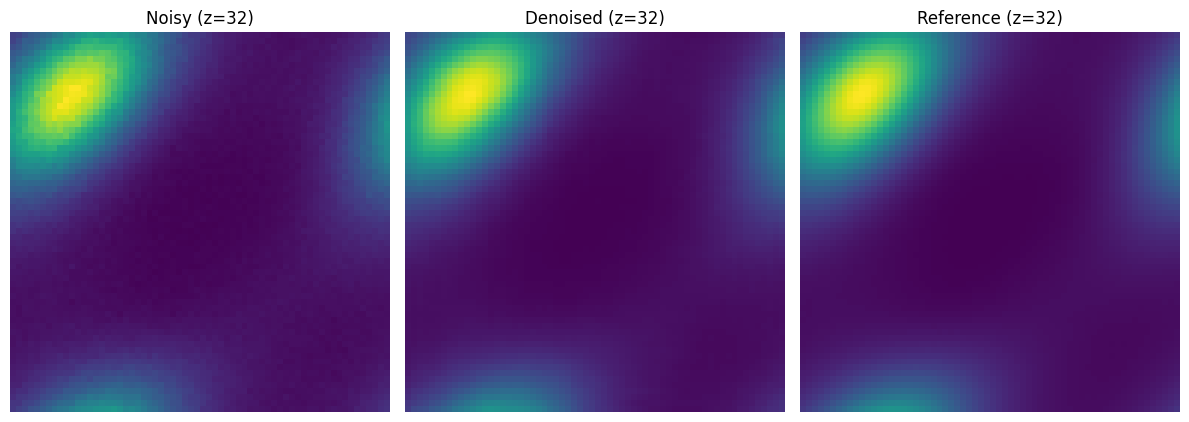

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


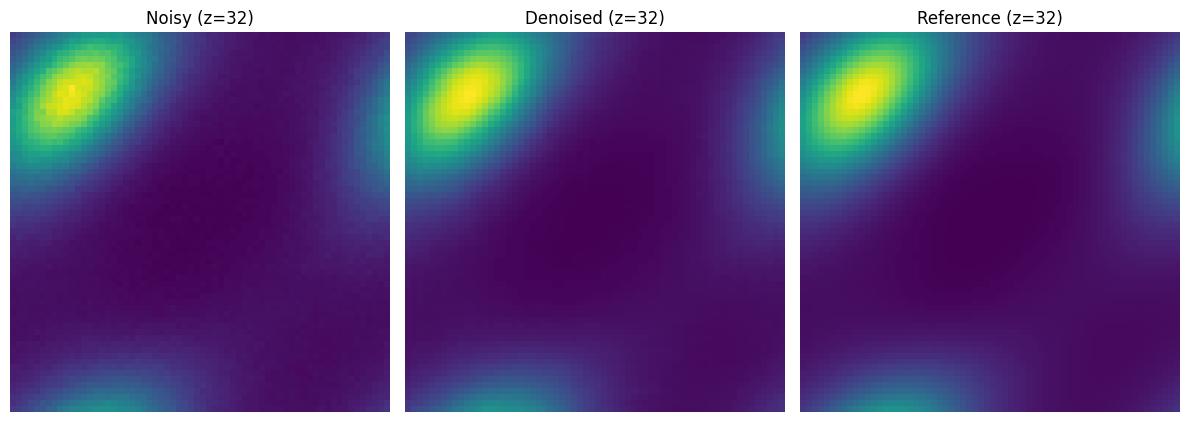

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000157
(64, 64, 64) (64, 64, 64) (64, 64, 64)


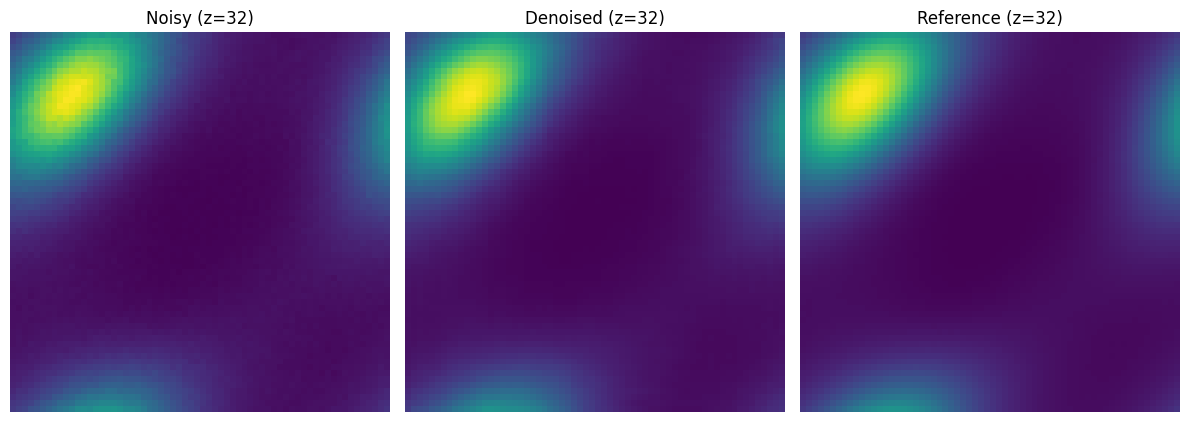

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


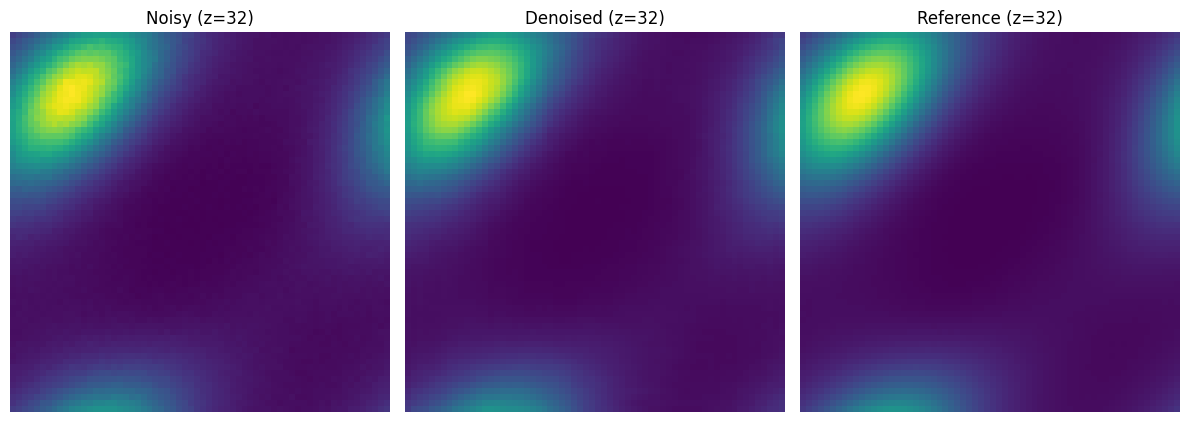

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


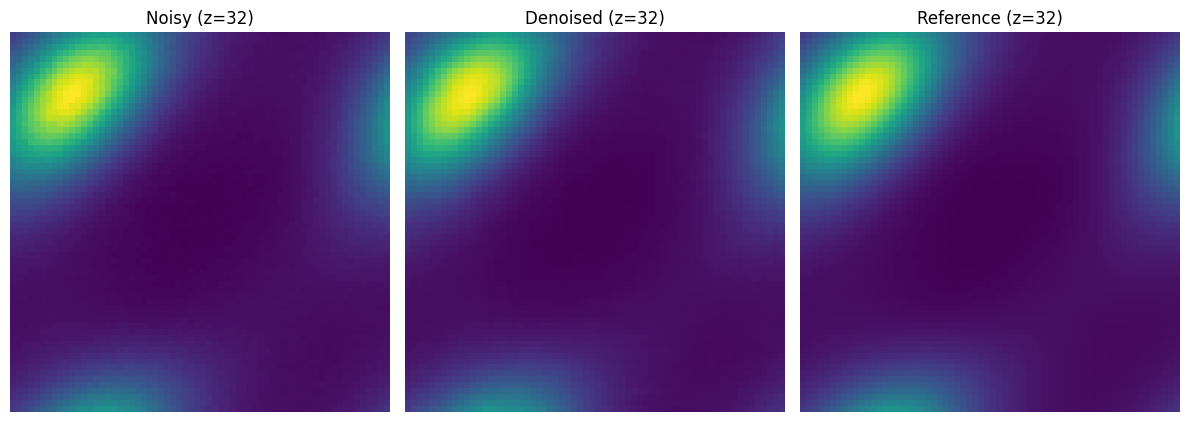

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


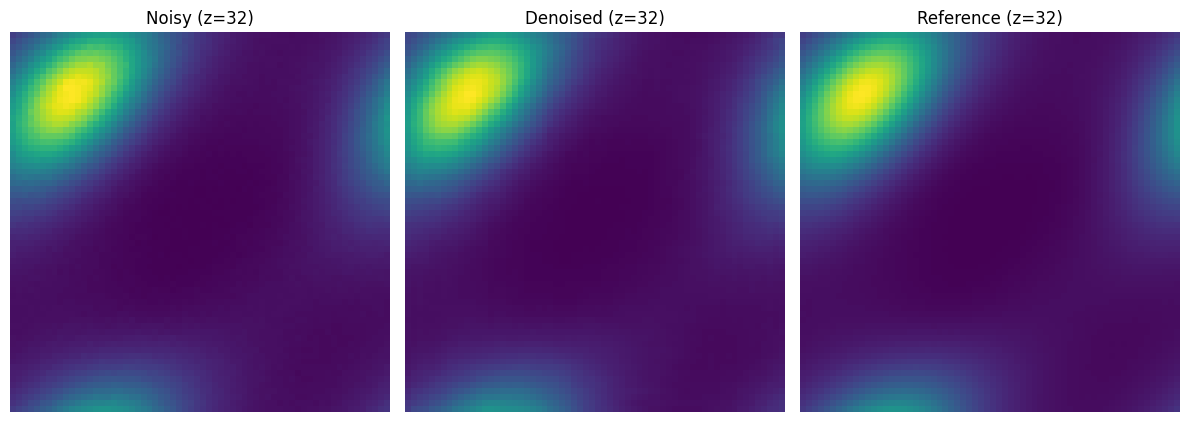

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


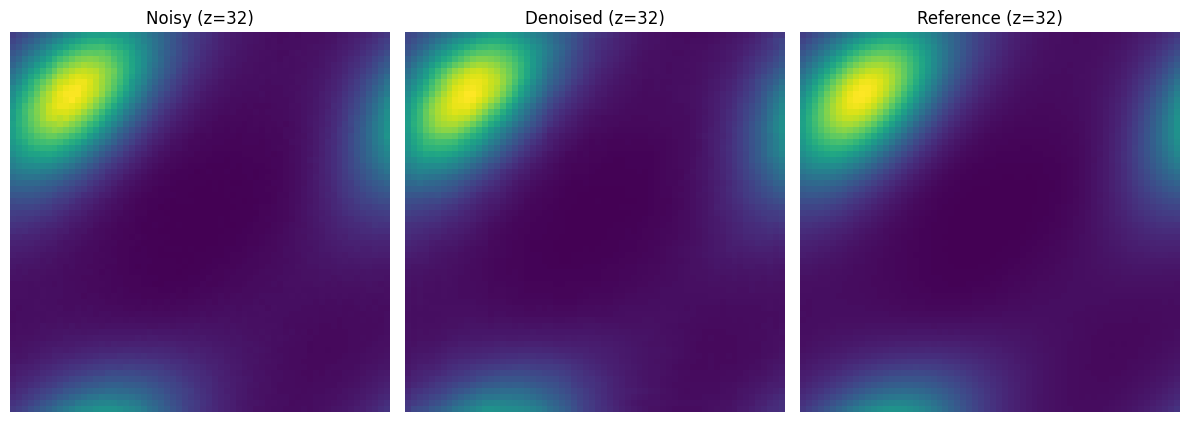

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


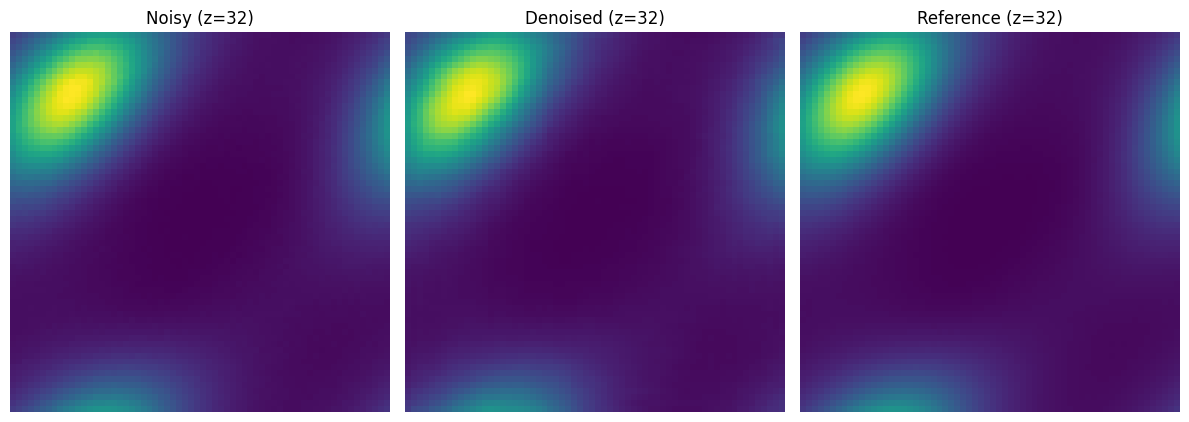

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


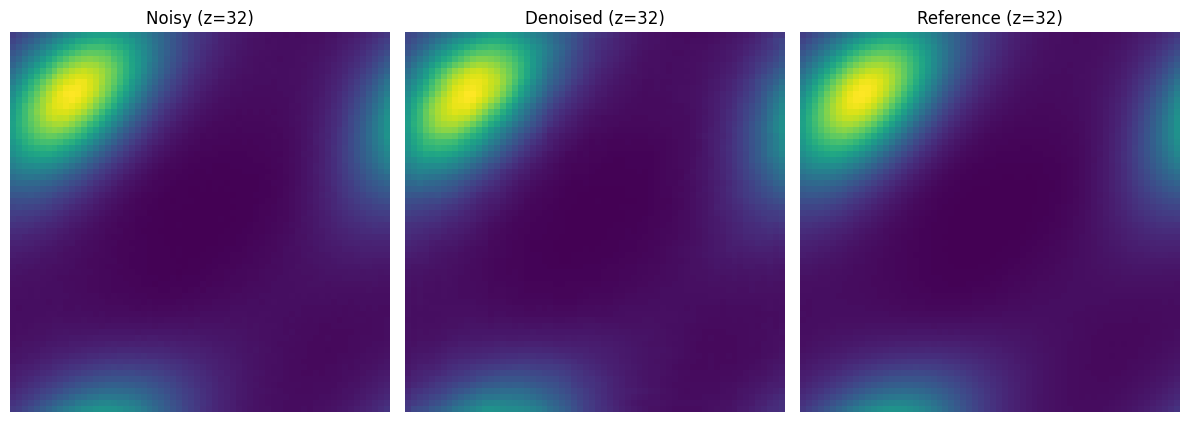

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


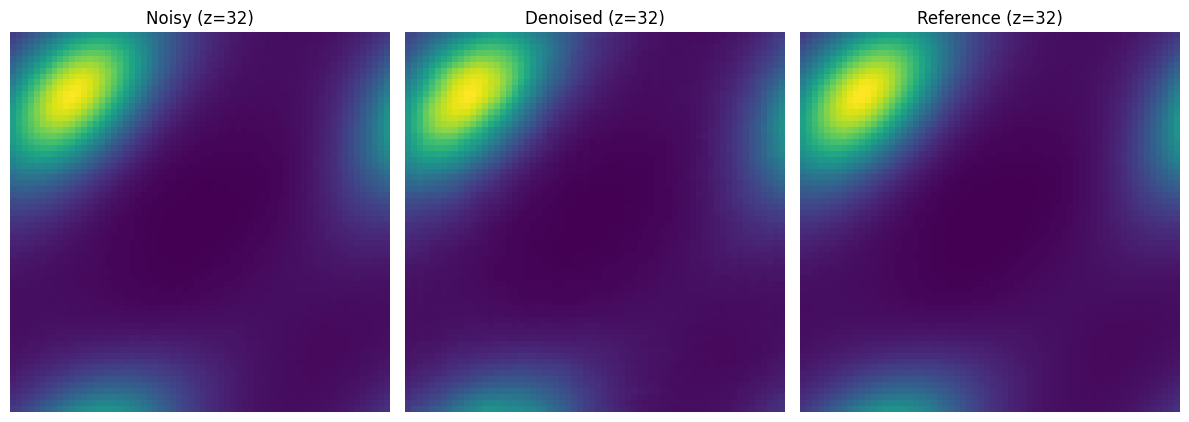

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


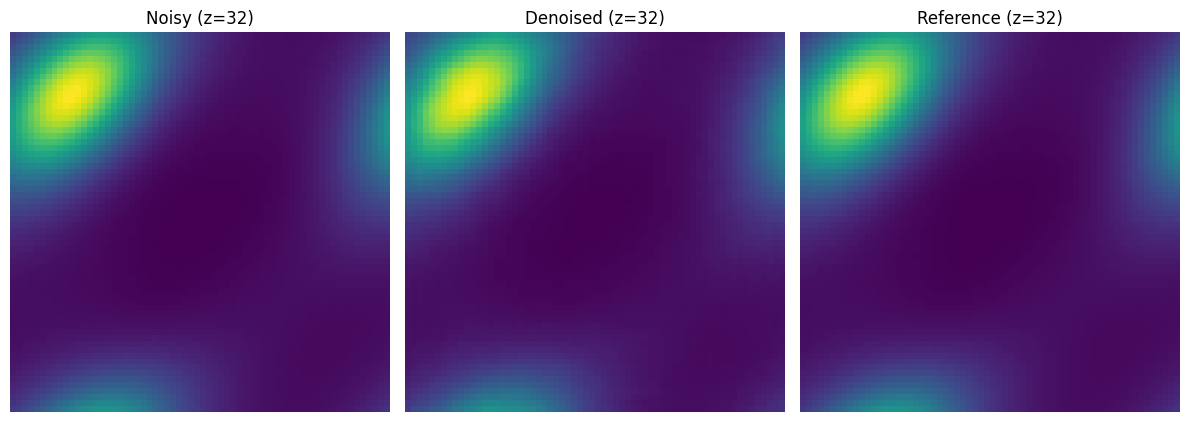

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


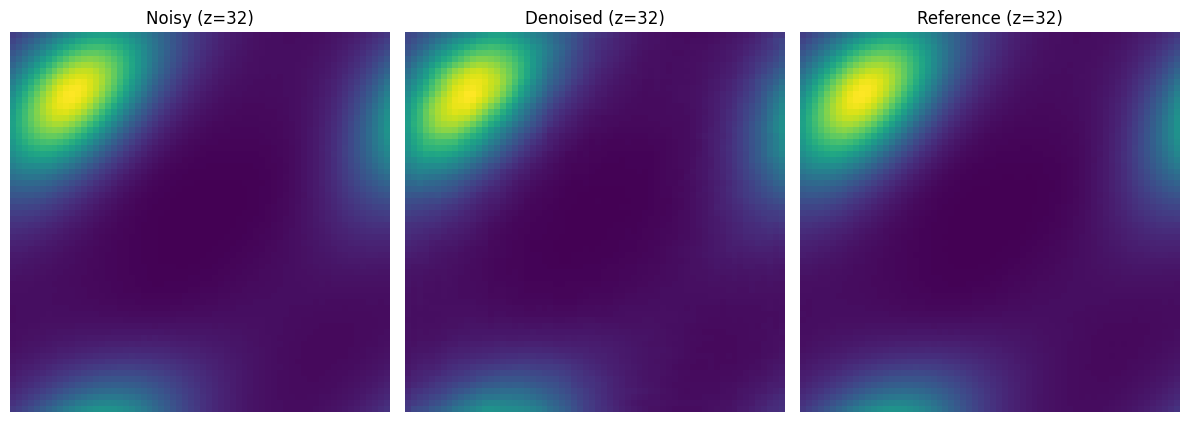


=== Running model: 23930000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.000246
(64, 64, 64) (64, 64, 64) (64, 64, 64)


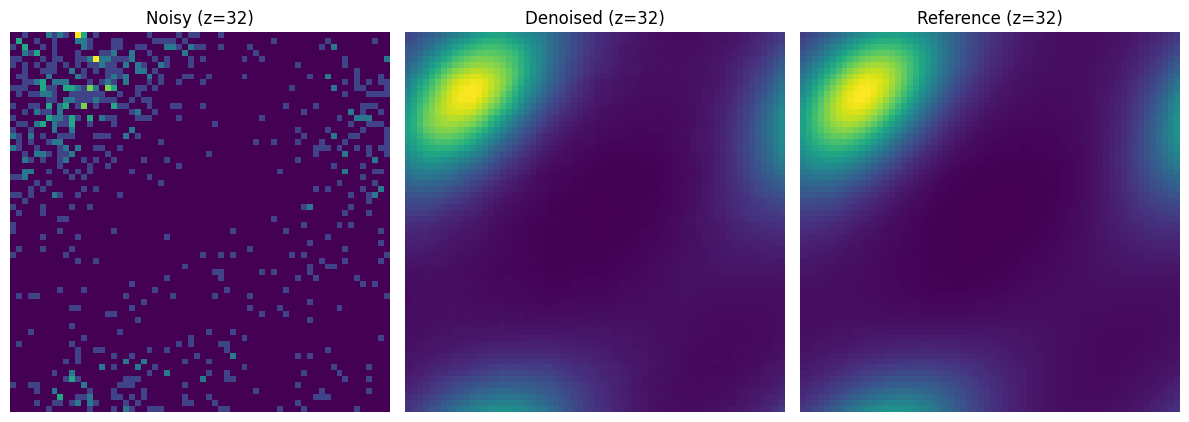

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.000241
(64, 64, 64) (64, 64, 64) (64, 64, 64)


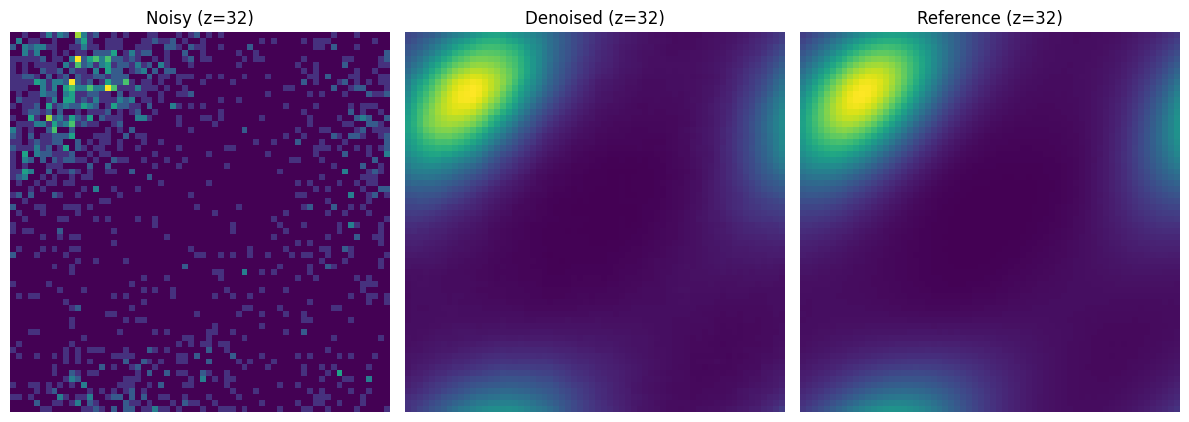

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.000238
(64, 64, 64) (64, 64, 64) (64, 64, 64)


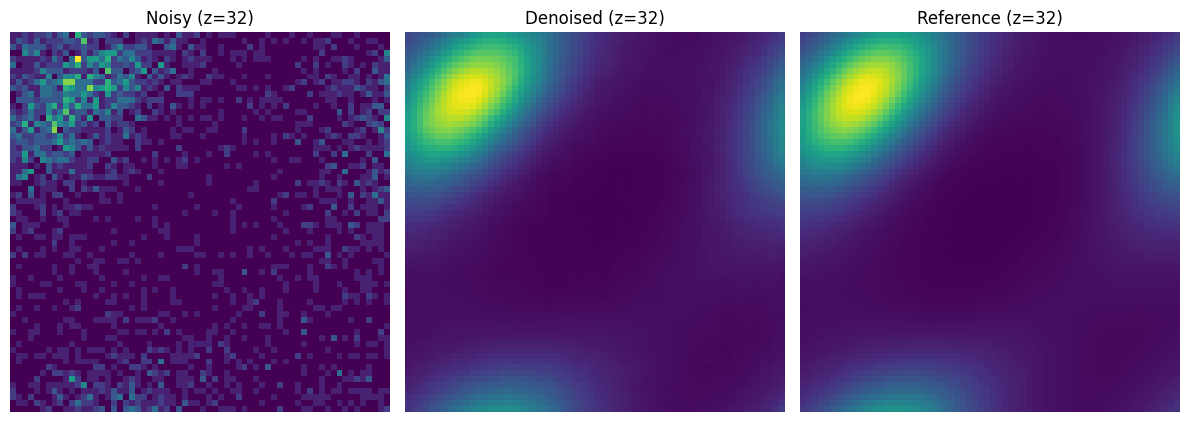

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.000236
(64, 64, 64) (64, 64, 64) (64, 64, 64)


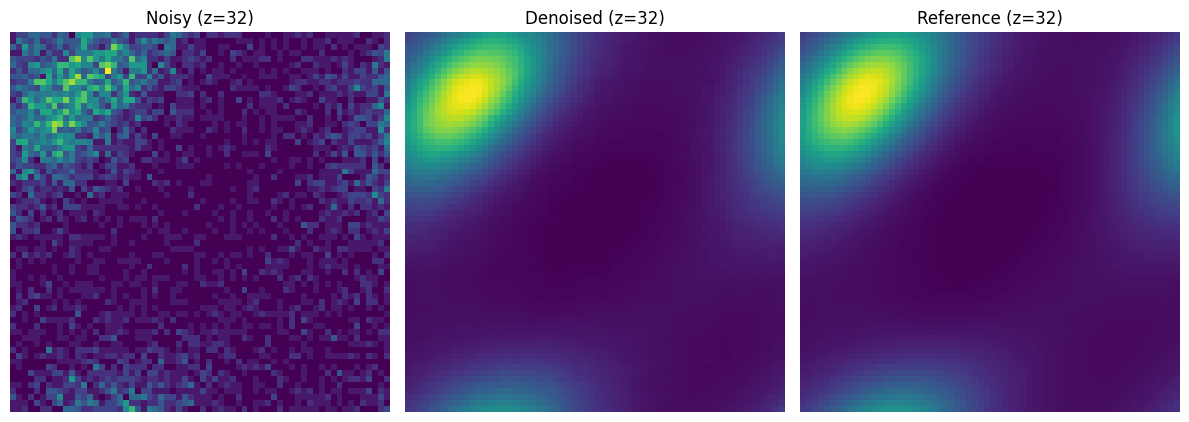

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.000236
(64, 64, 64) (64, 64, 64) (64, 64, 64)


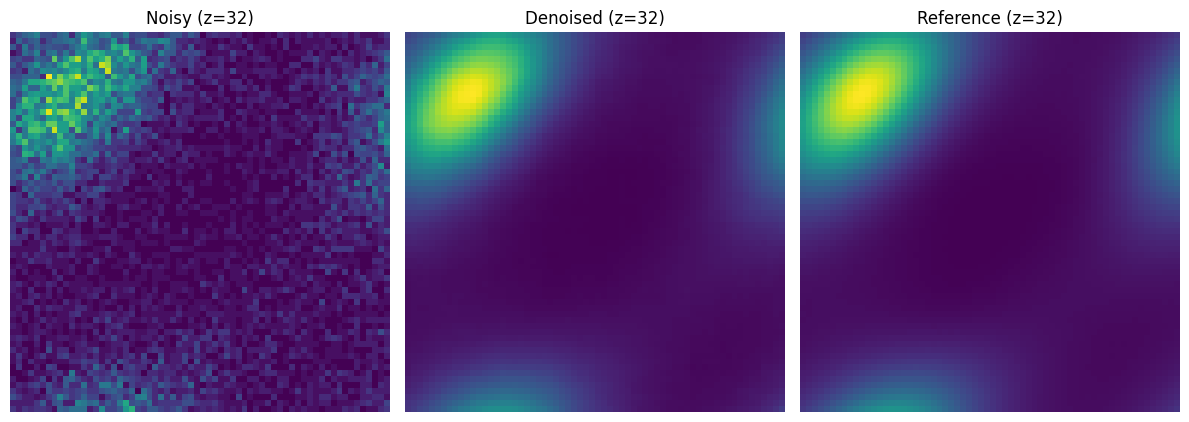

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


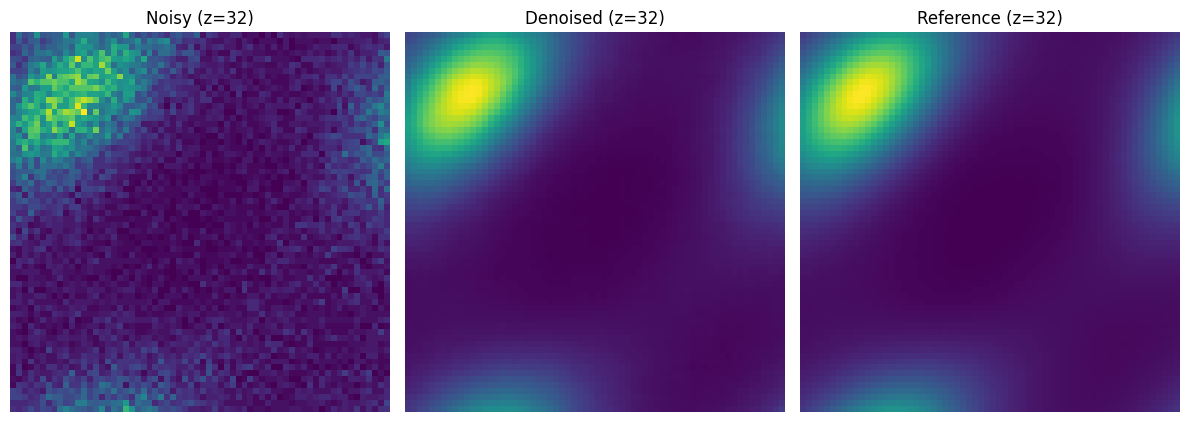

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


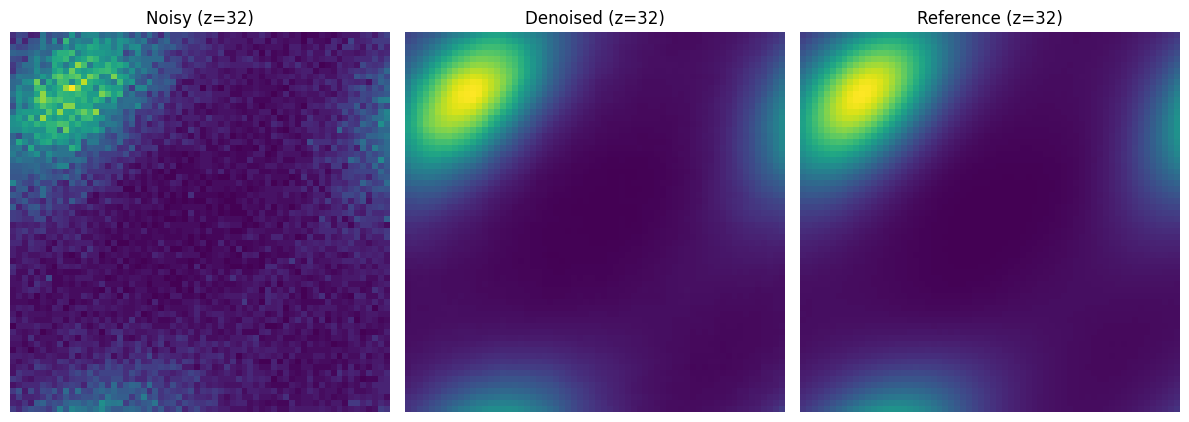

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


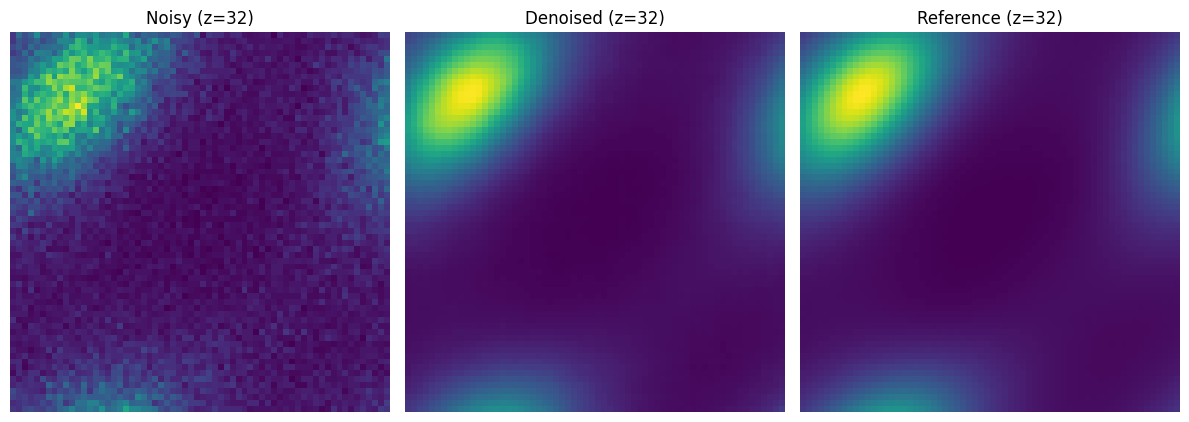

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


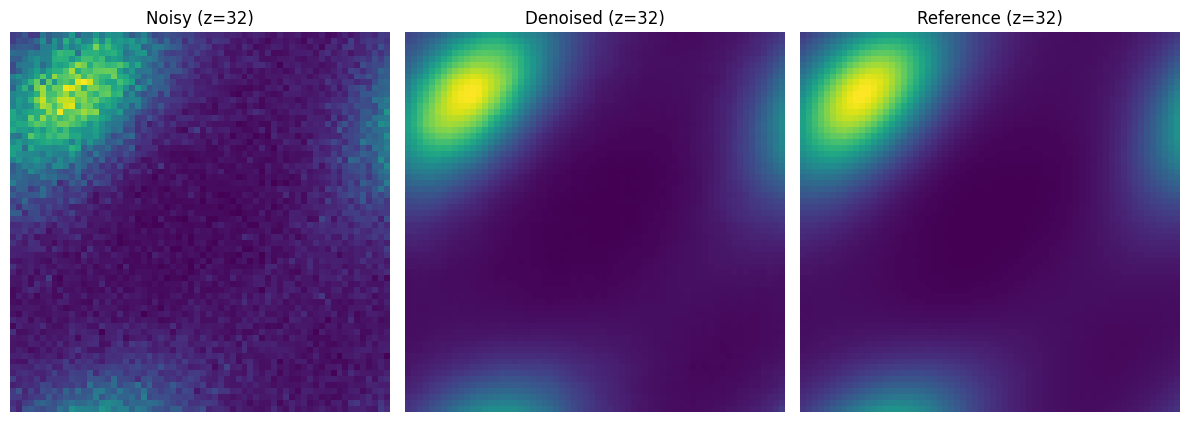

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


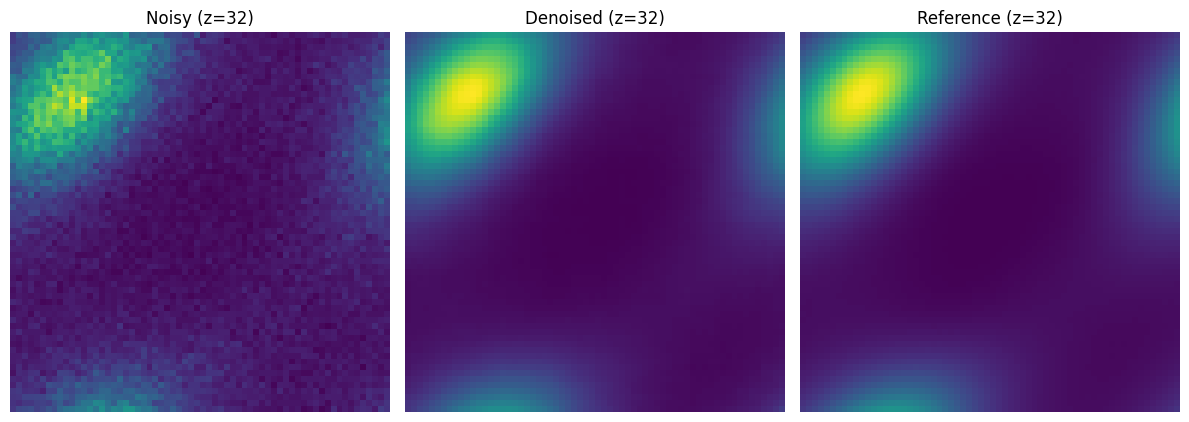

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


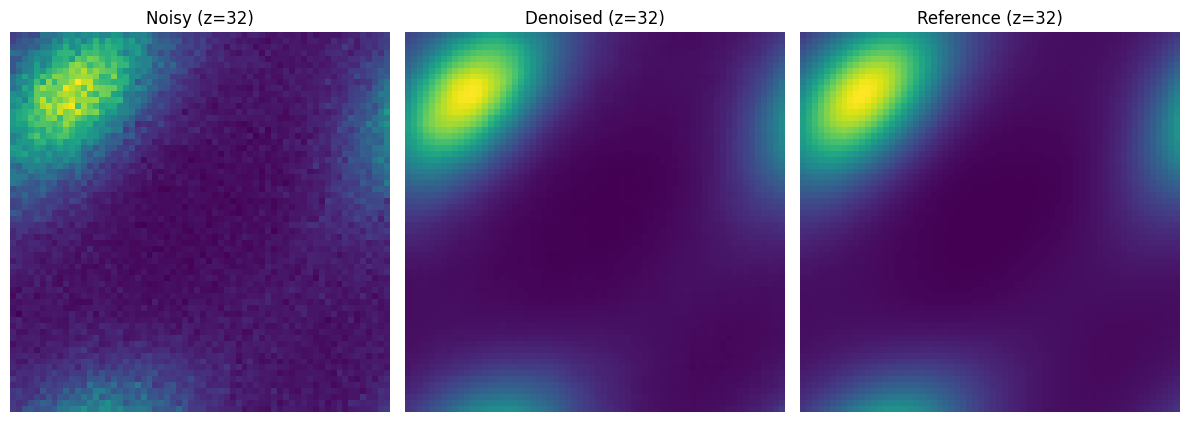

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


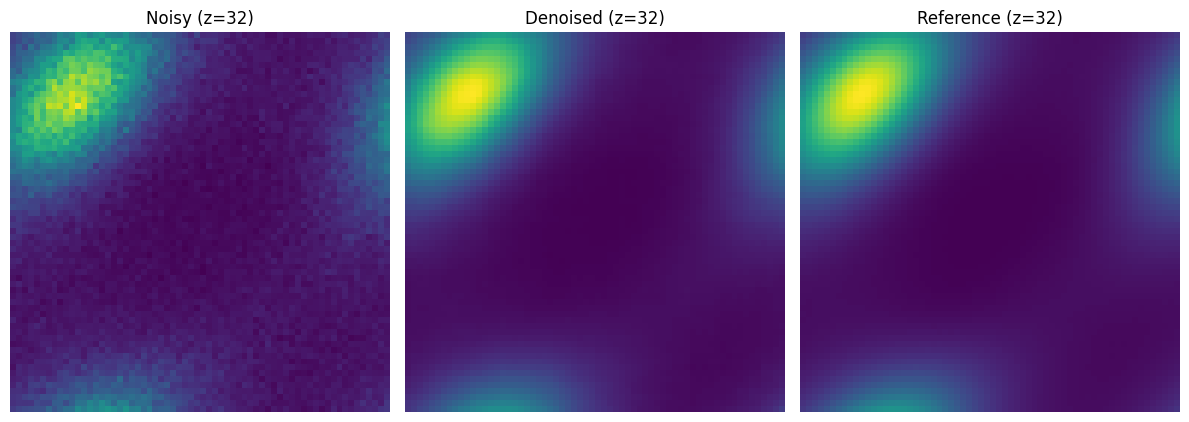

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


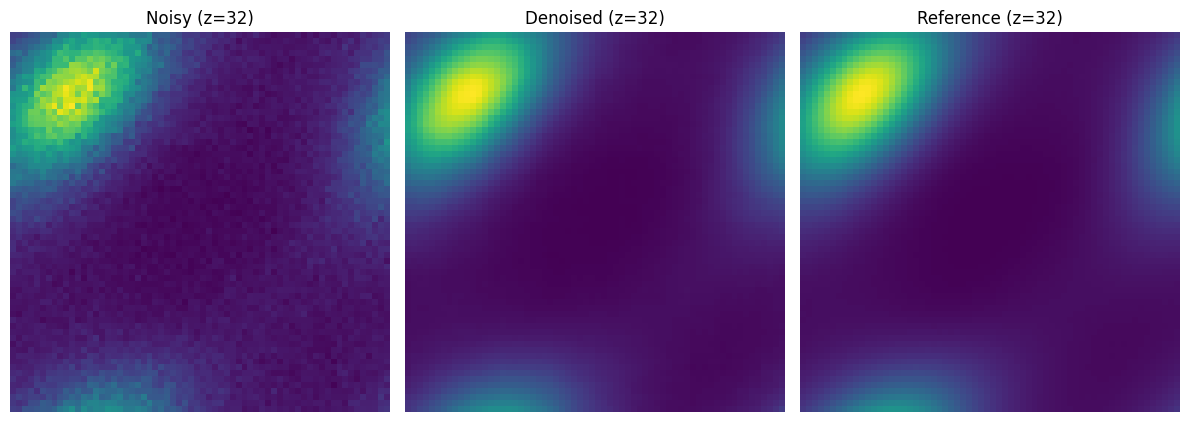

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


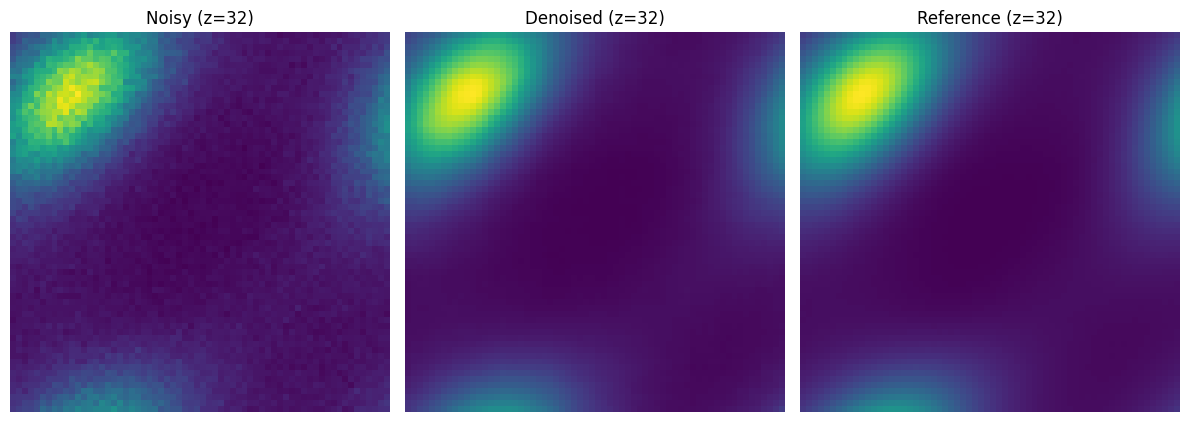

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


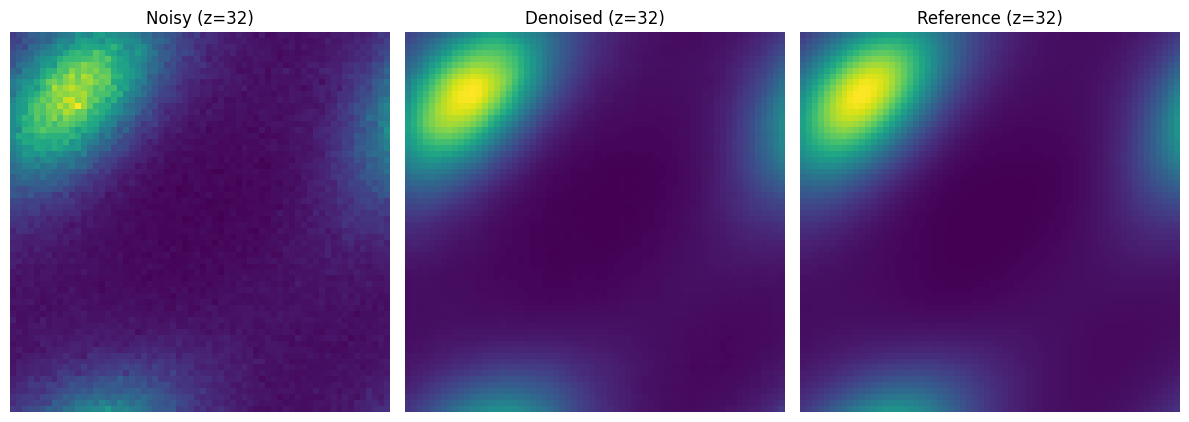

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.000233
(64, 64, 64) (64, 64, 64) (64, 64, 64)


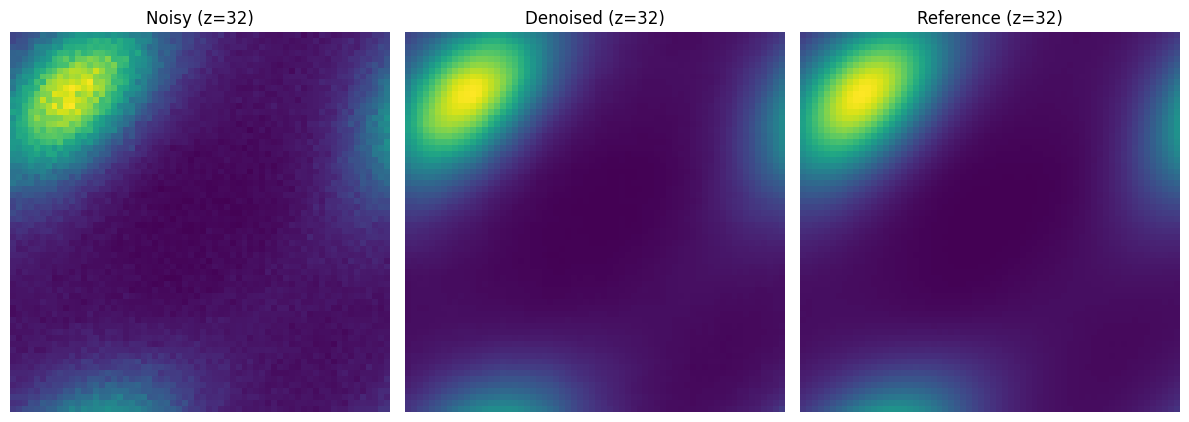

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


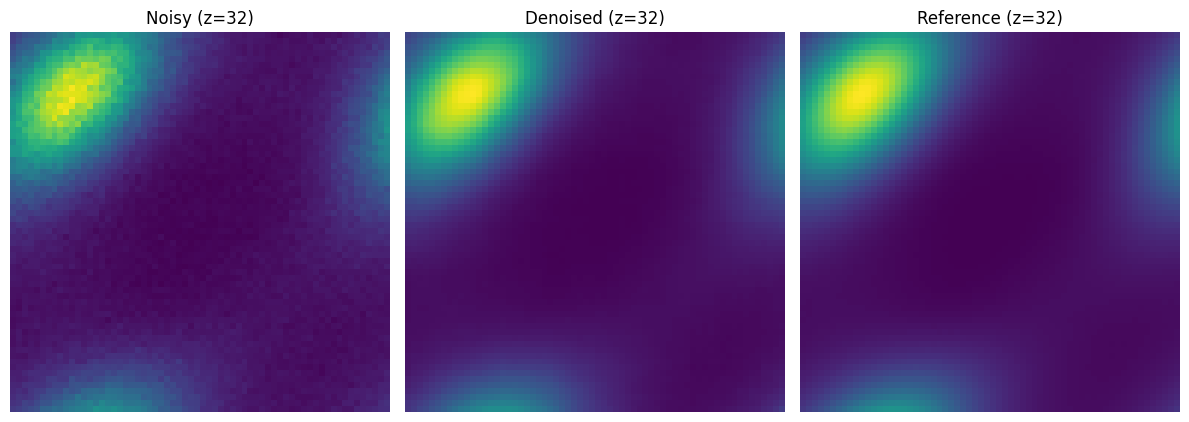

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


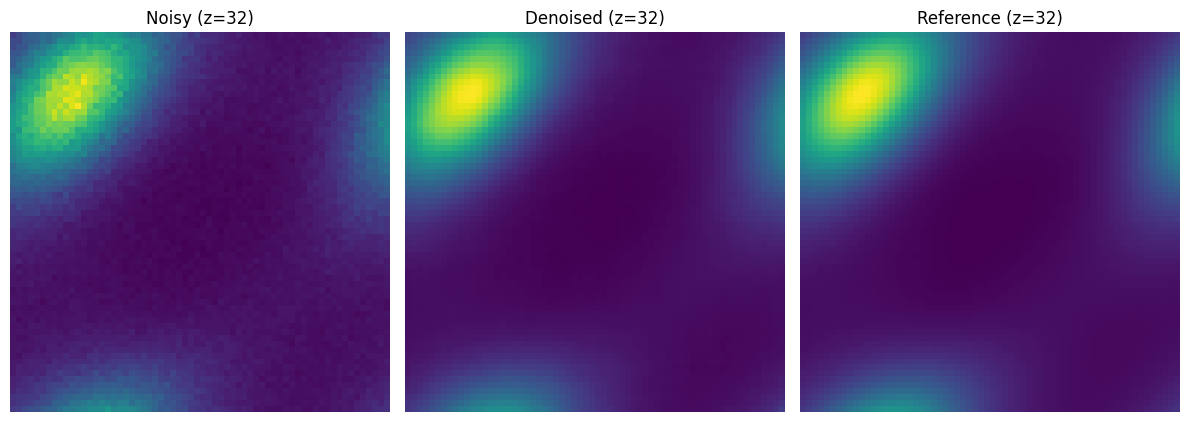

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.000233
(64, 64, 64) (64, 64, 64) (64, 64, 64)


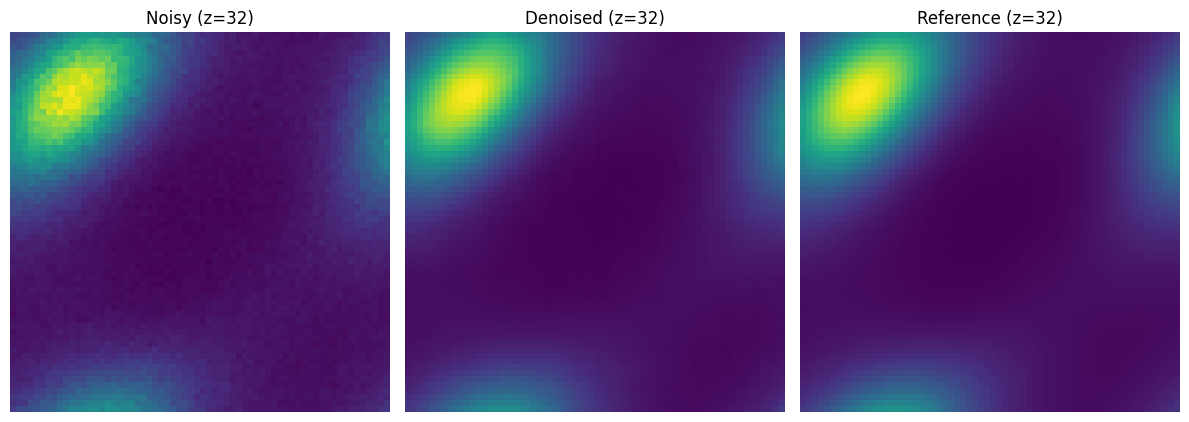

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


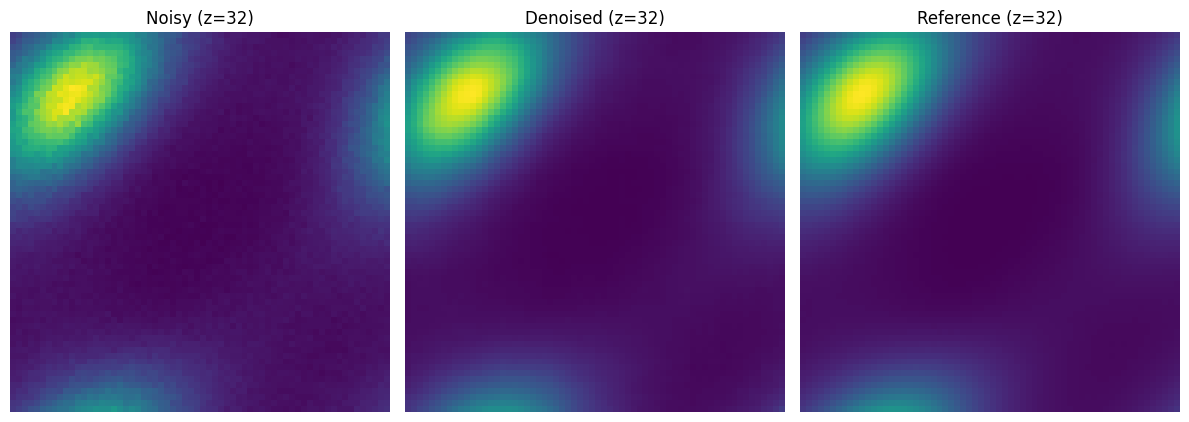

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


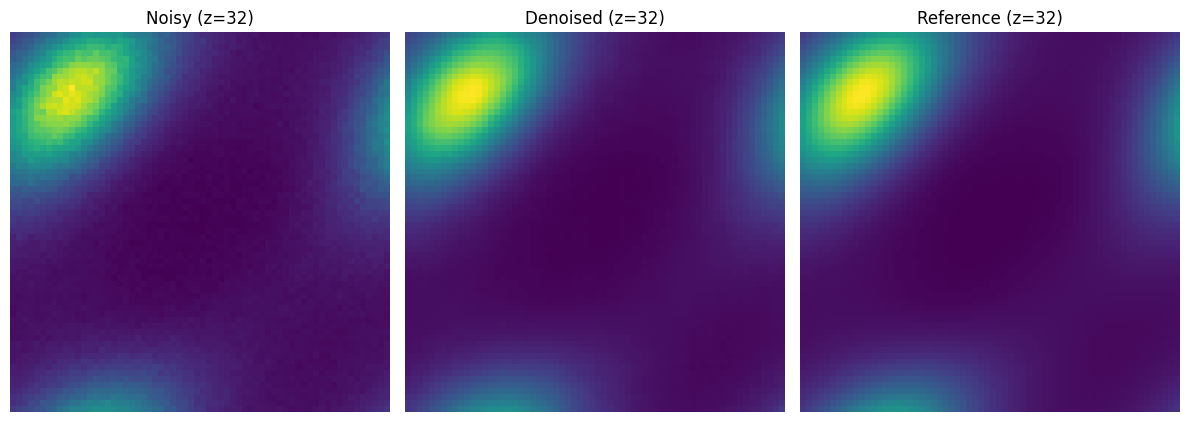

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


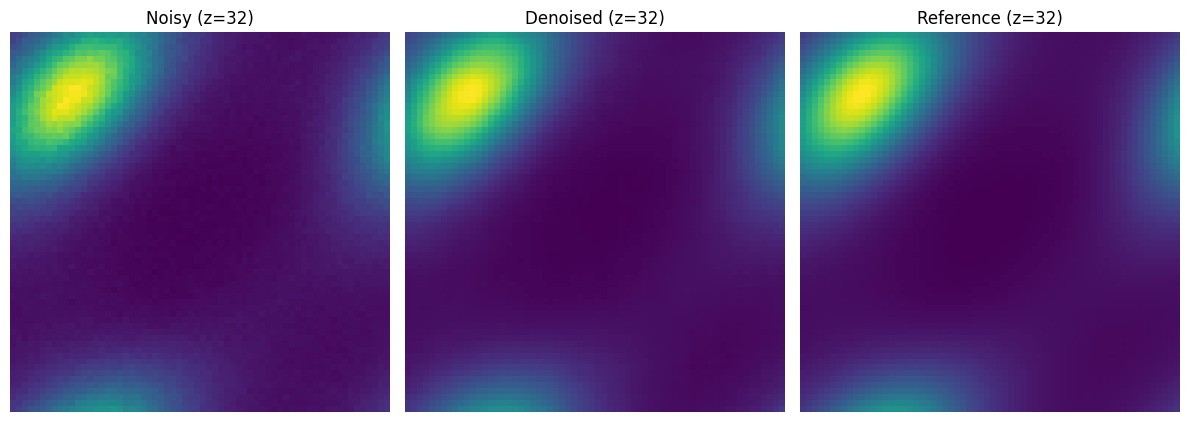

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


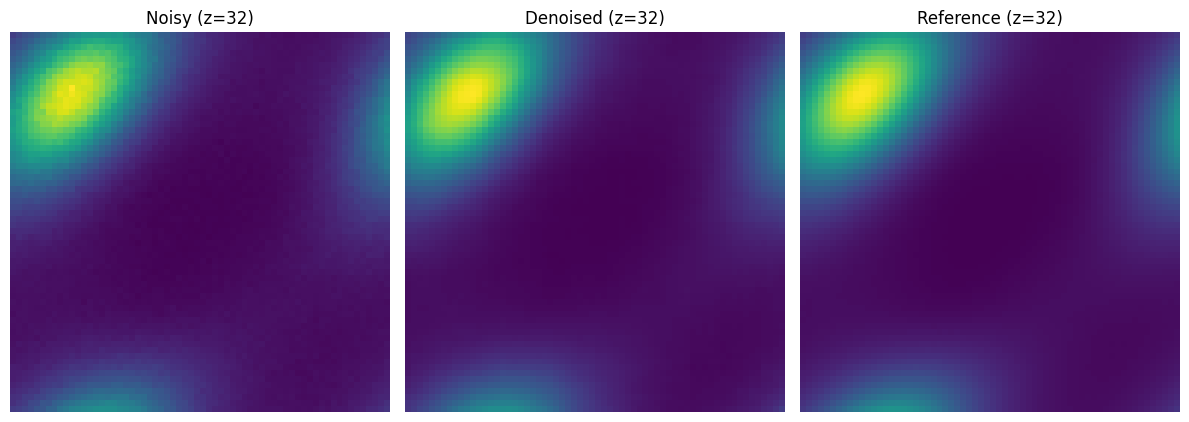

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


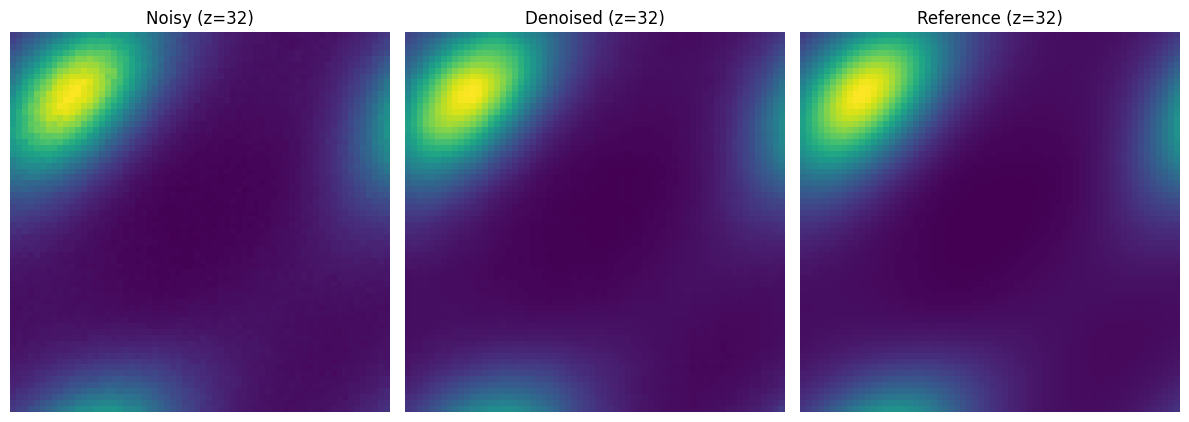

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


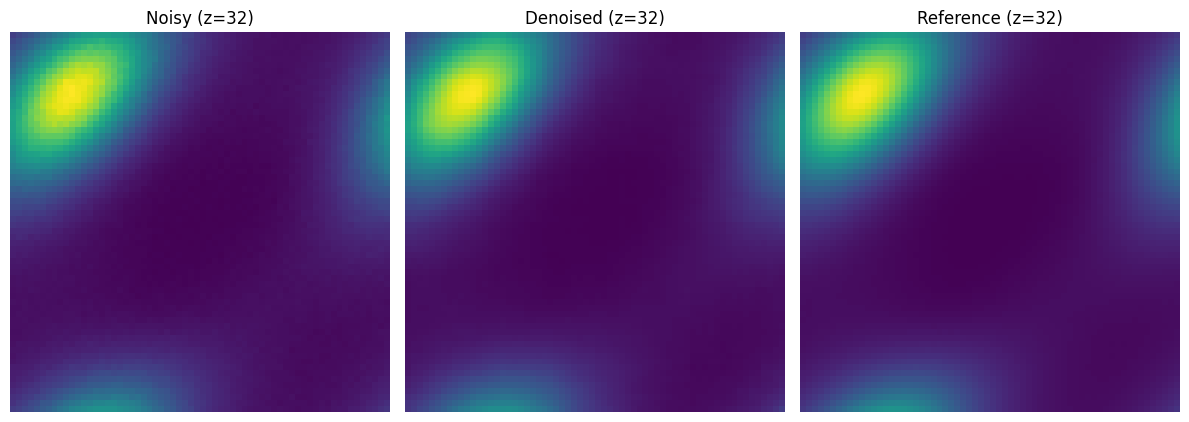

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


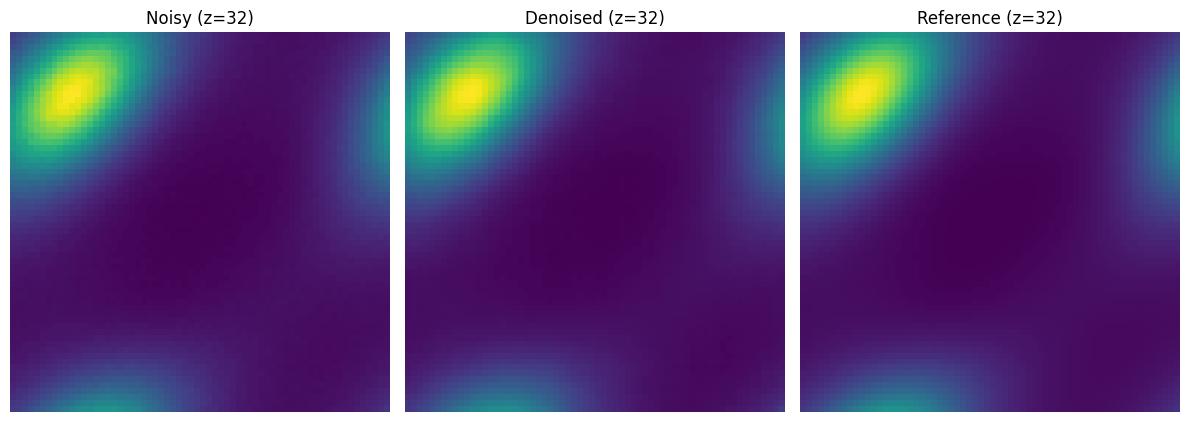

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


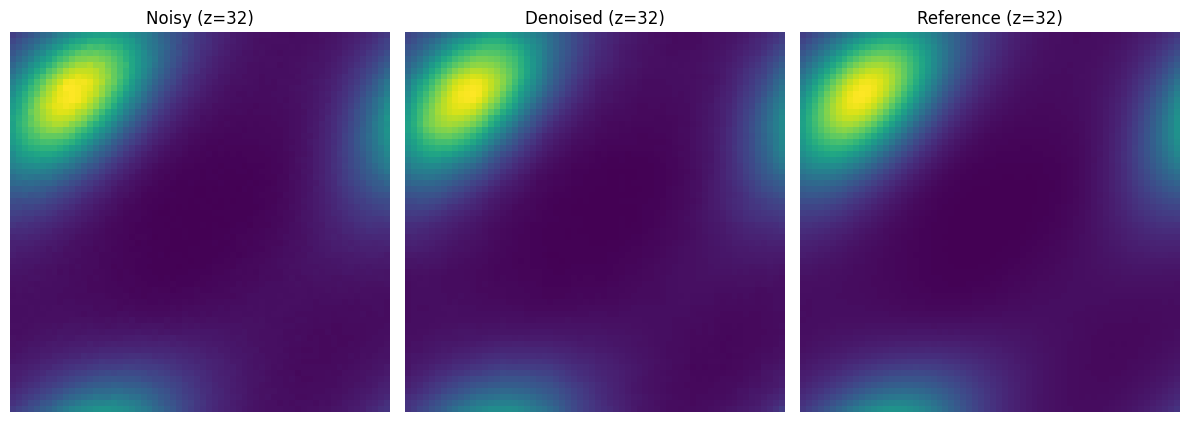

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


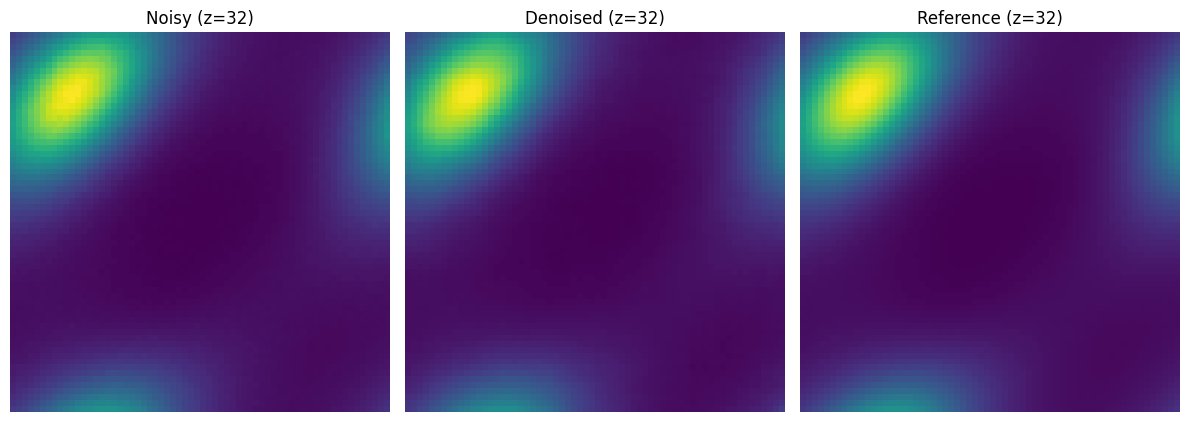

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


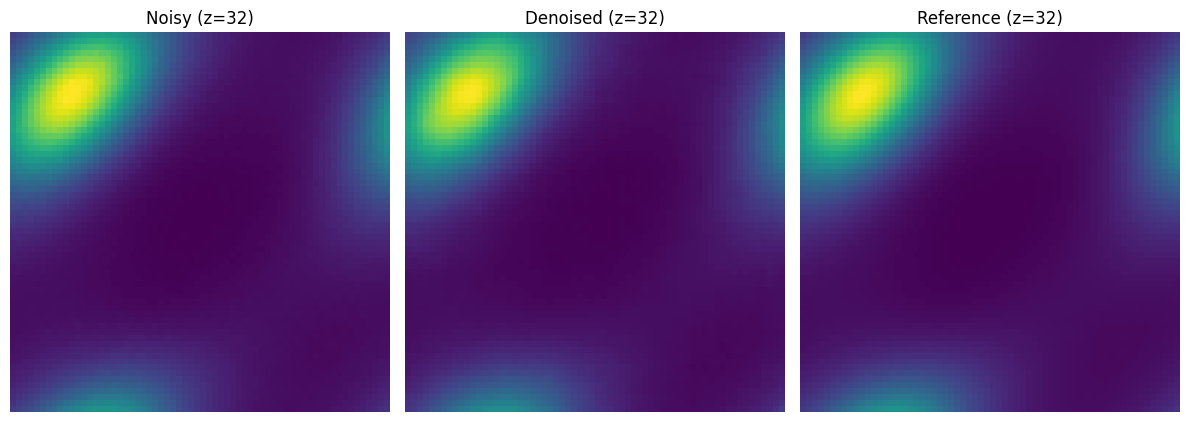

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


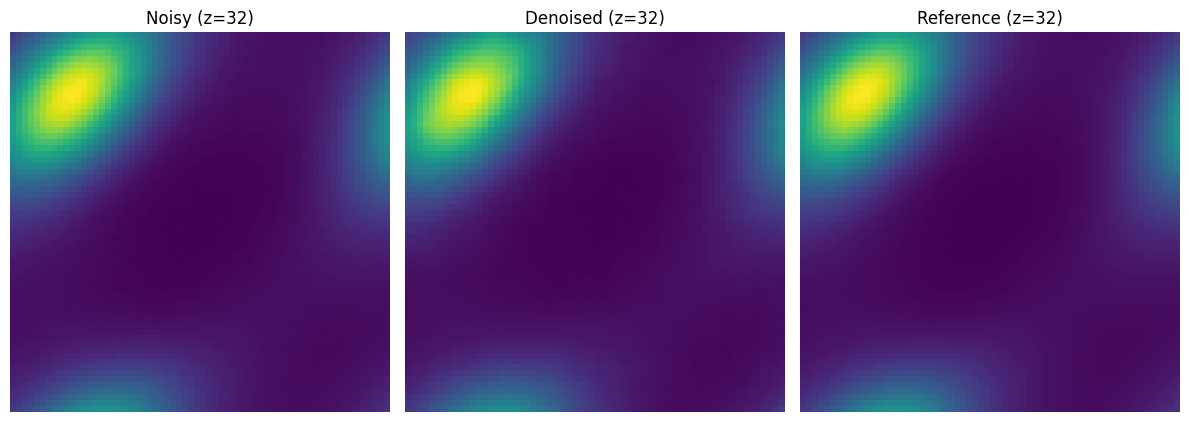

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000235
(64, 64, 64) (64, 64, 64) (64, 64, 64)


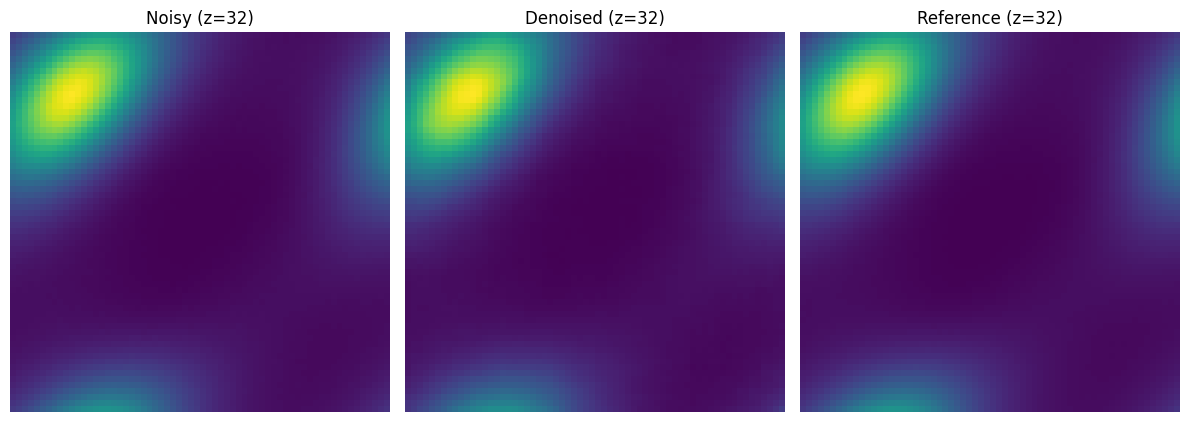

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


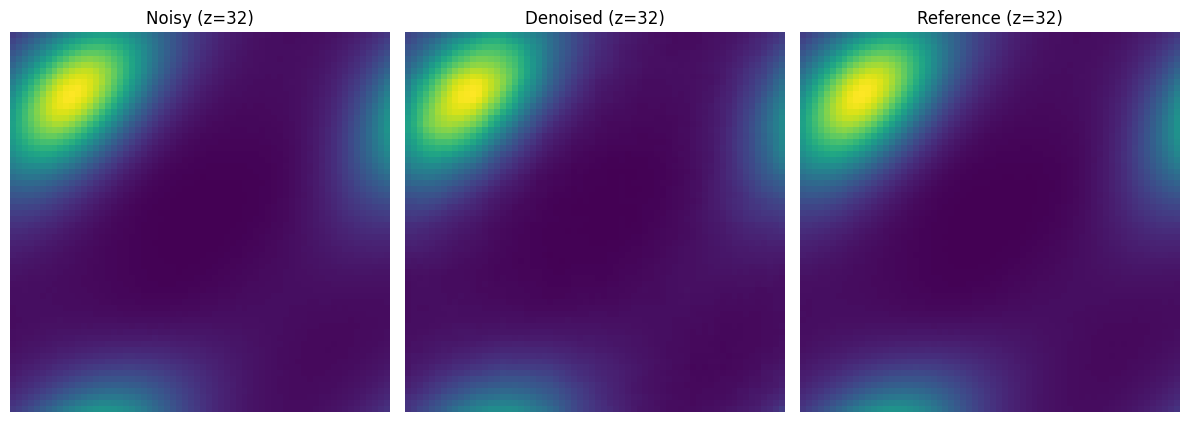

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000234
(64, 64, 64) (64, 64, 64) (64, 64, 64)


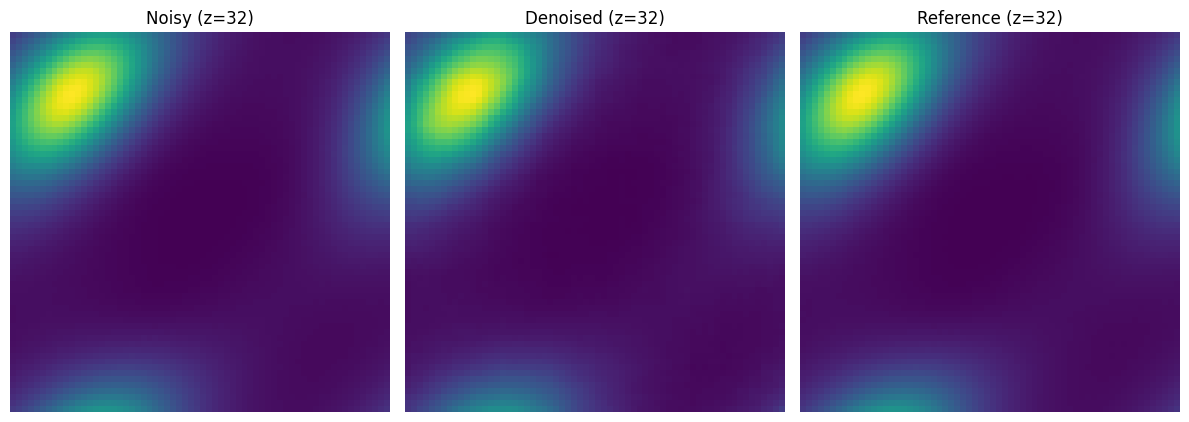


=== Running model: 240700000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.000182
(64, 64, 64) (64, 64, 64) (64, 64, 64)


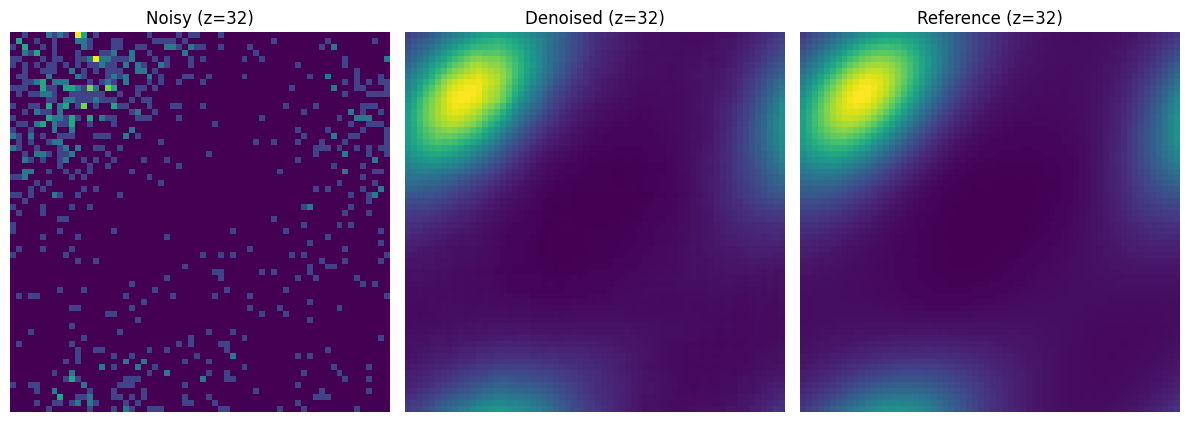

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.000175
(64, 64, 64) (64, 64, 64) (64, 64, 64)


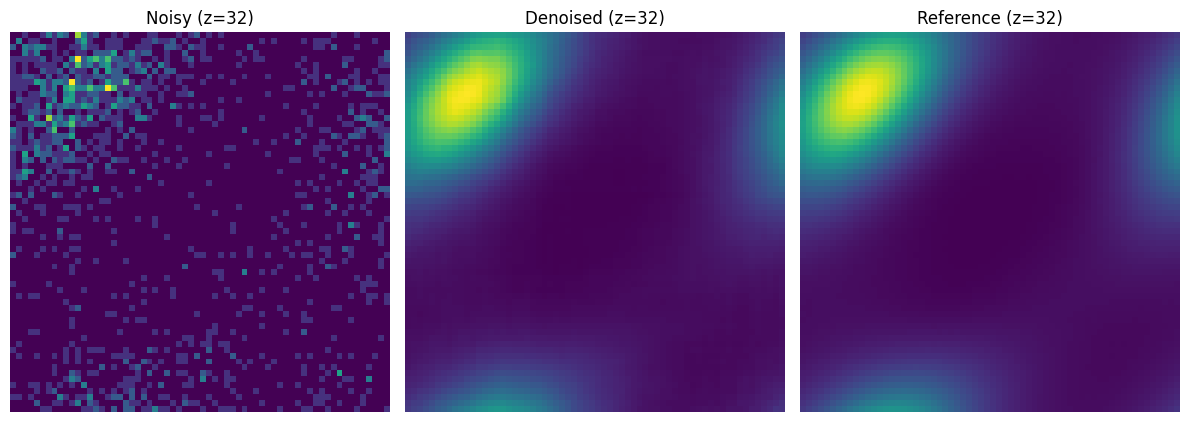

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.000171
(64, 64, 64) (64, 64, 64) (64, 64, 64)


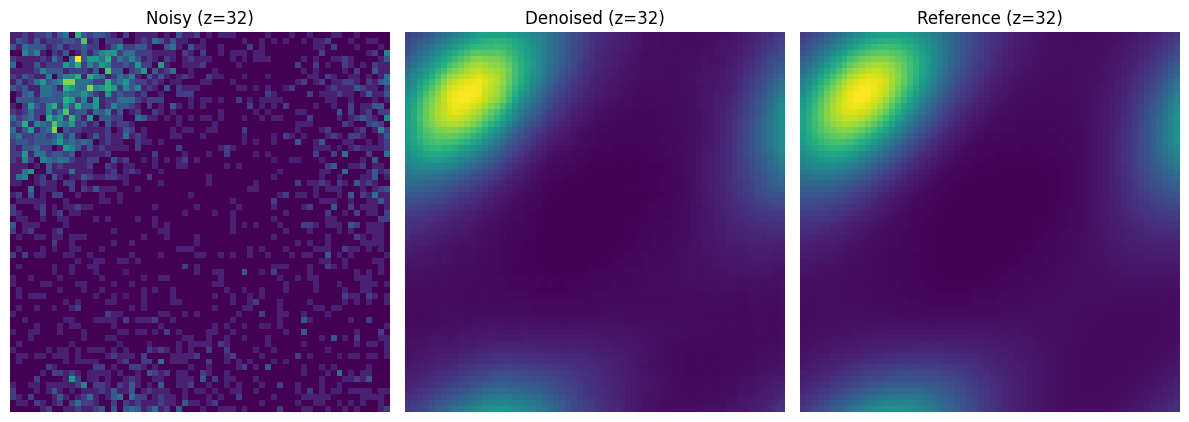

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.000169
(64, 64, 64) (64, 64, 64) (64, 64, 64)


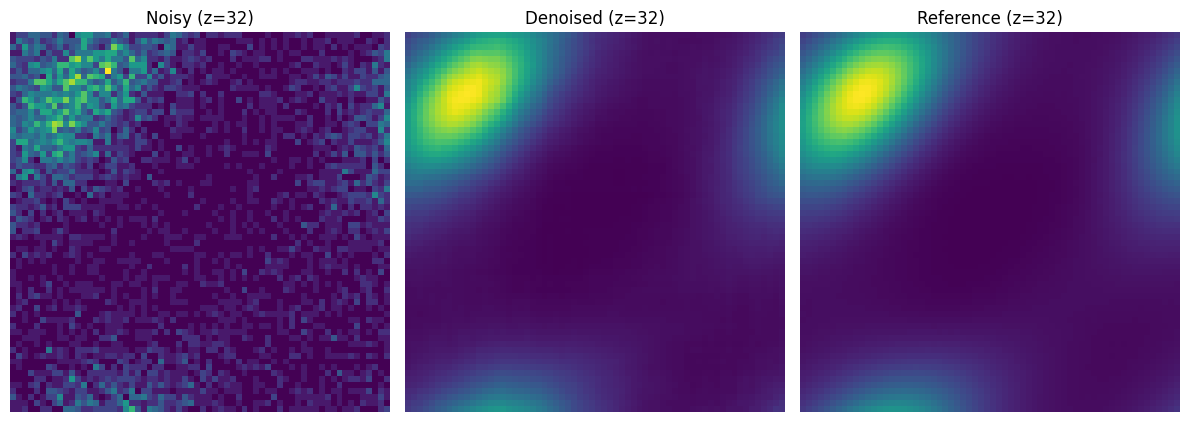

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.000168
(64, 64, 64) (64, 64, 64) (64, 64, 64)


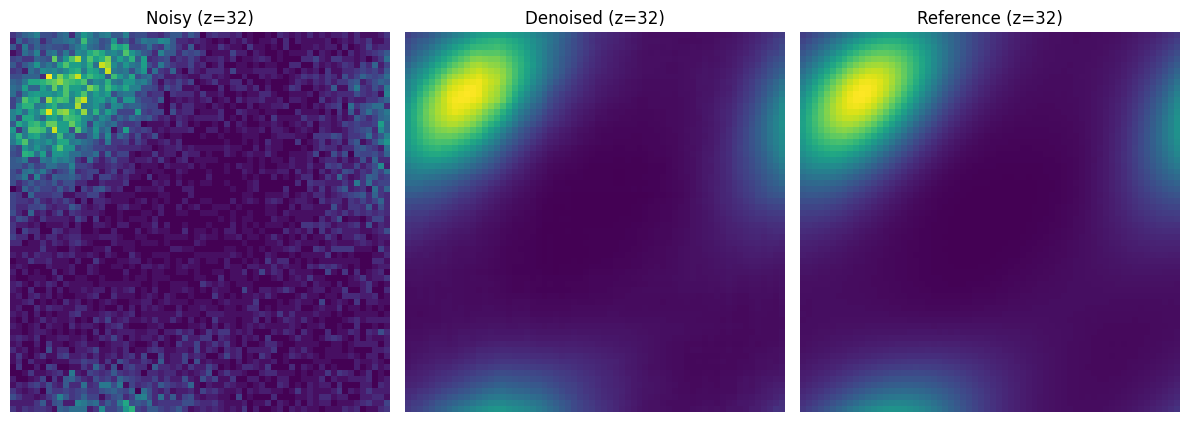

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


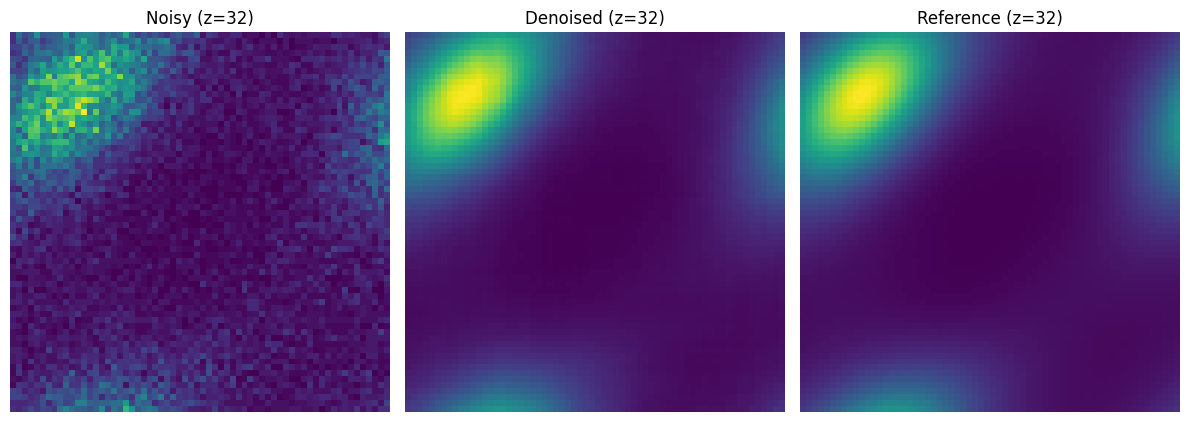

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.000167
(64, 64, 64) (64, 64, 64) (64, 64, 64)


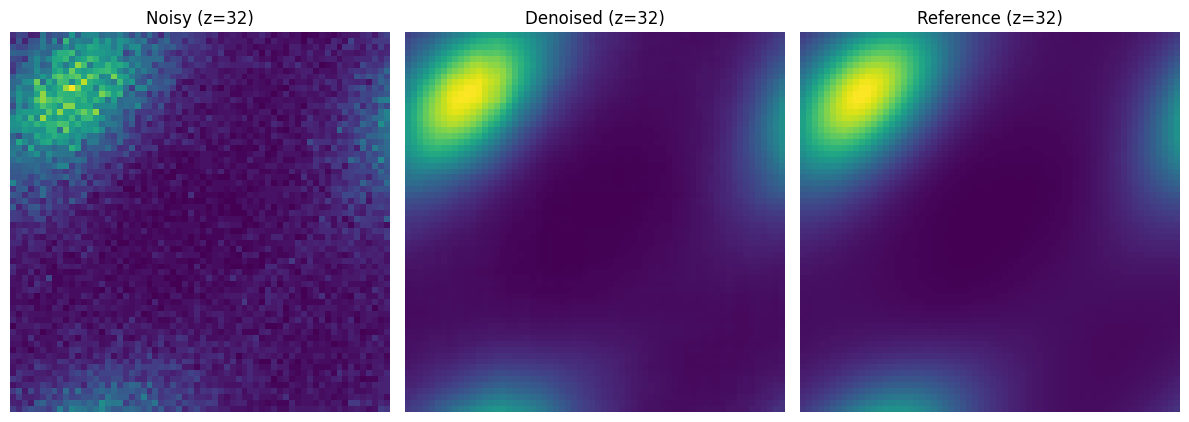

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


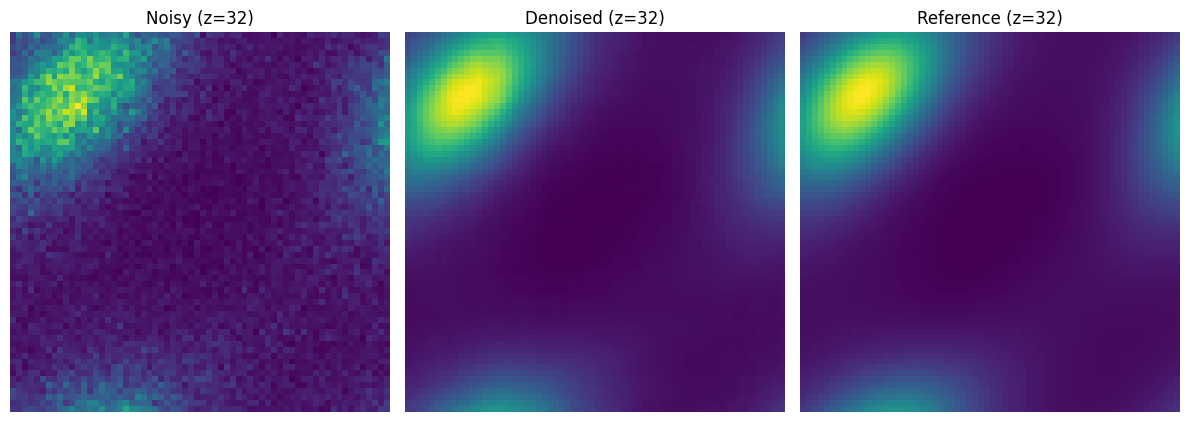

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


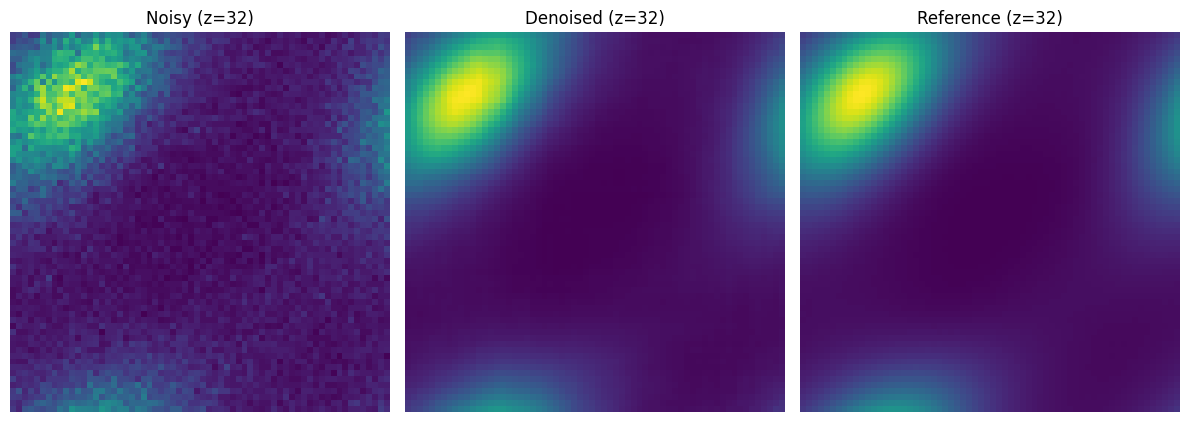

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


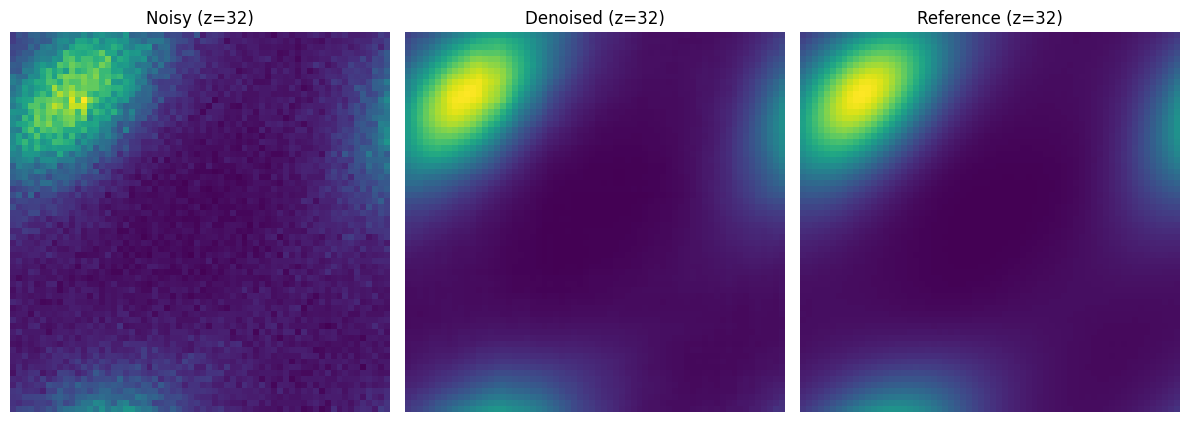

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


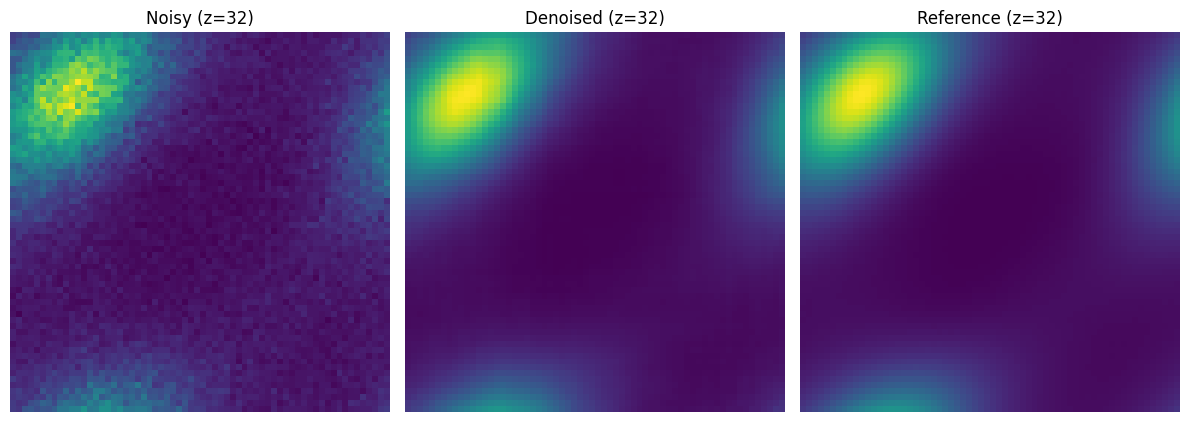

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


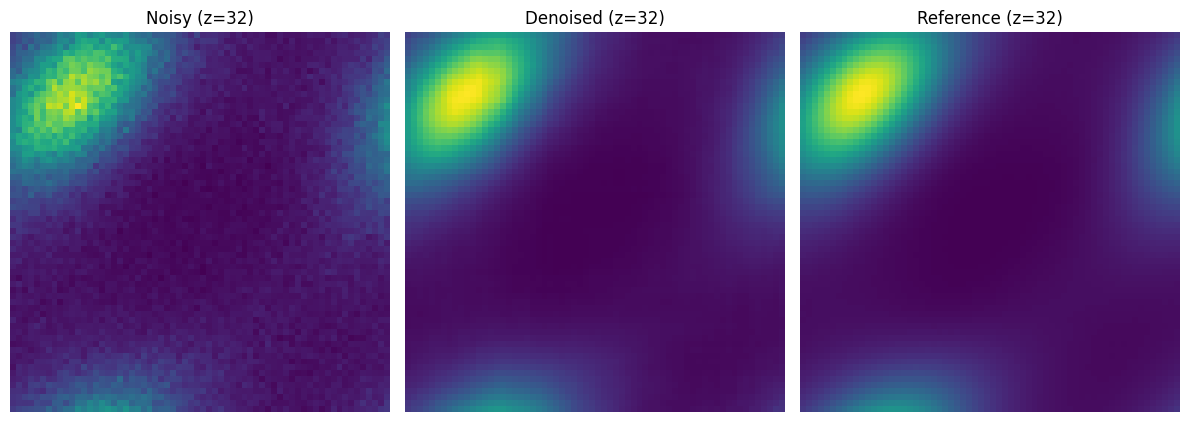

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


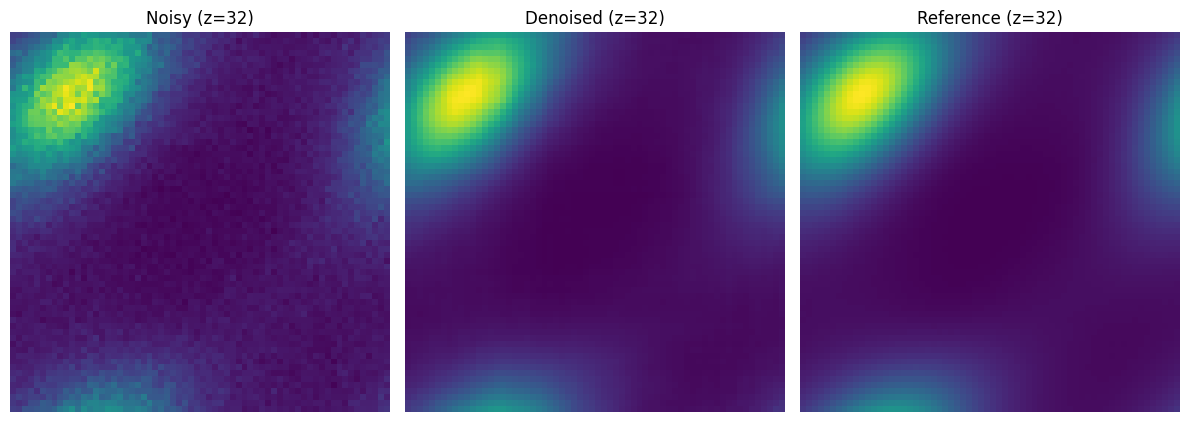

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


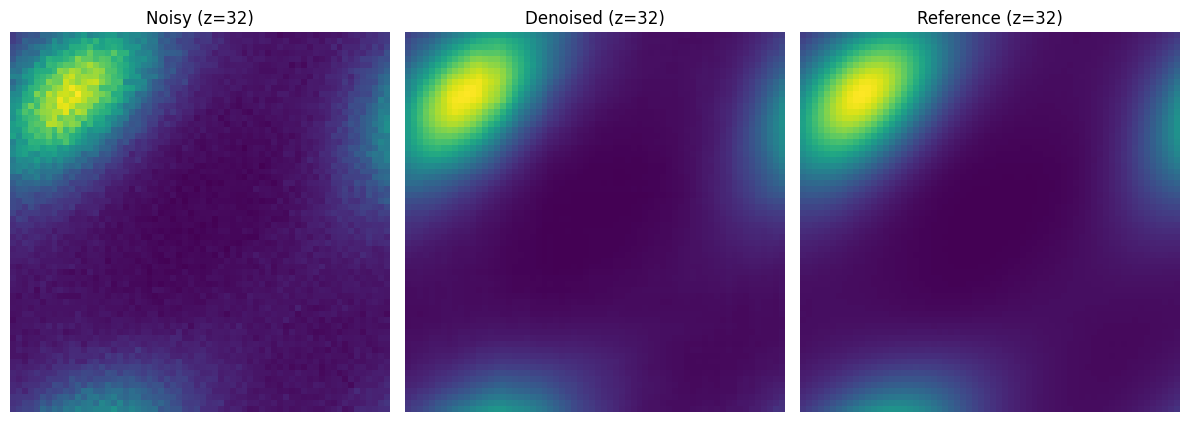

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


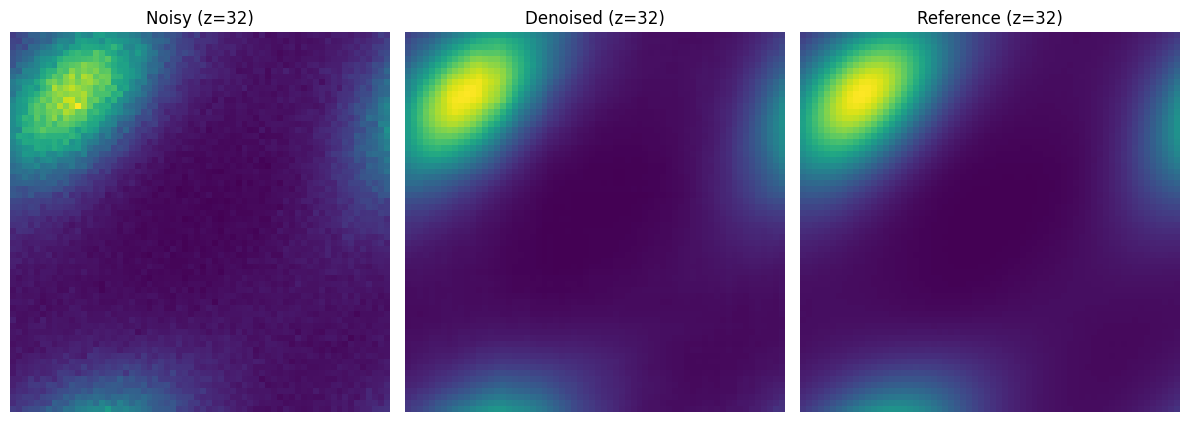

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


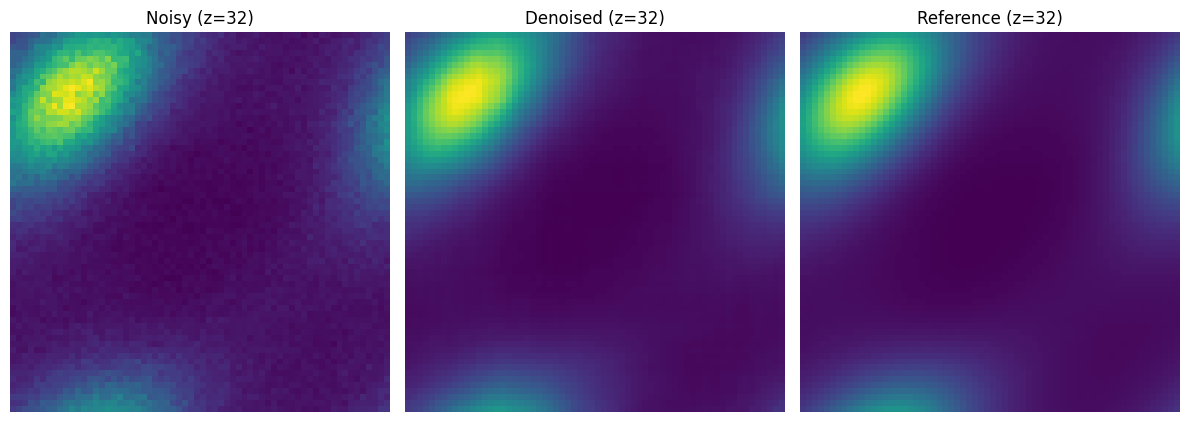

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


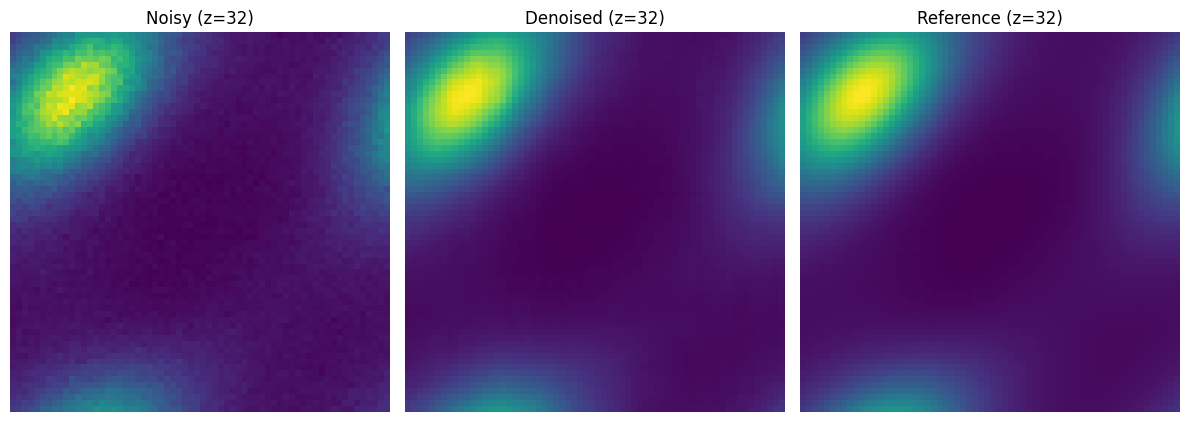

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


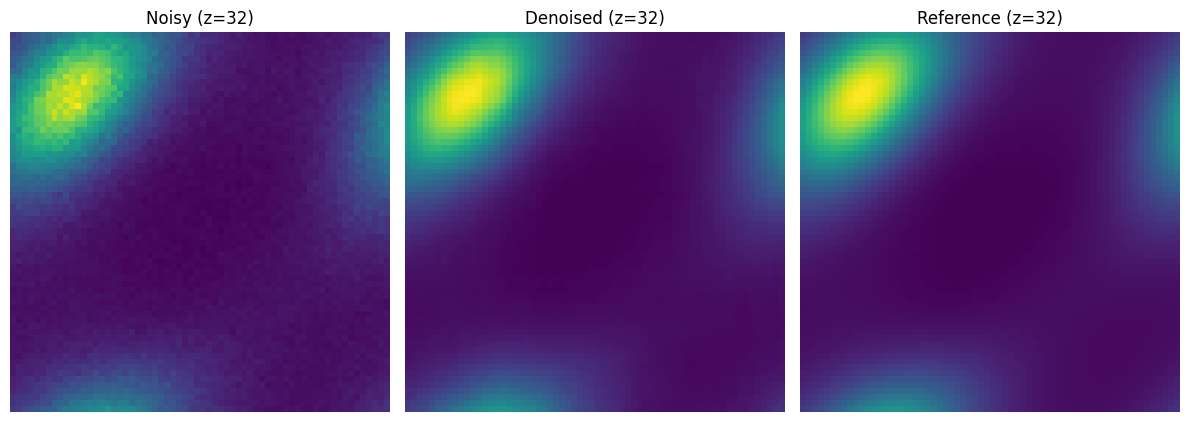

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


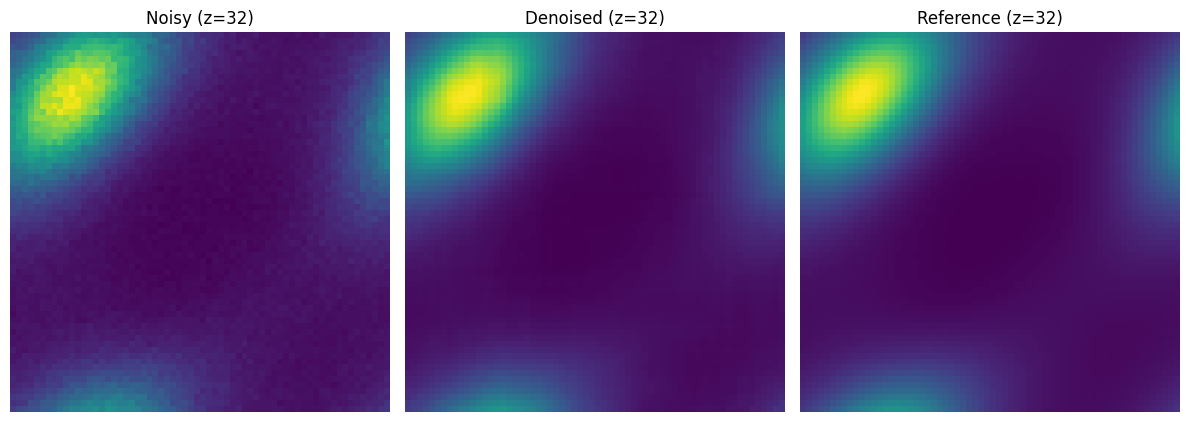

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


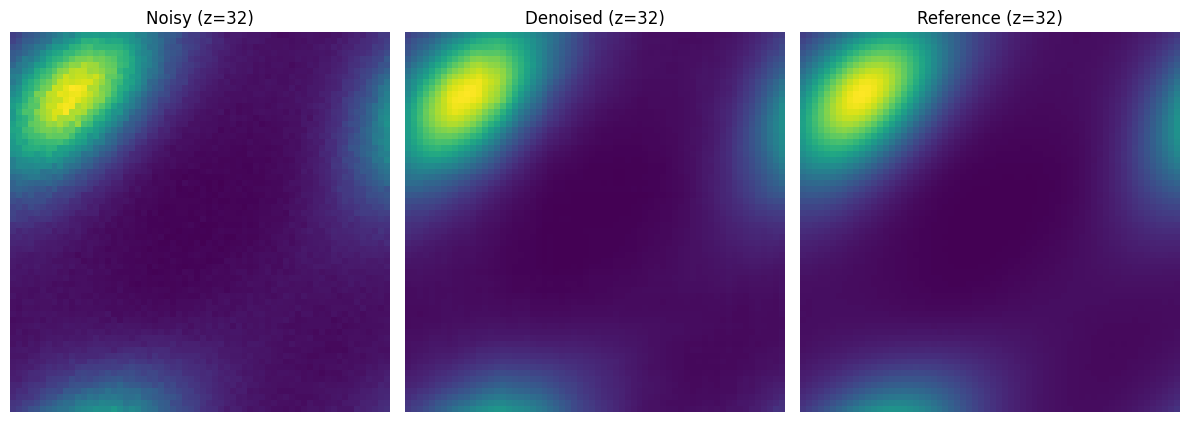

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


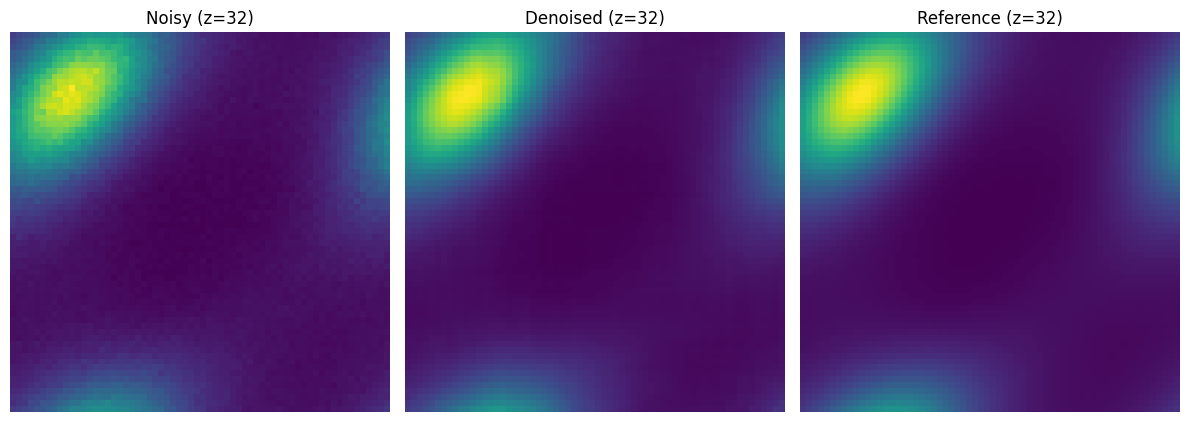

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


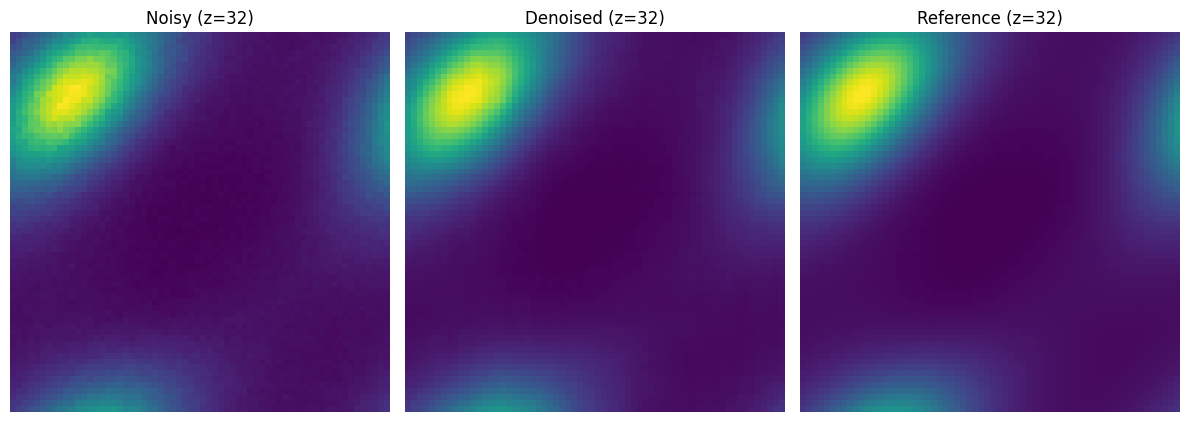

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


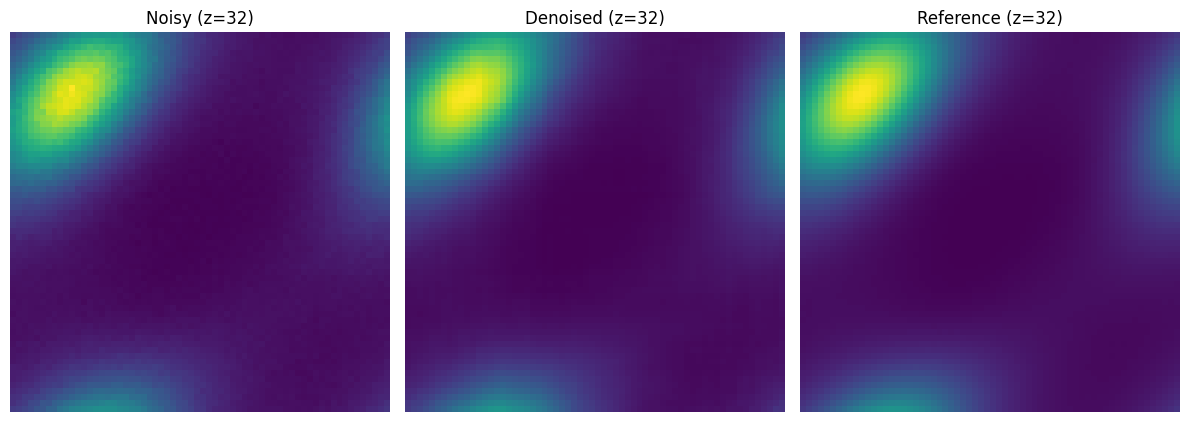

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


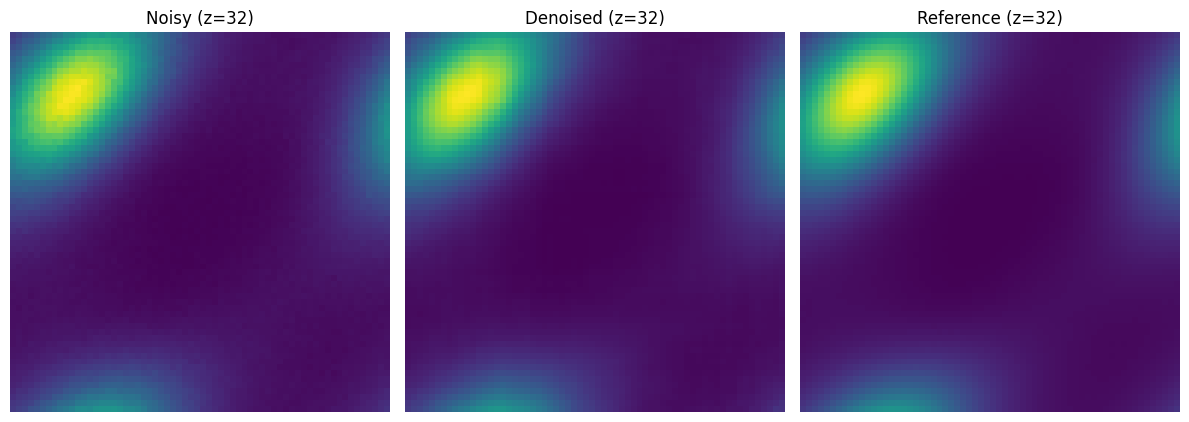

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


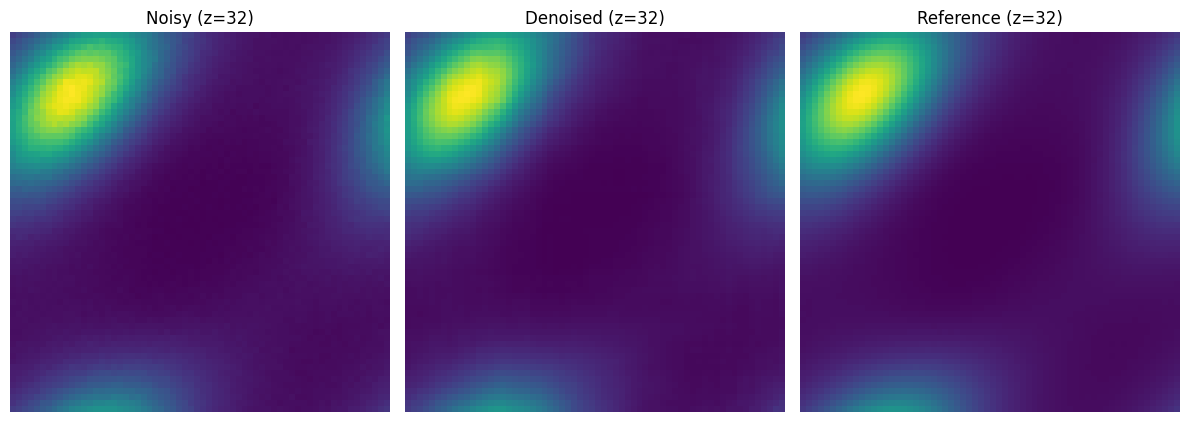

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000164
(64, 64, 64) (64, 64, 64) (64, 64, 64)


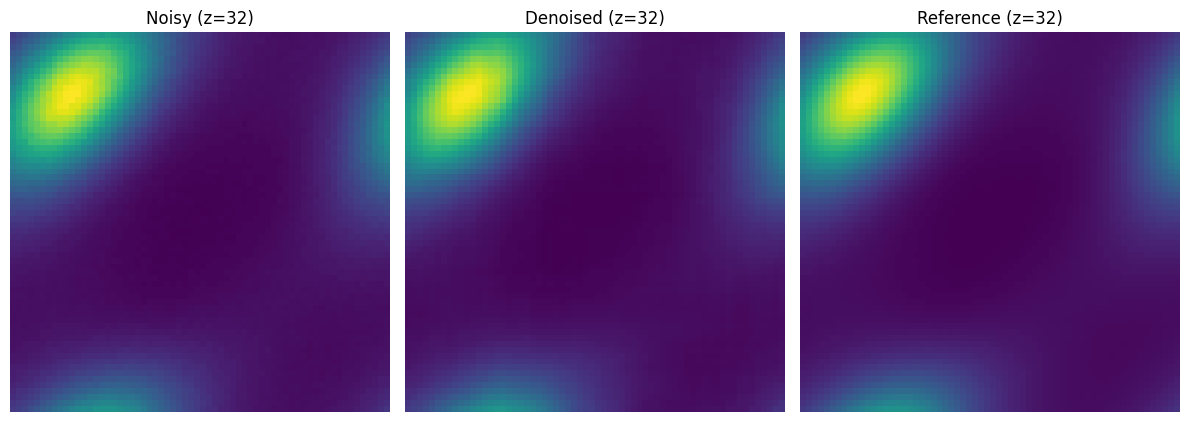

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000164
(64, 64, 64) (64, 64, 64) (64, 64, 64)


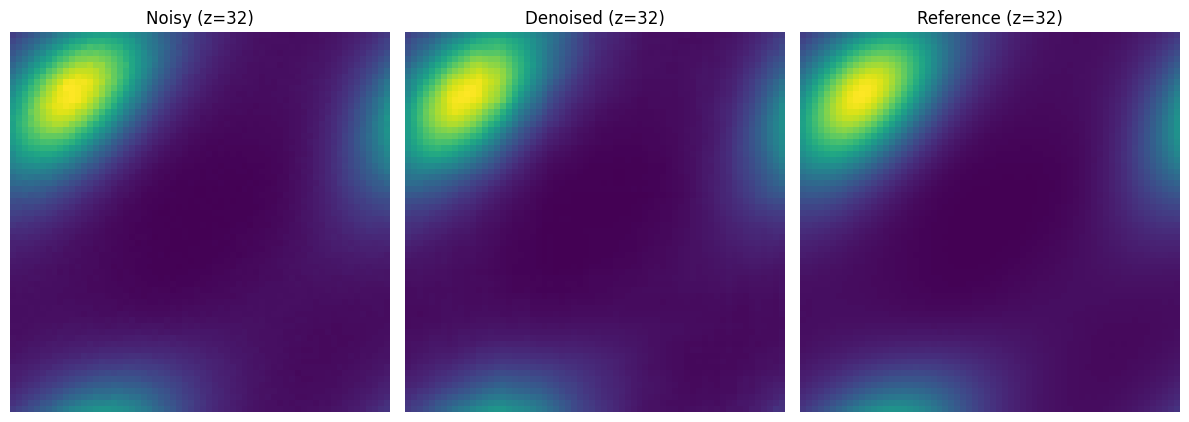

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


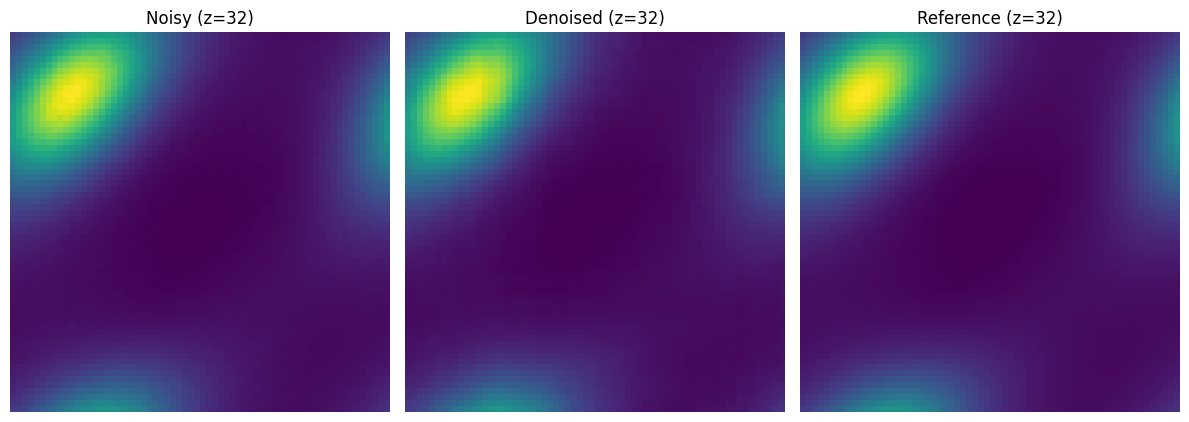

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000164
(64, 64, 64) (64, 64, 64) (64, 64, 64)


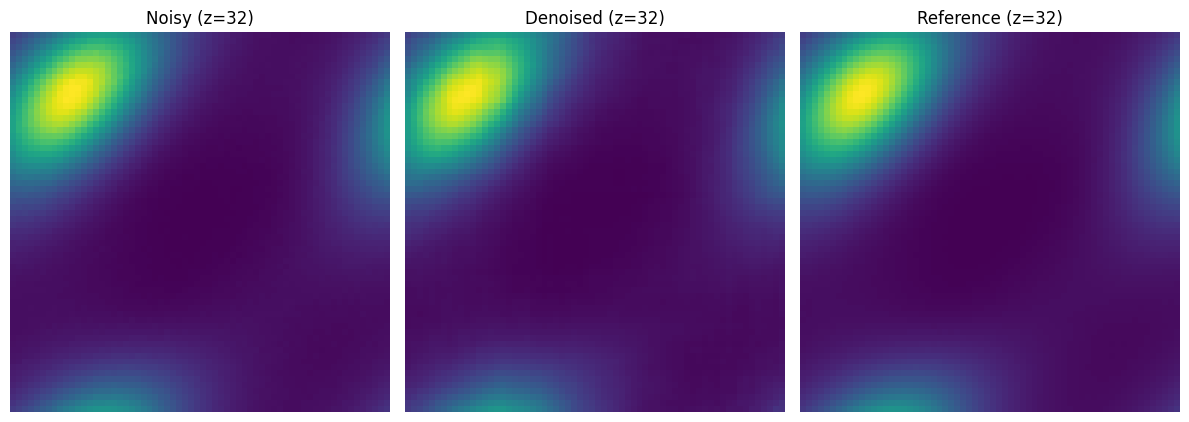

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


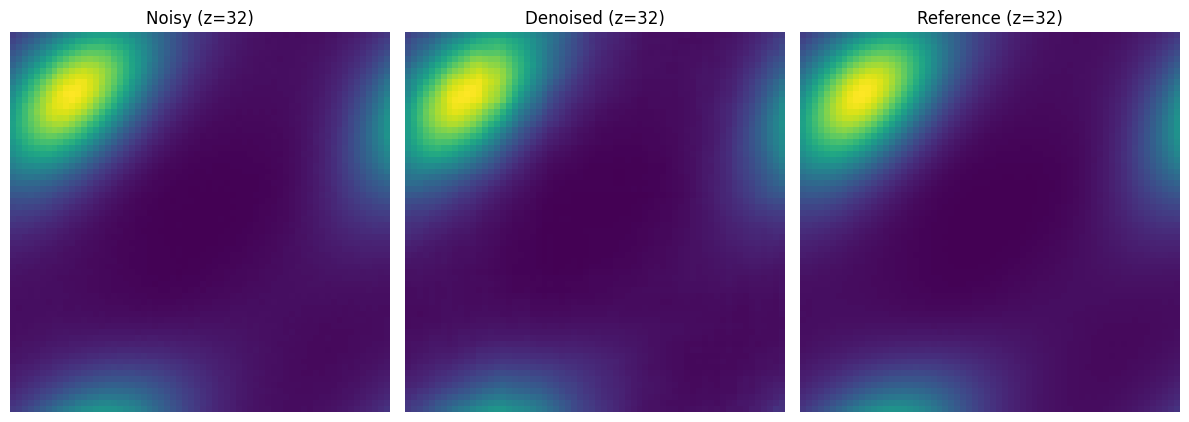

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


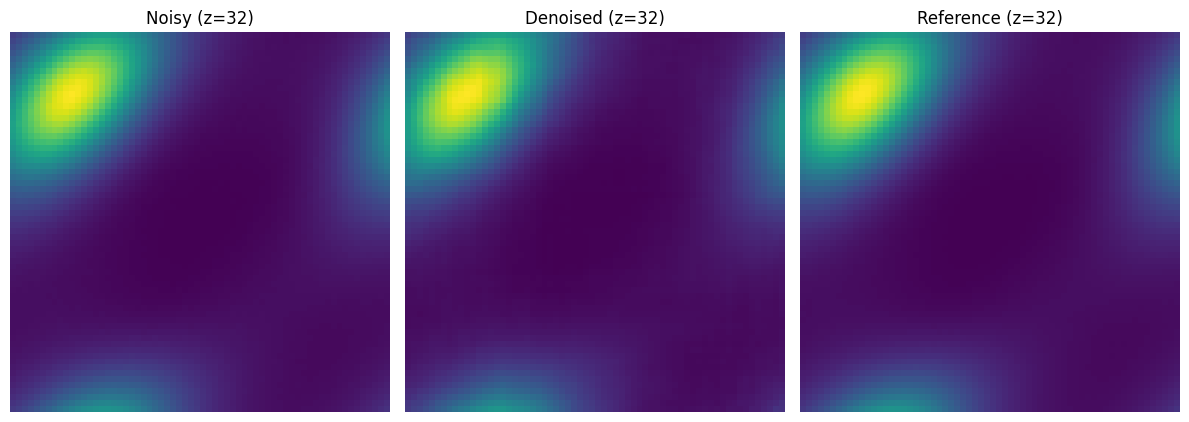

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


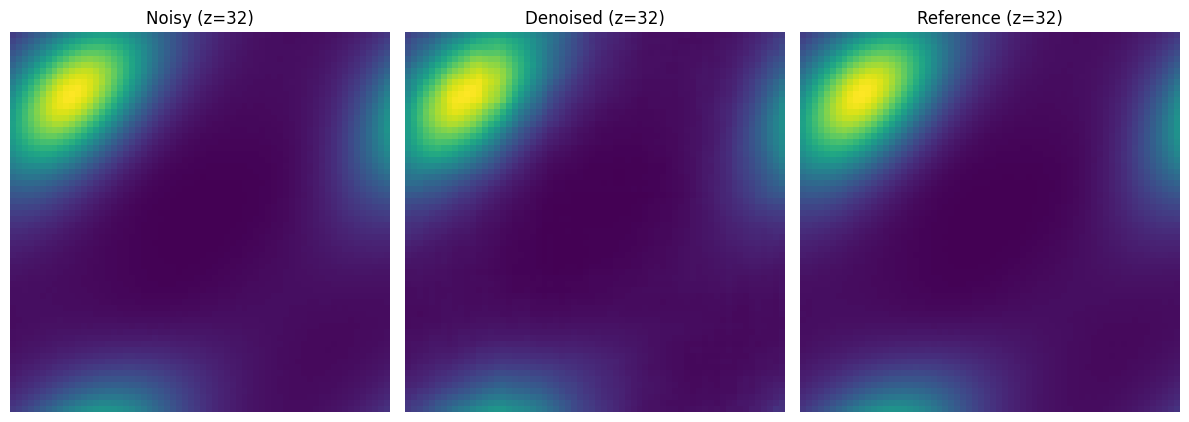

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000165
(64, 64, 64) (64, 64, 64) (64, 64, 64)


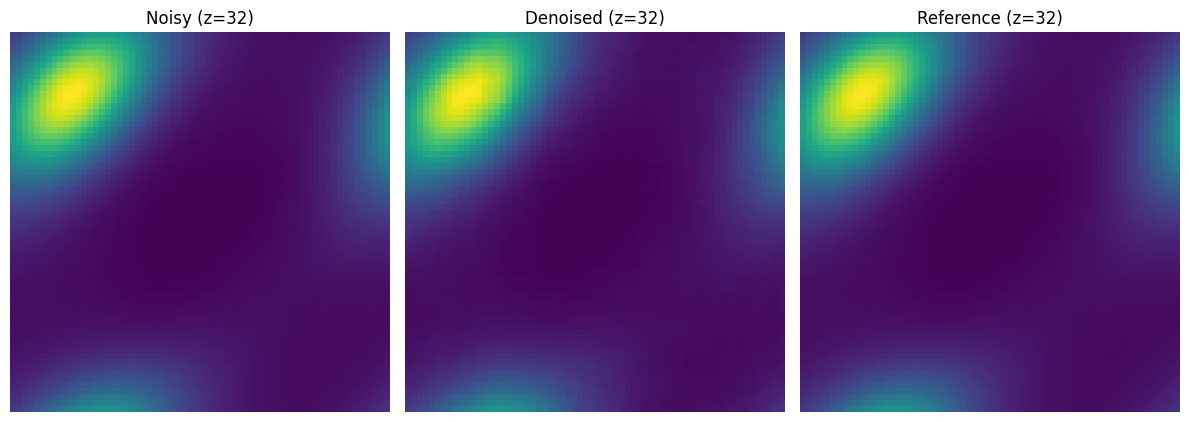


=== Running model: 24080000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.328315
JSD   (denoised vs ref):  0.000166
(64, 64, 64) (64, 64, 64) (64, 64, 64)


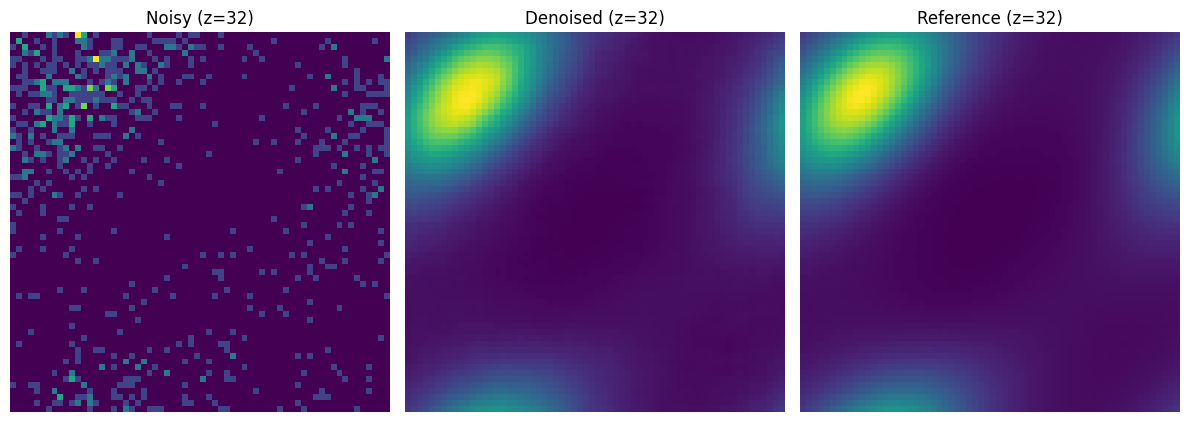

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.221927
JSD   (denoised vs ref):  0.000164
(64, 64, 64) (64, 64, 64) (64, 64, 64)


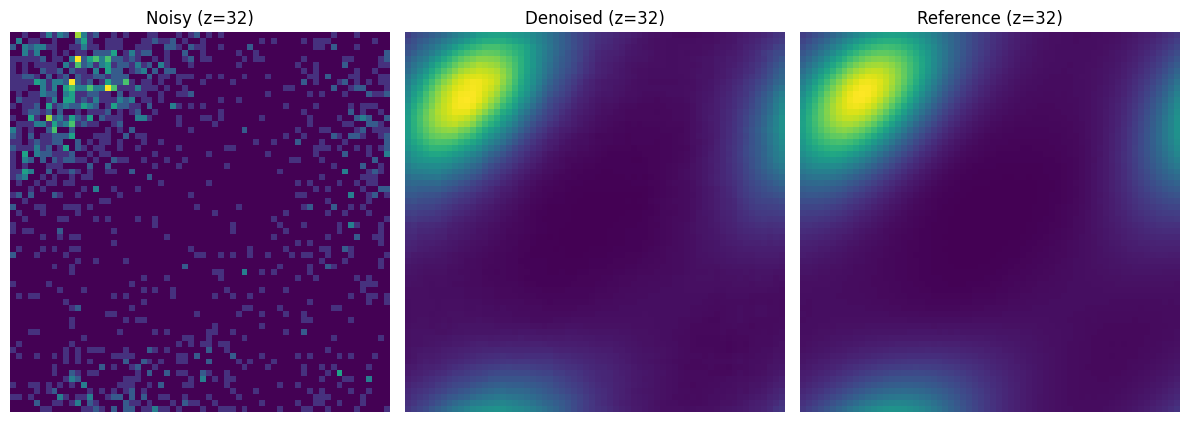

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0146
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133282
JSD   (denoised vs ref):  0.000162
(64, 64, 64) (64, 64, 64) (64, 64, 64)


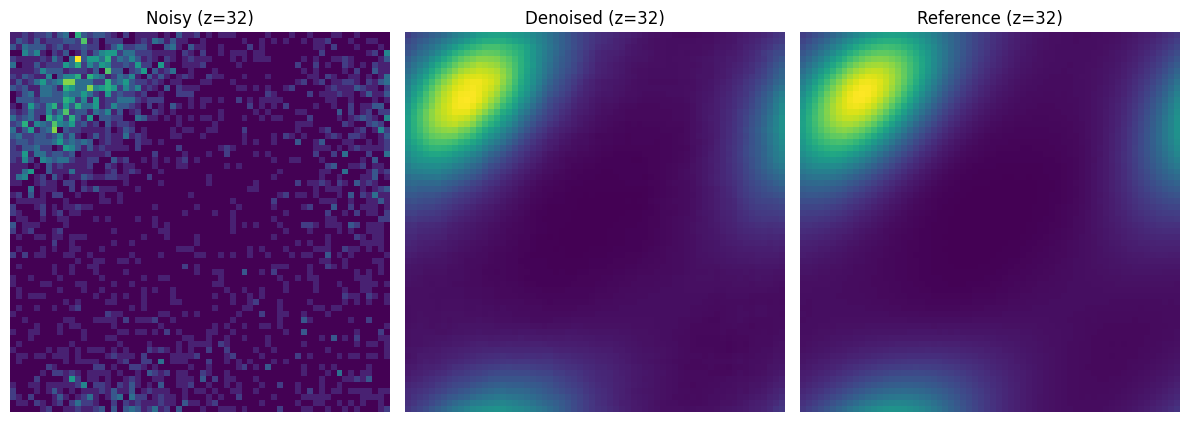

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.073259
JSD   (denoised vs ref):  0.000161
(64, 64, 64) (64, 64, 64) (64, 64, 64)


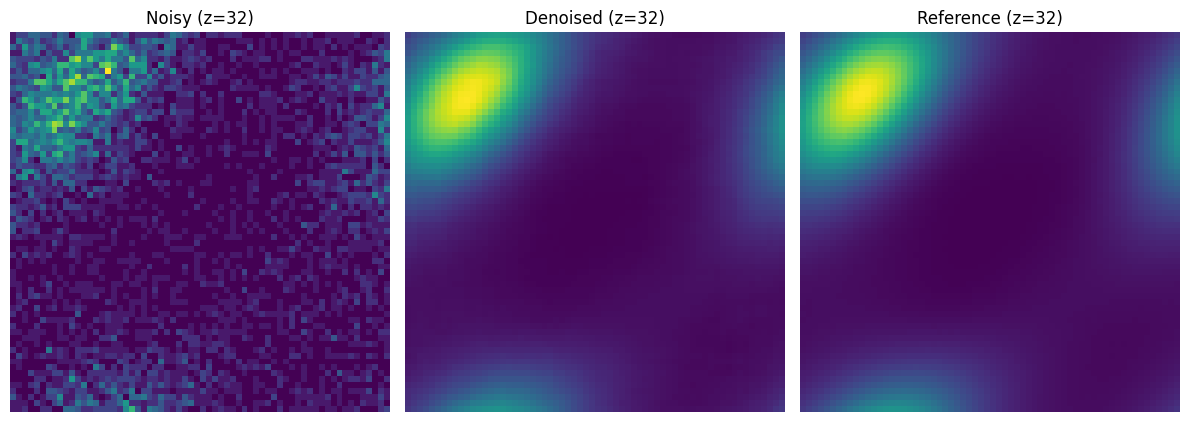

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.036841
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


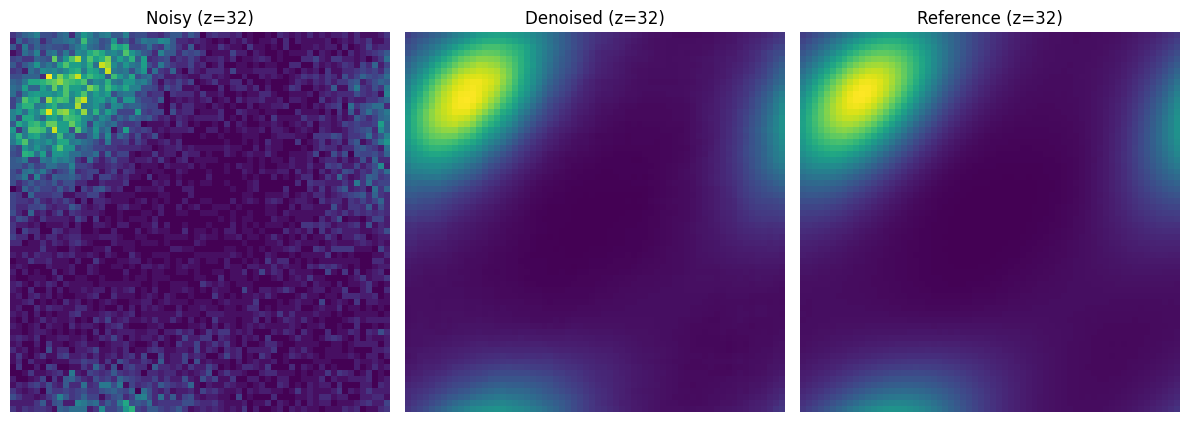

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.017439
JSD   (denoised vs ref):  0.000160
(64, 64, 64) (64, 64, 64) (64, 64, 64)


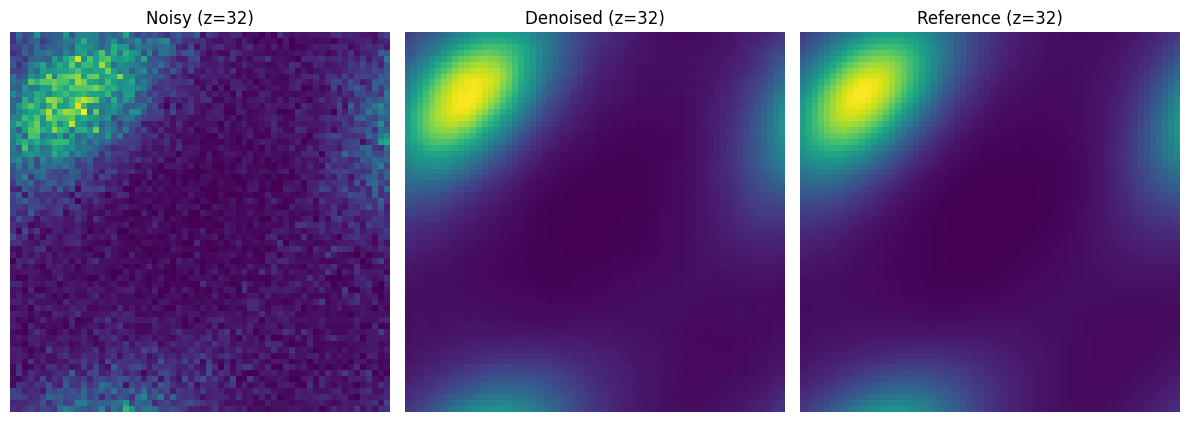

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.012953
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


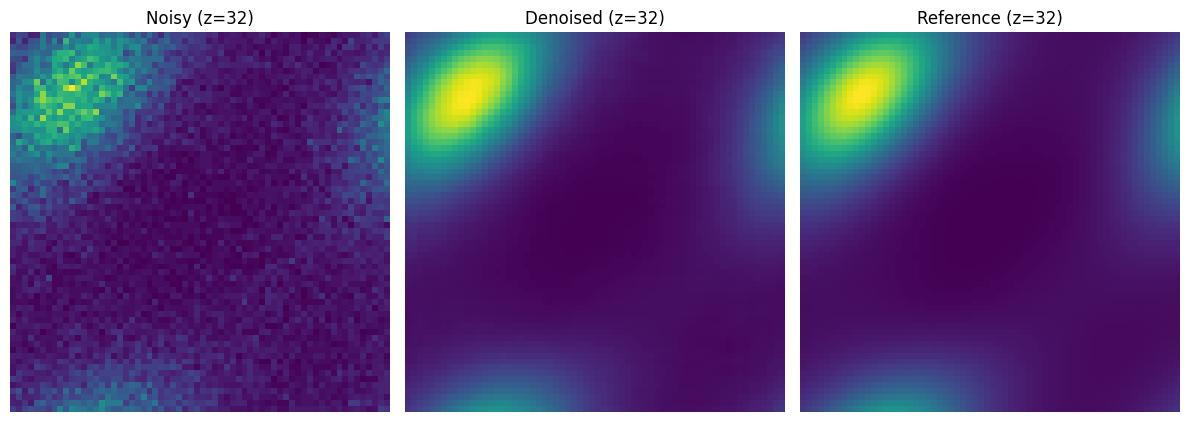

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008132
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


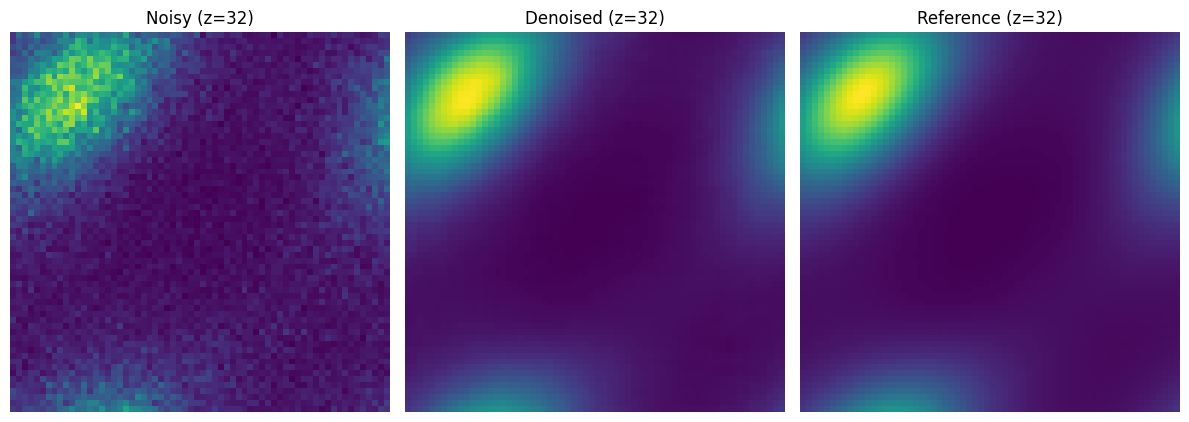

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006071
JSD   (denoised vs ref):  0.000160
(64, 64, 64) (64, 64, 64) (64, 64, 64)


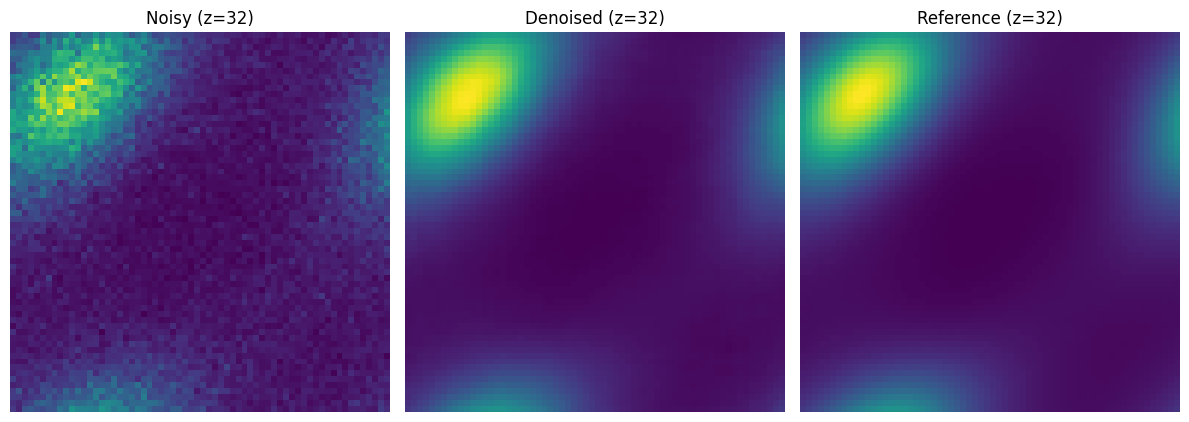

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003930
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


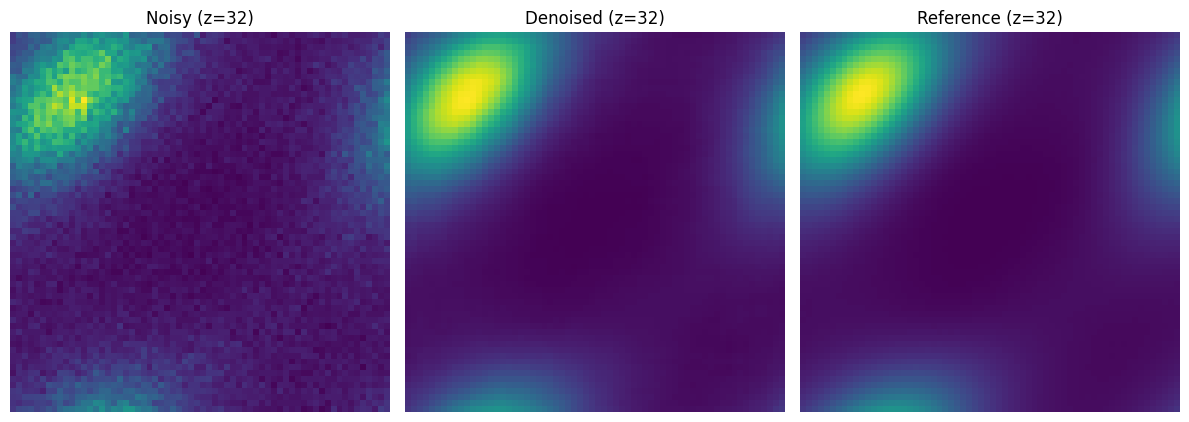

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002943
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


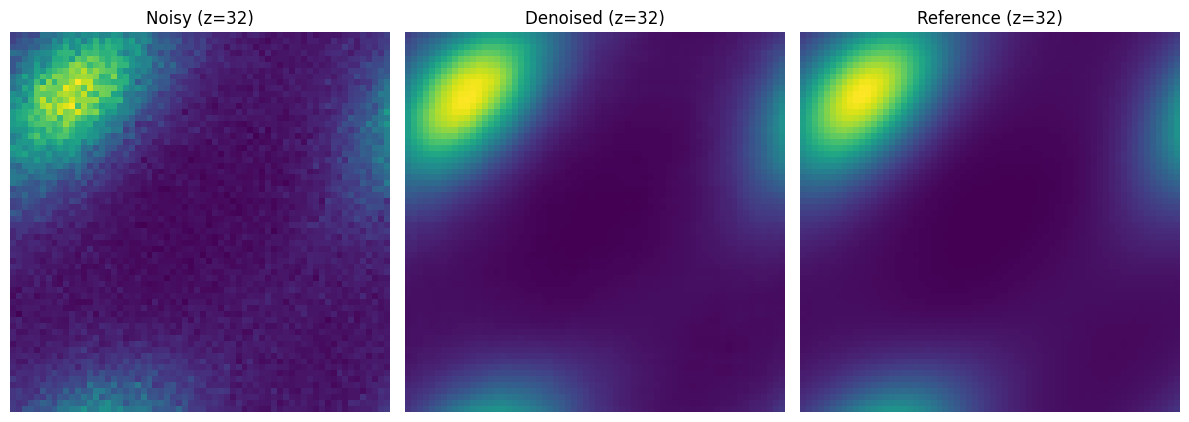

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001931
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


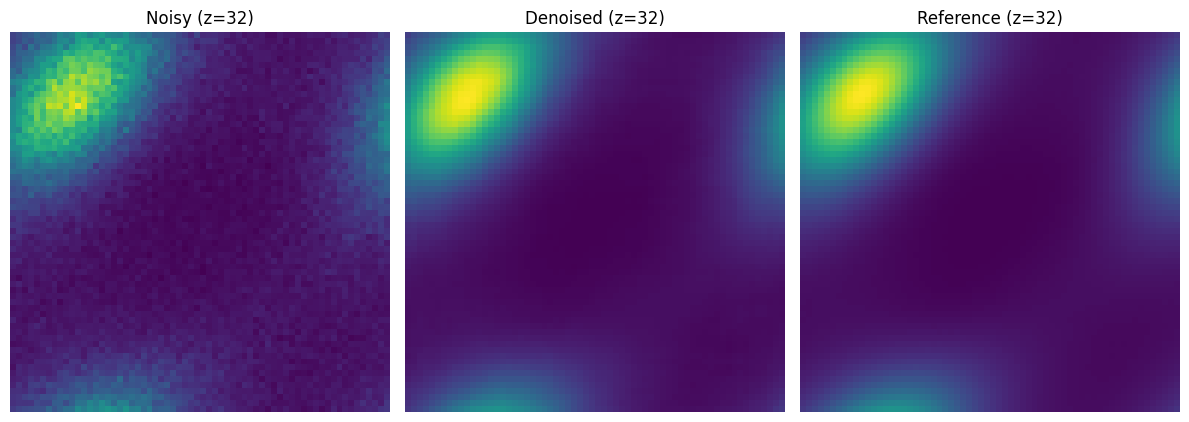

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001459
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


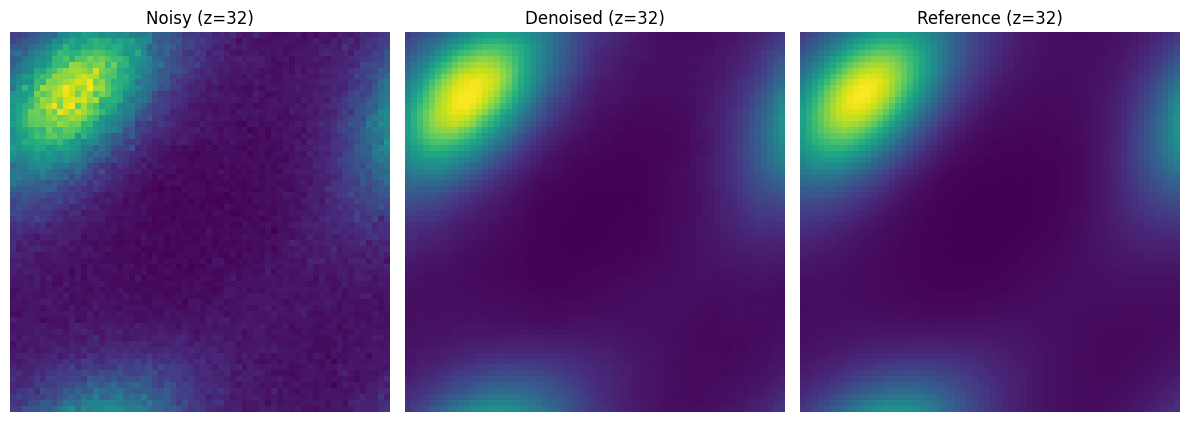

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000975
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


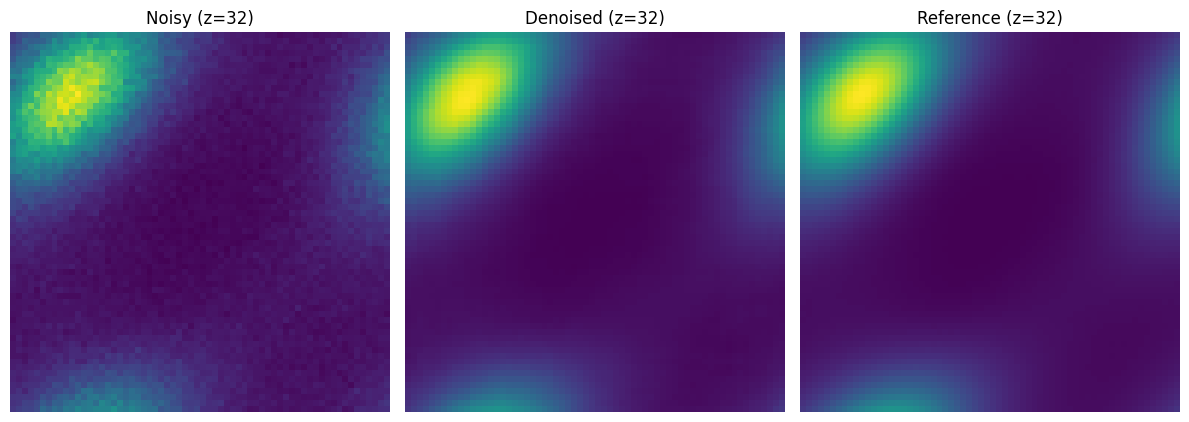

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000960
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


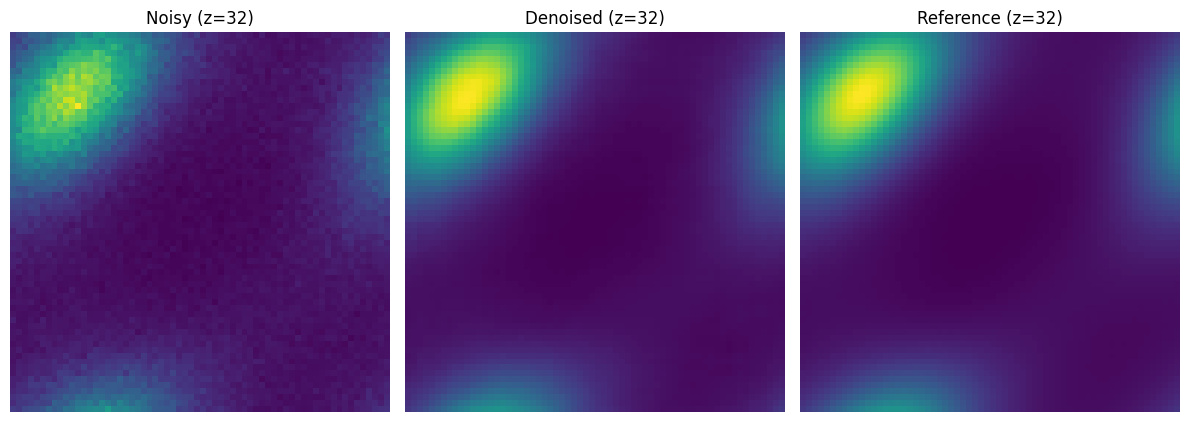

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000731
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


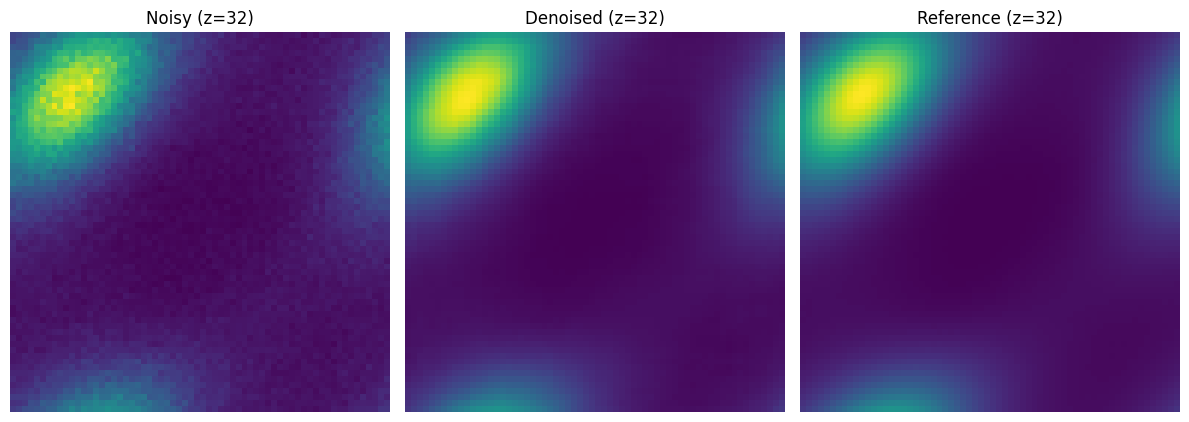

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000486
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


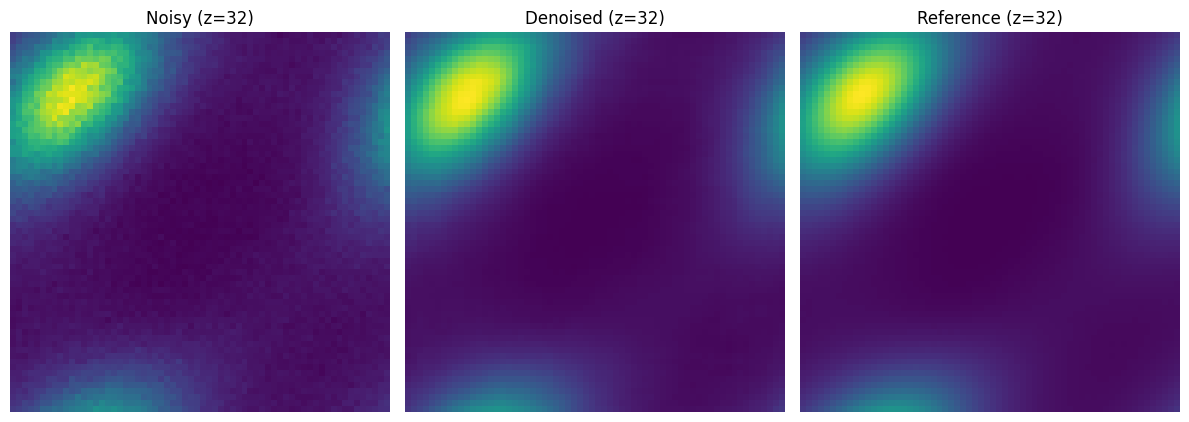

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000480
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


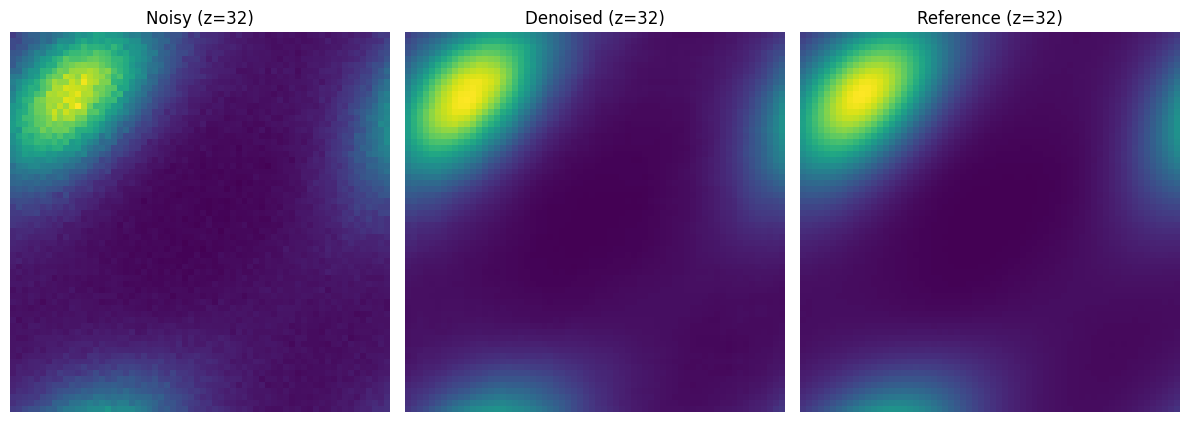

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000365
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


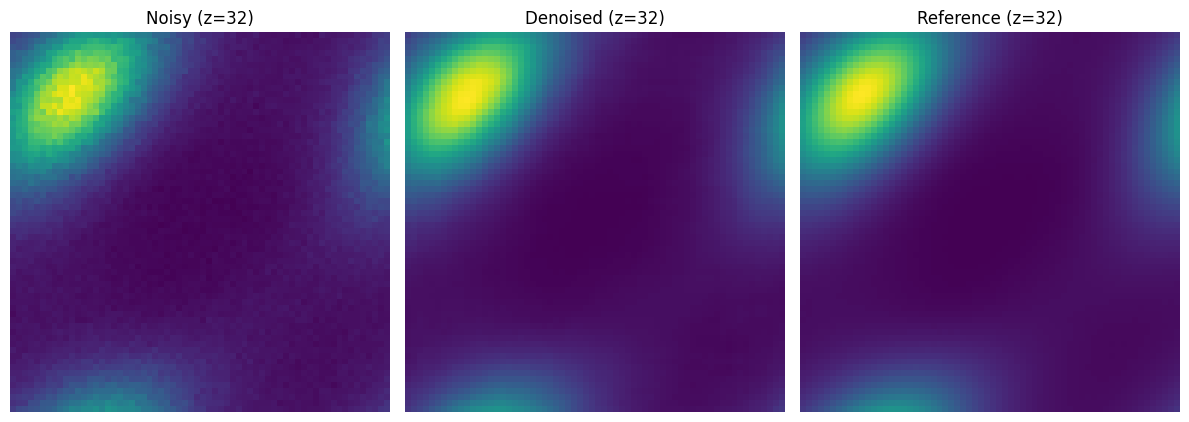

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000243
JSD   (denoised vs ref):  0.000158
(64, 64, 64) (64, 64, 64) (64, 64, 64)


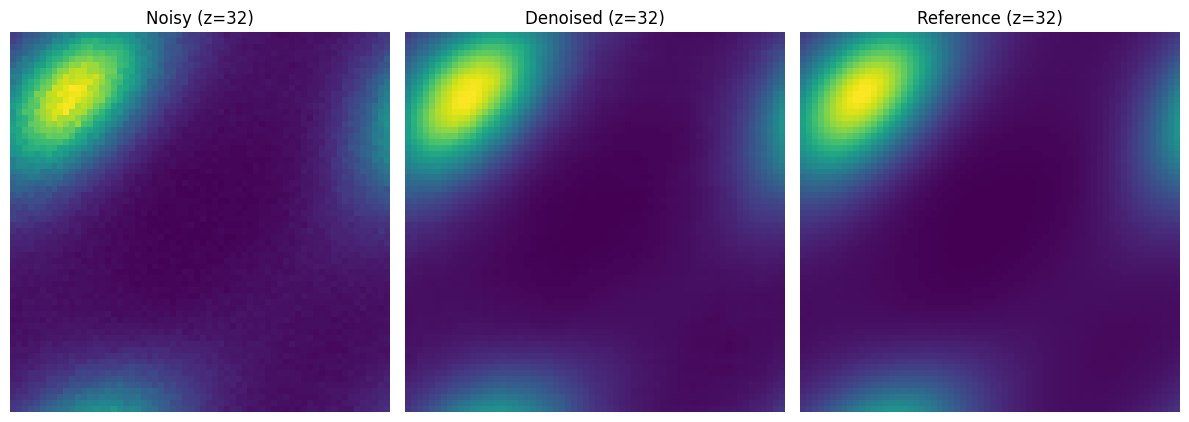

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


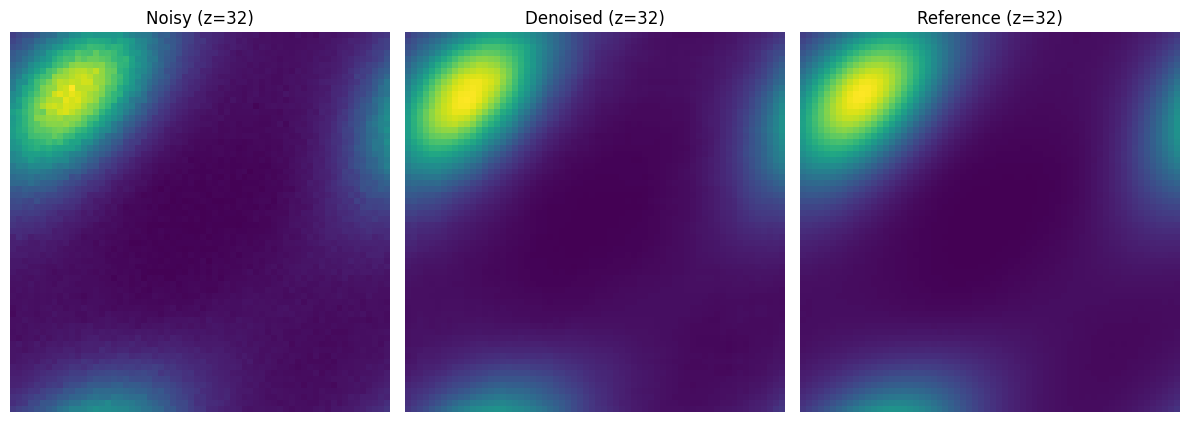

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


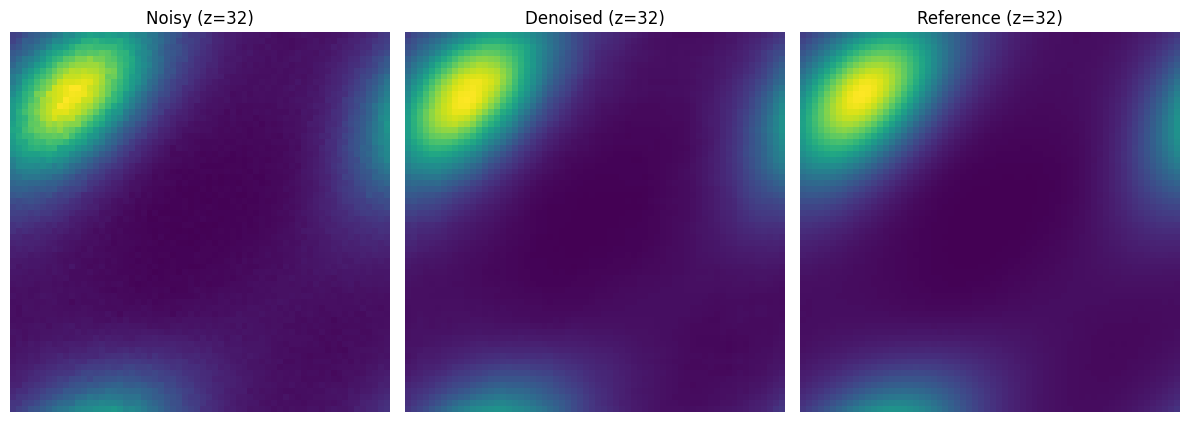

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


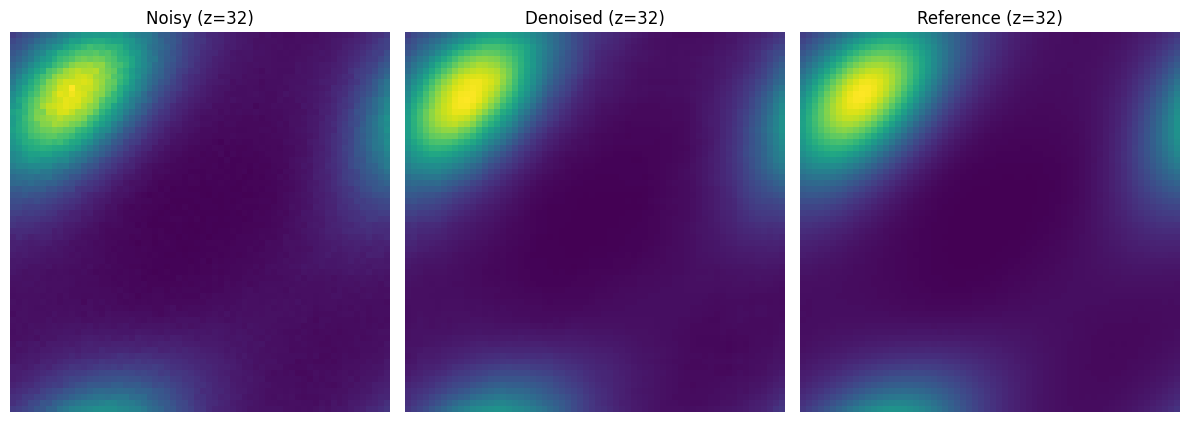

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


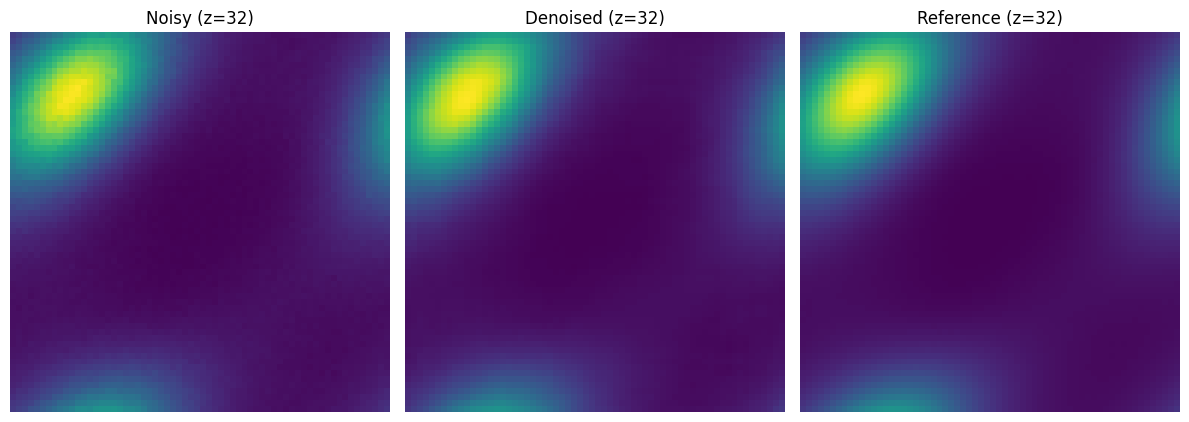

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


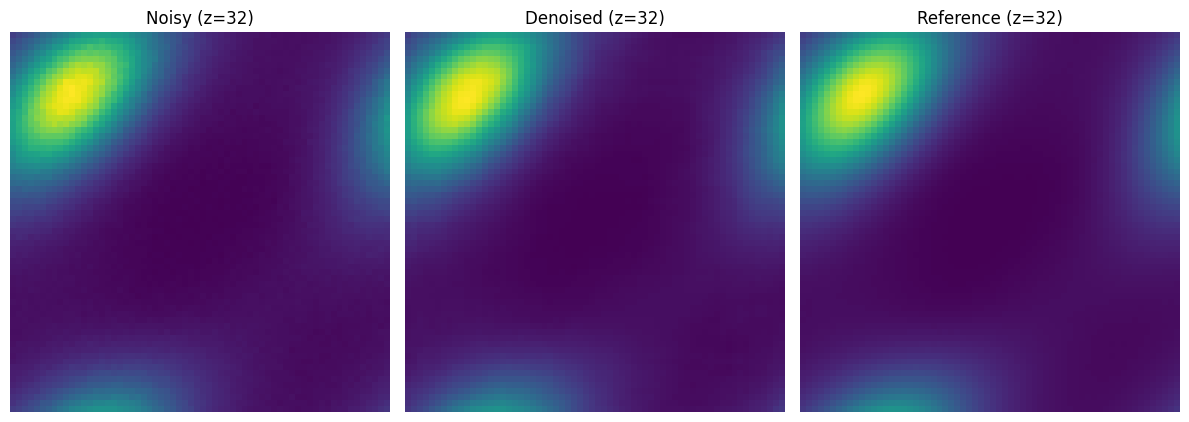

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


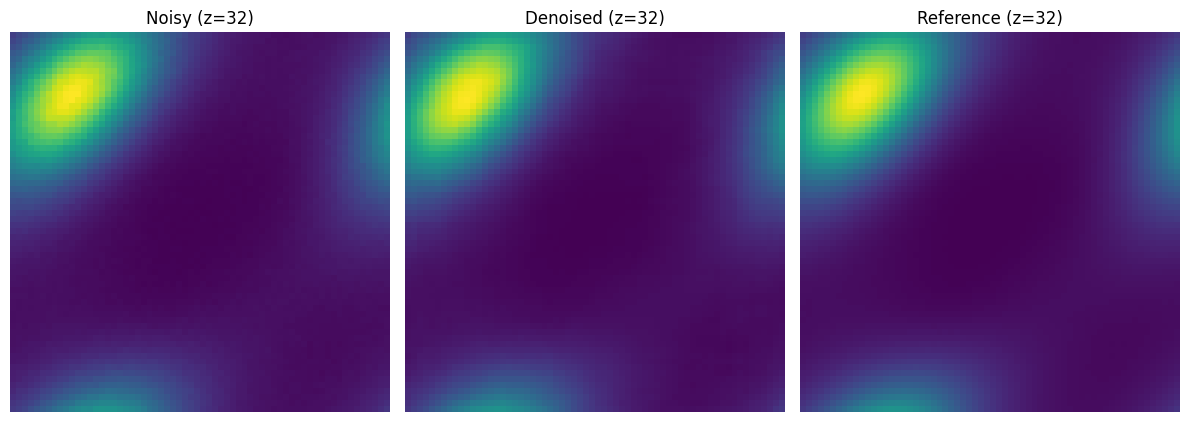

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


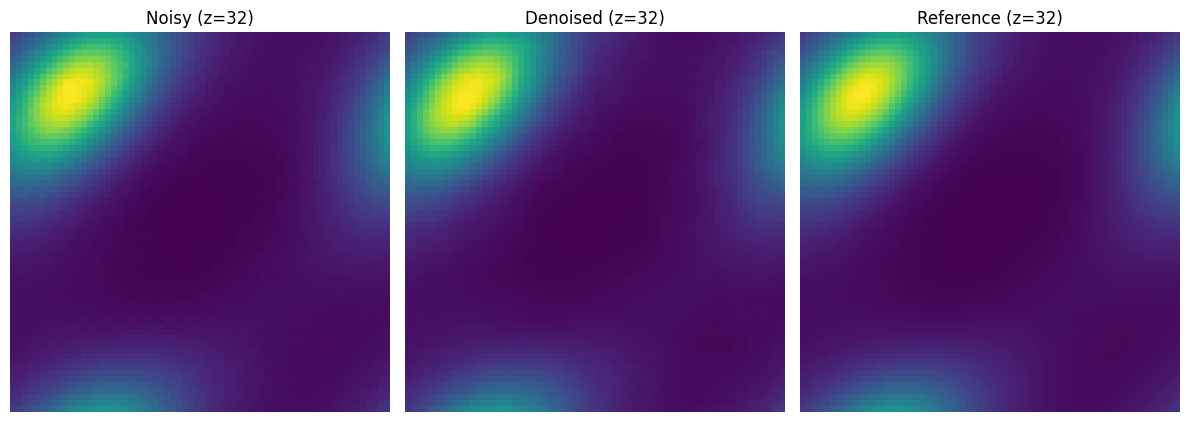

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


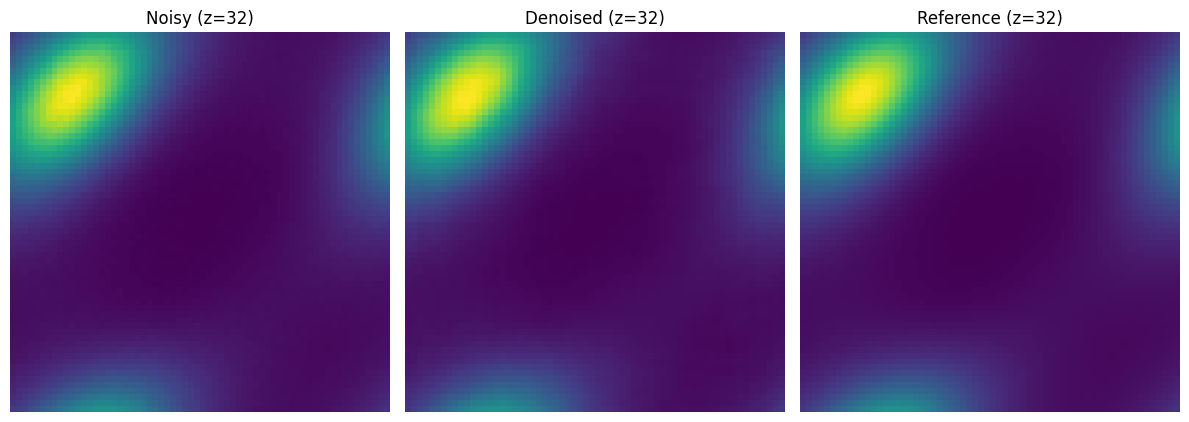

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


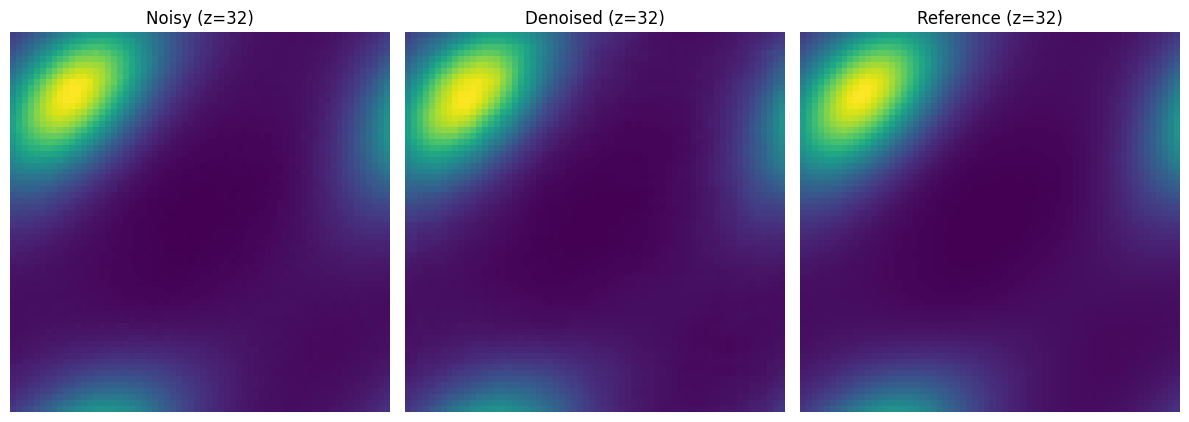

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


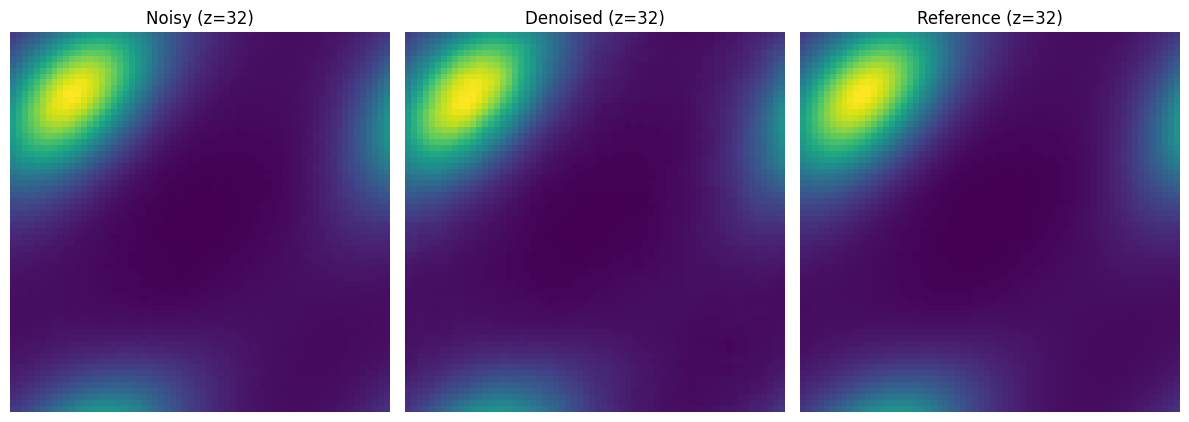

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


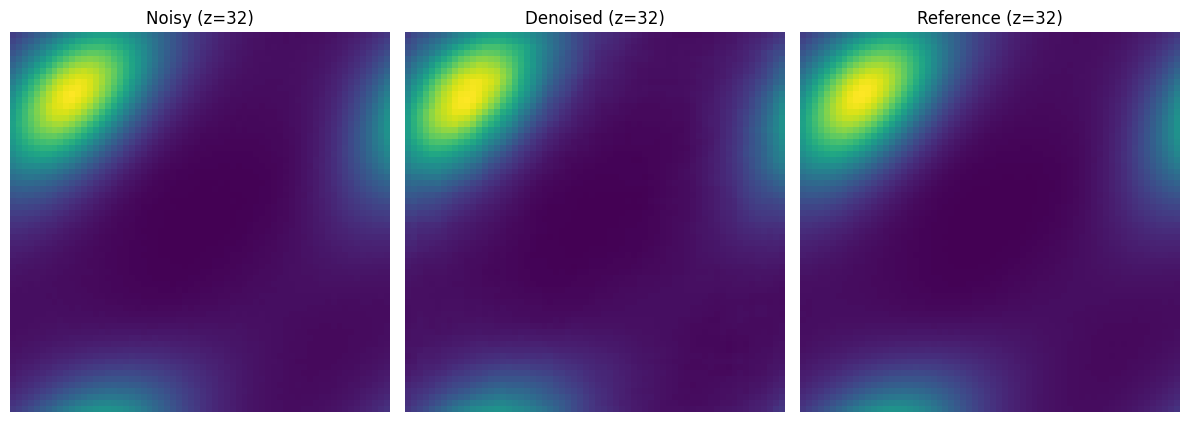

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


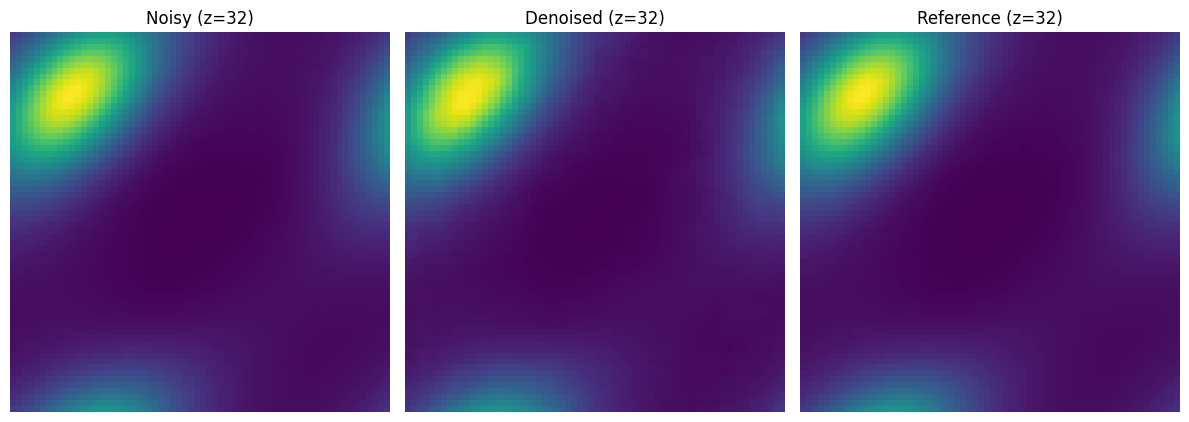

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


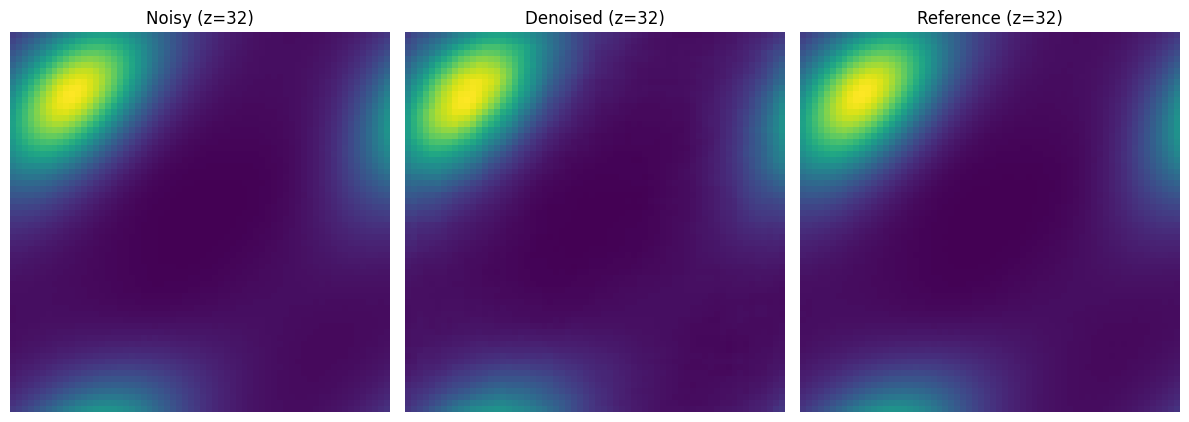

Results saved to 24080000000CAE_3D__3D_results.csv


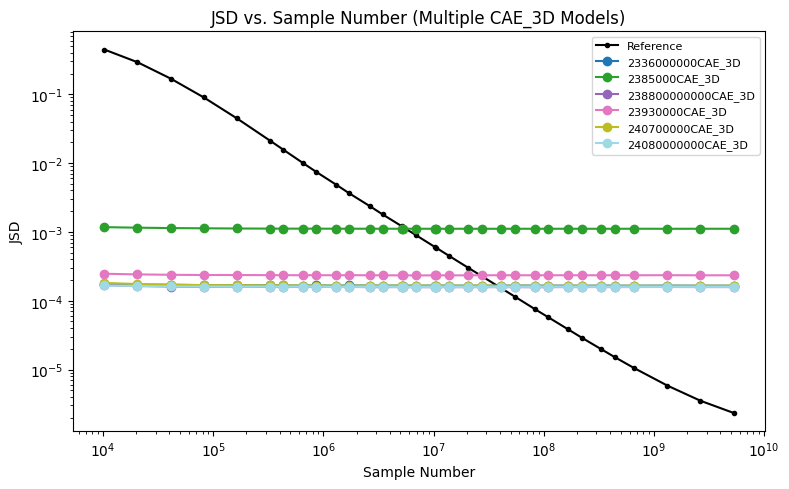

In [12]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
import csv

# Enable unsafe deserialization for custom keras objects
keras = tf.keras
keras.config.enable_unsafe_deserialization()

# Import your custom layers/losses and the CAE_3D_test_pipeline

# Global model variable used by CAE_3D_test_pipeline
CAE_3D_mod = None

# ==== Paths ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

# Directory containing *_CAE_3D.keras models
model_dir = "/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models"
model_files = sorted(glob.glob(os.path.join(model_dir, "*CAE_3D.keras")))

print(f"Found {len(noisy_files)} noisy files.")
print(f"Found {len(model_files)} CAE_3D models.")

# ==== Reference JSD ====
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d_full, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ==== Process each CAE_3D model ====
all_results = {}

for model_path in model_files:
    model_name = os.path.basename(model_path).replace(".keras", "")
    print(f"\n=== Running model: {model_name} ===")

    # Load model and assign to global used in CAE_3D_test_pipeline
    CAE_3D_mod = keras.models.load_model(
        model_path,
        custom_objects={
            "RenormalizeToEight": RenormalizeToEight,
            "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
        }
    )

    model_results = []
    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        with h5py.File(noisy_path, 'r') as file:
            test_d = file['density'][:]

        # Call your existing function
        _, jsd_denoised = CAE_3D_test_pipeline(test_d, ref_d_full)
        model_results.append((sample_num, jsd_denoised))

    all_results[model_name] = np.array(sorted(model_results, key=lambda x: x[0]))
# Save to CSV
filename = f'{model_name}__3D_results.csv'
header = ['sample_num', 'jsd_denoised']

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(model_results)

print(f"Results saved to {filename}")

# ==== Plot ====
plt.figure(figsize=(8, 5))

# Reference line
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Model lines
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   


0.00012671965457473964


In [18]:
print(all_results)

{'2336000000CAE_3D': array([[1.02400000e+04, 1.75054447e-04],
       [2.04800000e+04, 1.71122403e-04],
       [4.09600000e+04, 1.70273444e-04],
       [8.19200000e+04, 1.68322891e-04],
       [1.63840000e+05, 1.67185266e-04],
       [3.27680000e+05, 1.67244041e-04],
       [4.30080000e+05, 1.66457990e-04],
       [6.55360000e+05, 1.66069891e-04],
       [8.60160000e+05, 1.66521873e-04],
       [1.31072000e+06, 1.65909412e-04],
       [1.72032000e+06, 1.66570768e-04],
       [2.62144000e+06, 1.66041485e-04],
       [3.44064000e+06, 1.66025158e-04],
       [5.16096000e+06, 1.65860212e-04],
       [5.24288000e+06, 1.65732214e-04],
       [6.88128000e+06, 1.65734673e-04],
       [1.03219200e+07, 1.65683989e-04],
       [1.04857600e+07, 1.65746547e-04],
       [1.37625600e+07, 1.65823440e-04],
       [2.06438400e+07, 1.65279285e-04],
       [2.75251200e+07, 1.65716730e-04],
       [4.12876800e+07, 1.65739068e-04],
       [5.50502400e+07, 1.65740115e-04],
       [8.25753600e+07, 1.65948775e-

In [14]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [15]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0007716768226325421)), (20480, np.float64(0.00037949244095305054)), (40960, np.float64(0.000376594842200277)), (81920, np.float64(0.00018202493991624903)), (163840, np.float64(0.00017021310794393946)), (327680, np.float64(0.00012433696291303786)), (430080, np.float64(6.943723931875953e-05)), (655360, np.float64(5.799084731261237e-05)), (860160, np.float64(5.456354656463819e-05)), (1310720, np.float64(3.727165366458061e-05)), (1720320, np.float64(3.258676221468244e-05)), (2621440, np.float64(2.3595214312532686e-05)), (3440640, np.float64(1.8696064697238217e-05)), (5160960, np.float64(9.42484232231972e-06)), (5242880, np.float64(1.039294366000203e-05)), (6881280, np.float64(1.0892102634738487e-05)), (10321920, np.float64(6.023249811596284e-06)), (10485760, np.float64(5.93666518081904e-06)), (13762560, np.float64(6.466678428983334e-06)), (20643840, np.float64(4.444567479979796e-06)), (27525120, np.float64(4.5848401418028495e-06)), (41287680, np.float64(2.938963545350

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import logging

# === Load data ===
#data = np.load("jsd_plot_data_3D.npz", allow_pickle=True)

# If it's a dict stored in arr_0
if "arr_0" in data:
    jsd_dict = data["arr_0"].item()
else:
    jsd_dict = {k: data[k] for k in data.files}

# Extract reference

import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))


# Extract models (rename keys for cleaner labels)
all_results = {}
for k, v in jsd_dict.items():
    if k != "results_array_ref":
        # Strip off trailing "CAE_3D" and put it in parentheses
        if k.endswith("CAE_3D"):
            prefix = k.replace("CAE_3D", "")
            clean_name = f"CAE_3D ({prefix})"
        else:
            clean_name = k
        all_results[clean_name] = v
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")

# Plot reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot all CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'files'

In [22]:
import matplotlib
matplotlib.use('Agg')  # Prevents backend crashing on cluster environments
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging

logging.getLogger('matplotlib').setLevel(logging.WARNING)

# --- 1. Consolidate In-Memory Data to Pandas & Save CSV ---

# Reference (Noisy VMC)
df = pd.DataFrame(results_array_ref, columns=["Samples", "Noisy_VMC"])

# FFT Results
fft_df = pd.DataFrame(model_results_FFT, columns=["Samples", "FFT"])
df = pd.merge(df, fft_df, on="Samples", how="outer")

# All CAE_3D Models
for model_name, data in all_results.items():
    if model_name.lower() == 'nature': 
        continue  # Skip 'nature' model as requested
        
    temp_df = pd.DataFrame(data, columns=["Samples", model_name])
    df = pd.merge(df, temp_df, on="Samples", how="outer")

# Sort, reset index, and export to CSV
df = df.sort_values("Samples").reset_index(drop=True)
csv_filename = "cae_3d_models_performance.csv"
df.to_csv(csv_filename, index=False)
print(f"All model data successfully saved to {csv_filename}")


import matplotlib
matplotlib.use('Agg')  # Prevents backend crashing on cluster environments
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import re

logging.getLogger('matplotlib').setLevel(logging.WARNING)

# --- 1. Consolidate In-Memory Data to Pandas & Save CSV ---

# Reference (Noisy VMC)
df = pd.DataFrame(results_array_ref, columns=["Samples", "Noisy_VMC"])

# FFT Results
fft_df = pd.DataFrame(model_results_FFT, columns=["Samples", "FFT"])
df = pd.merge(df, fft_df, on="Samples", how="outer")

# All CAE_3D Models
for model_name, data in all_results.items():
    if model_name.lower() == 'nature': 
        continue  # Skip 'nature' model
        
    temp_df = pd.DataFrame(data, columns=["Samples", model_name])
    df = pd.merge(df, temp_df, on="Samples", how="outer")

# Sort, reset index, and export to CSV
df = df.sort_values("Samples").reset_index(drop=True)
csv_filename = "cae_3d_models_performance.csv"
df.to_csv(csv_filename, index=False)
print(f"All model data successfully saved to {csv_filename}")


# --- 2. Format Labels to Scientific Notation ---
def format_label(name):
    """Converts leading numbers in model names to scientific notation."""
    match = re.match(r'^(\d+)(.*)$', name.strip())
    if match:
        num_part = float(match.group(1))
        text_part = match.group(2).strip()
        # Format the number to scientific notation (e.g., 2.3e+09)
        return f"{num_part:.1e} {text_part}"
    return name


# --- 3. Plotting with Publication Settings ---
plt.rcParams.update({
    'font.size': 14, 
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.size': 7,
    'ytick.major.width': 1.5,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fontsize': 11
})

# INCREASED FIGURE SIZE TO 14x9
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Reference (Noisy VMC)
ax.plot(df["Samples"], df["Noisy_VMC"], marker="o", linestyle="--", color="red", label="Noisy VMC", alpha=0.7, markersize=8)

# Plot FFT
ax.plot(df["Samples"], df["FFT"], marker="D", linestyle="-", color="magenta", label="FFT", linewidth=2.5, markersize=8)

# Extract only the CAE_3D model columns for plotting
model_cols = [col for col in df.columns if col not in ["Samples", "Noisy_VMC", "FFT"]]

# Generate a distinct colormap for the CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(model_cols)))

for color, model_name in zip(colors, model_cols):
    # Apply scientific notation formatting to the label
    formatted_label = format_label(model_name)
    ax.plot(df["Samples"], df[model_name], marker="s", linestyle="-", label=formatted_label, color=color, linewidth=2.5, markersize=8)

# DFT Baseline
ax.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT Baseline", linewidth=2)

# Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of VMC Samples', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$D_{JS}$ (Jensen-Shannon Divergence)', fontweight='bold', labelpad=10)

# Move legend inside to the upper right and split into 2 columns
ax.legend(loc='upper right', ncol=2, framealpha=0.9)
ax.grid(False)

plt.tight_layout()

# --- 4. Save Outputs ---
output_base = "cae_3d_models_convergence_pub"
plt.savefig(f"{output_base}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{output_base}.pdf", bbox_inches='tight')

print(f"Publication-ready plots saved as {output_base}.png and {output_base}.pdf")

All model data successfully saved to cae_3d_models_performance.csv
All model data successfully saved to cae_3d_models_performance.csv
Publication-ready plots saved as cae_3d_models_convergence_pub.png and cae_3d_models_convergence_pub.pdf
